# A first quantum simulation — the 1D harmonic oscillator

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 1 — Computational toolbox*

## 1. Introduction and motivation

Together with notebook 00a, which treats a free particle, this notebook is the first *quantum* simulation of the
course. The system is the one every physicist meets in the first weeks of a quantum-mechanics course: a particle of mass $m$ in a harmonic potential of angular frequency $\omega_0$,

$$ V(x) = \tfrac{1}{2} m \omega_0^2 x^2 . $$

We choose it for a very practical reason: **everything about it is known analytically.** The energies are
$E_n = \hbar\omega_0 (n + \tfrac12)$, the eigenfunctions are Hermite functions, a displaced Gaussian oscillates
forever without spreading, and after a sudden change of the trap frequency the width of the wave packet breathes
with a formula we can write down in closed form. Every single number the computer produces in this notebook can
therefore be compared with a number we already know. That comparison — *numerics against analytics* — is the
recurring refrain of this notebook. Numerical wave-packet
propagation of this kind was put on film by Goldberg, Schey and Schwartz in 1967 (Am. J. Phys. **35**, 177 (1967)).

The companion notebook [00a — free particle: a Gaussian wave packet](00a_free_particle_gaussian_wave_packet.ipynb)
treated a particle with **no** potential. There the only scale in the problem was the one you put in by hand
(the initial width of the packet). Here a potential is present, and with it comes a *natural* scale: the trap
supplies an energy $\hbar\omega_0$, a time $1/\omega_0$ and a length $\sqrt{\hbar/(m\omega_0)}$, all built out of
the constants of the problem. Turning the Schrödinger equation into a parameter-free equation with those scales
is the first thing a numericist does; Section 4 carries out the substitution term by term, including the
rescaling of the wave function and the case of a trap whose frequency differs from $\omega_0$.

### Where the harmonic oscillator actually appears

Near a minimum, *every* smooth potential is harmonic: $V(x) \simeq V(x_\star) + \tfrac12 V''(x_\star)(x-x_\star)^2$.
That single line is why the oscillator is everywhere:

* **Molecular vibrations.** The stretching mode of CO sits at about $2143\,\mathrm{cm}^{-1}$, i.e.
  $\omega_0/2\pi \approx 6.4\times10^{13}\,\mathrm{Hz}$. Infrared spectroscopy reads off $\hbar\omega_0$ directly.
* **Trapped ions.** A single $^{40}\mathrm{Ca}^+$ ion in a Paul trap oscillates at $\omega_0/2\pi \sim 1\,\mathrm{MHz}$.
  Its vibrational levels are the "bus" of a trapped-ion quantum computer.
* **Cold atoms.** An optical tweezer holds a $^{87}\mathrm{Rb}$ atom in a nearly harmonic well of
  $\omega_0/2\pi \sim 50\,\mathrm{kHz}$.
* **Superconducting circuits.** An $LC$ resonator *is* a harmonic oscillator with $\omega_0 = 1/\sqrt{LC}$; adding a
  Josephson junction makes it anharmonic, and that is exactly what turns it into a qubit.
* **Phonons and photons.** A crystal lattice and the quantised electromagnetic field are, mathematically, infinite
  collections of independent harmonic oscillators.

### Road map

Section 2 reads the *Configuration* cell. Section 3 writes the problem in SI units. Section 4 removes the units
(non-dimensionalisation). Section 5 replaces the continuous $x$ by a grid and the second derivative by
a three-point formula, with the error term derived from Taylor's theorem. Section 6 assembles the Hamiltonian as a
**tridiagonal matrix** and looks at it. Section 7 diagonalises it and compares $E_n$ with $n+\tfrac12$;
Section 8 is a full convergence study (how many grid points? how big a box?). Section 9 compares the numerical
eigenfunctions with the Hermite functions and draws the classic "levels inside the parabola" picture.
Section 10 derives, once and for all, how $\langle x\rangle$, $\langle p\rangle$, $\mathrm{Var}(x)$ and
$\mathrm{Var}(p)$ move in a harmonic trap (Ehrenfest's theorem and the closed equations for the second moments),
and explains how to measure them on a grid. Section 11 evolves superpositions in time by spectral decomposition
and checks all four against the formulas. Section 12 **quenches** the trap frequency — producing a *squeezed*
state — and solves the same problem four different ways: spectral, matrix exponential, a hand-written
Runge–Kutta integrator and, in Section 12.11, the implicit Crank–Nicolson scheme, which has no step limit,
comparing accuracy, stability and cost. Section 13 turns the results into animated GIFs.
Section 14 distils the reusable workflow, and lists exercises and references.

### What you will learn

*Physics*

* the stationary and time-dependent Schrödinger equation of the harmonic oscillator, its spectrum and its
  eigenfunctions, classical turning points and the correspondence principle;
* **Ehrenfest's theorem**: in a harmonic trap the centre of *any* wave packet follows the classical orbit exactly,
  while the widths obey their own closed equations and oscillate at *twice* the trap frequency;
* coherent states: a displaced ground state oscillates like a classical particle, does not spread, and saturates
  the Heisenberg bound $\mathrm{Var}(x)\mathrm{Var}(p) = 1/4$ at all times;
* the **breathing mode** after a sudden change of trap frequency, with exact formulas for $\mathrm{Var}(x)(t)$
  and $\mathrm{Var}(p)(t)$, and the **squeezed state** it produces at the turning points of the breathing;
* the virial theorem, and energy and norm conservation as everyday numerical checks.

*Numerical methods*

* non-dimensionalisation: why we always do it, and how to convert results back to SI;
* finite differences: the three-point second derivative and its $O(\Delta x^2)$ error;
* matrix eigenvalue problems: what an eigensolver returns, tridiagonal solvers, convergence in the number of grid
  points and in the box size;
* four ways to integrate $i\,\partial_t\psi = H\psi$ (spectral, matrix exponential, RK4, implicit Crank–Nicolson) and their
  trade-offs; stability of an explicit integrator,
  why Euler is *unconditionally* unstable here, why an explicit scheme on a finite-difference grid is tied to
  $\Delta t \lesssim \Delta x^2$ while unitary schemes are not, and the $\Delta t^4$ / $\Delta t^5$ error laws of
  Runge–Kutta.

*Implementation practice*

* writing small pure functions with docstrings, and validating each one against an exact result before using it;
* `jax.jit` and `lax.scan` for a time loop that never leaves the compiler, and a **matrix-free** Hamiltonian;
* making publication-quality figures and embedding animated GIFs in a notebook without writing files.

### Prerequisites

One semester of quantum mechanics (the Schrödinger equation, eigenvalues, expectation values) and basic
NumPy/matplotlib. Notebook [00a](00a_free_particle_gaussian_wave_packet.ipynb) introduced grids, discretisation
error, log-log convergence plots and Riemann sums; we recall each of those in one sentence when it is needed, so
this notebook can also be read first. No JAX knowledge is assumed: the two JAX features we use are explained where
they appear, and [01 — JAX](01_jax_from_scratch.ipynb) tells the full story. The same ideas
reappear for many-body spin chains in
[04 — time evolution the textbook way](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. The configuration cell, and the tools of this notebook

The cell above opens every notebook of the course. For today you only need to know what it leaves behind:

| name | meaning |
|---|---|
| `np`, `jnp` | NumPy, and JAX's copy of the NumPy interface |
| `jax`, `lax` | the JAX library and its low-level module (we use `jax.jit` and `lax.scan` in Section 12) |
| `RDTYPE`, `CDTYPE` | the real and complex floating-point types (`float64`/`complex128` by default) |
| `TOL` | the tolerance used in sanity checks, $10^{-10}$ in double precision |
| `plt`, `time` | matplotlib and the timing module |

House rule: **never hard-code a dtype**. Write `np.zeros(n, dtype=CDTYPE)` and the whole notebook follows the
`PRECISION` switch. All results below were produced with `PRECISION = "double"`, and this notebook *needs* it:
the integrator study of Section 12 measures a norm drift down to $4\times10^{-13}$ and differences between
integrators of $10^{-12}$, which single precision (about $10^{-7}$ relative) cannot resolve at all. For the same
reason the checks below do not use the blanket `TOL`: every `assert` carries its own threshold, chosen to match
the error the surrounding text has just *derived*.

Beyond the configuration cell we import a handful of well-known tools. `scipy.linalg.eigh_tridiagonal` is a
specialised eigenvalue solver for real symmetric **tridiagonal** matrices — exactly the shape our Hamiltonian will
have. `scipy.linalg.expm` computes a matrix exponential. `scipy.special.eval_hermite` gives Hermite polynomials,
which we use once as an independent check of our own recurrence.

In [2]:
# ==============================================================================
# EXTRA IMPORTS  -- everything else comes from the Configuration cell above
# ==============================================================================
import base64                                   # to inline the animated GIF in the notebook output
import math                                     # factorials for the Hermite normalisation
import tempfile                                 # a scratch file for the animated GIF (deleted immediately)

from scipy.linalg import eigh_tridiagonal       # eigenvalues of a real symmetric TRIDIAGONAL matrix
from scipy.linalg import expm                   # dense matrix exponential  expm(A) = sum_k A^k / k!
from scipy.special import eval_hermite          # physicists' Hermite polynomial H_n(x)

from matplotlib.animation import FuncAnimation, PillowWriter   # GIF writing
from IPython.display import display                            # embed the GIF in the notebook output

# a colour-blind-friendly palette used consistently in every figure of this notebook
C_NUM, C_EXACT, C_POT, C_HL = "#0072B2", "#D55E00", "0.55", "#009E73"

print("extra imports OK -- scipy, matplotlib.animation, IPython.display")

extra imports OK -- scipy, matplotlib.animation, IPython.display


## 3. The physical problem, in SI units

A particle of mass $m$ moves in one dimension in the potential $V(x) = \tfrac12 m\omega_0^2 x^2$. Its state is a
complex-valued wave function $\psi(x,t)$, and everything we can ask about the particle is encoded in it. The
**time-dependent Schrödinger equation** (TDSE) is

$$ i\hbar\,\frac{\partial \psi(x,t)}{\partial t} \;=\; \hat H\,\psi(x,t), \qquad
   \hat H \;=\; -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} \;+\; \frac{1}{2} m \omega_0^2 x^2 . \tag{1} $$

The first term of $\hat H$ is the kinetic energy (it comes from $\hat p = -i\hbar\,\partial_x$ through
$\hat p^2/2m$), the second is the potential energy. Both have units of joules.

Separating variables, $\psi(x,t) = \phi(x)\,e^{-iEt/\hbar}$, turns Eq. (1) into the **stationary (time-independent)
Schrödinger equation** (TISE), an eigenvalue problem:

$$ -\frac{\hbar^2}{2m}\,\phi''(x) \;+\; \frac{1}{2} m \omega_0^2 x^2\,\phi(x) \;=\; E\,\phi(x) . \tag{2} $$

The textbook answer, which we will *not* assume but *reproduce*, is

$$ E_n = \hbar\omega_0\left(n + \tfrac{1}{2}\right), \qquad n = 0, 1, 2, \dots $$

The wave function must be normalised, $\int_{-\infty}^{\infty} \vert\psi(x,t)\vert^2\,dx = 1$, because
$\vert\psi(x,t)\vert^2\,dx$ is the probability of finding the particle in $[x, x+dx]$. Everything we compute —
energies, densities, expectation values — must respect this.

### Three real systems, three sets of numbers

Before touching a computer, let us see what $\hbar$, $m$ and $\omega_0$ mean in practice. The cell below builds the
three quantities that will turn out to be the *natural units* of the problem,

$$ E_0 = \hbar\omega_0, \qquad t_0 = \frac{1}{\omega_0}, \qquad x_0 = \sqrt{\frac{\hbar}{m\omega_0}}, $$

for a trapped ion, a molecular vibration and an atom in an optical tweezer. (Section 4 explains where they come
from; here we just look at the numbers.)

In [3]:
# ==============================================================================
# STEP 1: SI constants and three laboratory systems
# ==============================================================================
HBAR = 1.054571817e-34        # J s        reduced Planck constant
AMU  = 1.66053906660e-27      # kg         atomic mass unit
EV   = 1.602176634e-19        # J          electronvolt
C_LIGHT = 2.99792458e8        # m/s        speed of light (to convert cm^-1 -> Hz)

# name, mass [kg], trap/vibration frequency omega_0/2pi [Hz]
SYSTEMS = [
    ("trapped ion Ca-40",      40.0 * AMU,                 1.0e6),
    ("CO molecule (stretch)",  (12.0 * 16.0 / 28.0) * AMU, 2143.0 * C_LIGHT * 100.0),   # 2143 cm^-1 -> Hz
    ("Rb-87 in a tweezer",     86.909 * AMU,               5.0e4),
]

print(f"{'system':24s} {'w0/2pi [Hz]':>12s} {'E0 [J]':>11s} {'E0 [eV]':>11s} "
      f"{'t0 [s]':>11s} {'x0 [m]':>11s}")
for name, m, f0 in SYSTEMS:
    omega0 = 2.0 * np.pi * f0                       # angular frequency [rad/s]
    E0 = HBAR * omega0                              # energy unit  [J]
    t0 = 1.0 / omega0                               # time unit    [s]
    x0 = np.sqrt(HBAR / (m * omega0))               # length unit  [m]   "oscillator length"
    print(f"{name:24s} {f0:12.3e} {E0:11.3e} {E0/EV:11.3e} {t0:11.3e} {x0:11.3e}")

system                    w0/2pi [Hz]      E0 [J]     E0 [eV]      t0 [s]      x0 [m]
trapped ion Ca-40           1.000e+06   6.626e-28   4.136e-09   1.592e-07   1.590e-08
CO molecule (stretch)       6.425e+13   4.257e-20   2.657e-01   2.477e-15   4.790e-12
Rb-87 in a tweezer          5.000e+04   3.313e-29   2.068e-10   3.183e-06   4.823e-08


The table repays a careful reading. The three systems differ by more than **nine orders of magnitude** in
frequency: the ion completes one oscillation per microsecond, the CO bond one per $16$ femtoseconds. (Careful:
the *period* is $2\pi/\omega_0 = 2\pi\,t_0$, not the unit of time $t_0 = 1/\omega_0$ listed in the table —
$2\pi\times2.48\,\mathrm{fs} = 15.6\,\mathrm{fs}$.) The level spacing $\hbar\omega_0$ spans
$0.2\,\mathrm{neV}$ (tweezer) and $4\,\mathrm{neV}$ (ion) up to $0.27\,\mathrm{eV}$ (CO).
The oscillator length $x_0$ ranges from $4.8\,\mathrm{pm}$ (smaller than an atom) to $48\,\mathrm{nm}$
(a hundred times an atom).

And yet: **the mathematics is identical in all three cases.** That observation is the whole point of the next
section.

## 4. Non-dimensionalisation: choosing the units of energy, time and length

### 4.1 Why we remove the units

Equation (1) contains three constants, $\hbar$, $m$, $\omega_0$, whose numerical values are around $10^{-34}$,
$10^{-26}$ and $10^{6}$. Typed into a computer as they are, they would make every intermediate number tiny or huge:
$\hbar^2 \approx 10^{-68}$ already underflows to zero in single precision (whose smallest normal number is about
$10^{-38}$), and one misplaced exponent would be invisible. There are three good reasons to remove the units first:

1. **Numbers of order one.** All arrays hold values between roughly $10^{-3}$ and $10^{3}$, where an absolute
   tolerance such as `TOL` means something and where a wrong result *looks* wrong.
2. **Fewer parameters.** The three constants collapse into *none*: the dimensionless equation has no free
   parameter at all. We will therefore never have to "choose $m$".
3. **Universality.** One simulation describes the ion, the molecule and the atom at once. Converting back is a
   multiplication by $E_0$, $t_0$ or $x_0$.

### 4.2 Choosing the energy scale

The only energy we can build from $\hbar$ and $\omega_0$ is

$$ E_0 \;=\; \hbar\,\omega_0 . $$

Divide the whole of Eq. (1) by $E_0$:

$$ \frac{i\hbar}{\hbar\omega_0}\,\frac{\partial\psi}{\partial t}
   \;=\; -\frac{\hbar^2}{2m\,\hbar\omega_0}\,\frac{\partial^2\psi}{\partial x^2}
        \;+\; \frac{m\omega_0^2}{2\,\hbar\omega_0}\,x^2\,\psi . $$

Simplify each of the three coefficients:

$$ \frac{i\hbar}{\hbar\omega_0} = \frac{i}{\omega_0}, \qquad
   \frac{\hbar^2}{2m\hbar\omega_0} = \frac{1}{2}\,\frac{\hbar}{m\omega_0}, \qquad
   \frac{m\omega_0^2}{2\hbar\omega_0} = \frac{1}{2}\,\frac{m\omega_0}{\hbar} . $$

So

$$ \frac{i}{\omega_0}\,\frac{\partial\psi}{\partial t}
   \;=\; -\frac{1}{2}\,\frac{\hbar}{m\omega_0}\,\frac{\partial^2\psi}{\partial x^2}
        \;+\; \frac{1}{2}\,\frac{m\omega_0}{\hbar}\,x^2\,\psi . \tag{3} $$

### 4.3 The unit of time and the unit of length appear by themselves

Look at Eq. (3). On the left the derivative $\partial/\partial t$ is divided by $\omega_0$ — so $\omega_0 t$ is the
combination the equation actually cares about. Define

$$ t_0 \;=\; \frac{1}{\omega_0}, \qquad \tilde t \;=\; \frac{t}{t_0} \;=\; \omega_0 t
   \quad\Longrightarrow\quad \frac{\partial}{\partial t} = \omega_0 \frac{\partial}{\partial \tilde t}, $$

and the left-hand side becomes simply $i\,\partial\psi/\partial\tilde t$.

On the right, the combination $\hbar/(m\omega_0)$ multiplies $\partial^2/\partial x^2$ and its inverse multiplies
$x^2$. Since $\partial^2/\partial x^2$ has units of (length)$^{-2}$, the quantity $\hbar/(m\omega_0)$ must be a
**squared length**. Define the *oscillator length*

$$ x_0 \;=\; \sqrt{\frac{\hbar}{m\omega_0}}, \qquad \tilde x \;=\; \frac{x}{x_0}
   \quad\Longrightarrow\quad \frac{\partial^2}{\partial x^2} = \frac{1}{x_0^2}\,\frac{\partial^2}{\partial \tilde x^2},
   \qquad x^2 = x_0^2\,\tilde x^2 . $$

Substituting both into Eq. (3), the kinetic term becomes

$$ -\frac{1}{2}\,\frac{\hbar}{m\omega_0}\cdot\frac{1}{x_0^2}\,\frac{\partial^2\psi}{\partial\tilde x^2}
   = -\frac{1}{2}\,\frac{x_0^2}{x_0^2}\,\frac{\partial^2\psi}{\partial\tilde x^2}
   = -\frac{1}{2}\,\frac{\partial^2\psi}{\partial\tilde x^2}, $$

and the potential term becomes

$$ \frac{1}{2}\,\frac{m\omega_0}{\hbar}\,x_0^2\,\tilde x^2\,\psi
   = \frac{1}{2}\,\frac{1}{x_0^2}\,x_0^2\,\tilde x^2\,\psi = \frac{1}{2}\,\tilde x^2\,\psi . $$

### 4.4 The wave function must be rescaled too

One subtlety is easy to miss. The normalisation condition is $\int \vert\psi\vert^2\,dx = 1$, and $dx = x_0\,d\tilde x$, so

$$ 1 = \int \vert\psi(x)\vert^2\,dx = \int \vert\psi\vert^2\,x_0\,d\tilde x
     = \int \left\vert \sqrt{x_0}\,\psi \right\vert^2 d\tilde x . $$

Therefore the dimensionless wave function is

$$ \tilde\psi(\tilde x, \tilde t) \;=\; \sqrt{x_0}\;\psi(x, t), $$

which is dimensionless (in SI, $\psi$ has units of $\mathrm{m}^{-1/2}$) and satisfies
$\int \vert\tilde\psi\vert^2 d\tilde x = 1$. Since the TDSE is linear, multiplying $\psi$ by the constant
$\sqrt{x_0}$ changes nothing else.

### 4.5 The dimensionless Schrödinger equation

Dropping the tildes once and for all — **from here on $x$, $t$, $E$, $\psi$ are the dimensionless quantities** —

$$ i\,\frac{\partial\psi}{\partial t} \;=\; \hat H\psi, \qquad
   \hat H \;=\; -\frac{1}{2}\frac{\partial^2}{\partial x^2} \;+\; \frac{1}{2}x^2 , \tag{4} $$

with the stationary problem

$$ -\tfrac12\,\phi_n''(x) + \tfrac12 x^2 \phi_n(x) = E_n\,\phi_n(x), \qquad E_n = n + \tfrac12 . \tag{5} $$

Not a single constant is left. This is the equation we will solve, and it is what the phrase "set
$\hbar = m = \omega_0 = 1$" means, with the units listed below.

### 4.6 Converting back to SI

| dimensionless quantity | multiply by | trapped ion | CO molecule |
|---|---|---|---|
| energy $E$ | $E_0 = \hbar\omega_0$ | $6.63\times10^{-28}\,$J | $4.26\times10^{-20}\,$J |
| time $t$ | $t_0 = 1/\omega_0$ | $159\,$ns | $2.48\,$fs |
| length $x$ | $x_0 = \sqrt{\hbar/(m\omega_0)}$ | $15.9\,$nm | $4.79\,$pm |
| wave function $\psi$ | $x_0^{-1/2}$ | | |

So "the ground-state width is $\sigma = 1/\sqrt{2}$" means $11.2\,\mathrm{nm}$ for the ion and $3.39\,\mathrm{pm}$
for the CO bond. Let us have the computer confirm those two sentences.

### 4.7 A trap of a different frequency

In Section 12 we will suddenly change the trap frequency from $\omega_0$ to $\omega_1$. We keep the *same* units
(built from $\omega_0$), so only the potential changes. Repeating Section 4.3 with $\omega$ in the potential and
$\omega_0$ in the units gives

$$ \frac{1}{2}\frac{m\omega^2}{\hbar\omega_0} x_0^2 \tilde x^2
   = \frac{1}{2}\left(\frac{\omega}{\omega_0}\right)^{2}\tilde x^2 . $$

**Recipe.** A trap of frequency $\omega$, measured in the units of a trap of frequency $\omega_0$, is the
dimensionless potential

$$ V(x) = \tfrac12\, r^2 x^2, \qquad r \equiv \frac{\omega}{\omega_0} . \tag{6} $$

Everything in this notebook is written with this $r$ in place; $r = 1$ recovers Eq. (4).

In [4]:
# ==============================================================================
# STEP 2: converting a dimensionless result back to SI
#         the ground-state width is sigma = 1/sqrt(2) in units of x_0 (proved in Sec. 9)
# ==============================================================================
sigma_dimensionless = 1.0 / np.sqrt(2.0)

for name, m, f0 in SYSTEMS:
    omega0 = 2.0 * np.pi * f0
    x0 = np.sqrt(HBAR / (m * omega0))
    E0 = HBAR * omega0
    print(f"{name:24s}  sigma = {sigma_dimensionless:.4f} x_0 = {sigma_dimensionless * x0:.3e} m"
          f"   |  E_ground = 0.5 E_0 = {0.5 * E0 / EV:.4e} eV (zero-point energy)")

trapped ion Ca-40         sigma = 0.7071 x_0 = 1.124e-08 m   |  E_ground = 0.5 E_0 = 2.0678e-09 eV (zero-point energy)
CO molecule (stretch)     sigma = 0.7071 x_0 = 3.387e-12 m   |  E_ground = 0.5 E_0 = 1.3285e-01 eV (zero-point energy)
Rb-87 in a tweezer        sigma = 0.7071 x_0 = 3.410e-08 m   |  E_ground = 0.5 E_0 = 1.0339e-10 eV (zero-point energy)


> **Numerical practice.** Non-dimensionalise *before* you write any code, on paper. Then write down the table of
> units and keep it next to the notebook. Almost every "my simulation gives nonsense" bug in computational physics
> is a forgotten factor of $\hbar$, $m$ or $2\pi$ in that table.

## 5. Discretisation: from a function to an array

A computer cannot store the function $\psi(x)$ for every real $x$. It stores a **finite list of numbers**. So we
make two approximations, and we will measure the error of each one.

### 5.1 The grid

Restrict $x$ to a finite interval $[-L/2, +L/2]$ (the *box*) and sample it at $N_x$ equally spaced points:

$$ x_j = -\frac{L}{2} + j\,\Delta x, \qquad j = 0, 1, \dots, N_x - 1, \qquad
   \Delta x = \frac{L}{N_x - 1}. $$

The wave function becomes a vector of $N_x$ complex numbers, $\psi_j \equiv \psi(x_j)$. In NumPy this is one line,
`x = np.linspace(-L/2, L/2, N_x)`.

Two numbers now control the quality of the approximation, and they do *different* jobs:

* $\Delta x$ controls how well we can resolve the **wiggles** of $\psi$ (small $\Delta x$ = fine resolution);
* $L$ controls how much **room** the particle has (large $L$ = the walls are far away).

Section 8 studies both. Keep them separate in your head: a large $N_x$ with a small $L$ is a very accurate
simulation of the *wrong* problem.

### 5.2 The second derivative from Taylor's theorem

We need $\phi''(x_j)$ from the numbers $\phi_{j-1}, \phi_j, \phi_{j+1}$. Taylor-expand the two neighbours about
$x_j$, writing $h \equiv \Delta x$:

$$ \phi(x_j + h) = \phi_j + h\phi'_j + \frac{h^2}{2}\phi''_j + \frac{h^3}{6}\phi'''_j +
     \frac{h^4}{24}\phi^{(4)}_j + \frac{h^5}{120}\phi^{(5)}_j + O(h^6), $$

$$ \phi(x_j - h) = \phi_j - h\phi'_j + \frac{h^2}{2}\phi''_j - \frac{h^3}{6}\phi'''_j +
     \frac{h^4}{24}\phi^{(4)}_j - \frac{h^5}{120}\phi^{(5)}_j + O(h^6). $$

**Add them.** Every odd-order term cancels — this is why the formula is so much better than it looks:

$$ \phi_{j+1} + \phi_{j-1} = 2\phi_j + h^2\phi''_j + \frac{h^4}{12}\phi^{(4)}_j + O(h^6). $$

Now solve for $\phi''_j$:

$$ \phi''_j = \frac{\phi_{j+1} - 2\phi_j + \phi_{j-1}}{h^2} \;-\; \frac{h^2}{12}\,\phi^{(4)}_j \;+\; O(h^4). \tag{7} $$

The first term is the **three-point stencil** we will use. The second term is the **truncation error**: it is
proportional to $h^2 = \Delta x^2$, so halving $\Delta x$ divides the error by four. We say the formula is
*second-order accurate*. We know the error term *exactly*, not just its order — in Section 8 we will use
it to predict the error in the energies before measuring it.

### 5.3 Boundary conditions

At $j = 0$ and $j = N_x - 1$ the stencil asks for $\phi_{-1}$ and $\phi_{N_x}$, which do not exist. The simplest
choice is to set them to zero:

$$ \phi_{-1} = \phi_{N_x} = 0 . $$

This is a **Dirichlet** (hard-wall) boundary condition: the particle is confined to a box with infinitely high
walls just outside the grid. It is not the physical condition — the true condition is $\phi \to 0$ as
$x \to \pm\infty$ — but for the oscillator the eigenfunctions decay like $e^{-x^2/2}$, i.e. *faster than any
exponential*. Putting the wall at $x = \pm 10$ changes $\phi_0$ by a factor $e^{-50} \approx 2\times10^{-22}$,
far below machine precision. **If $L$ is large enough, the walls are invisible.** Section 8.3 shows what happens
when it is not.

### 5.4 Normalisation on a grid

The integral $\int \vert\psi\vert^2 dx$ becomes a Riemann sum over the grid:

$$ \int_{-\infty}^{\infty} \vert\psi(x)\vert^2\,dx \;\longrightarrow\; \sum_{j=0}^{N_x-1} \vert\psi_j\vert^2\,\Delta x \;=\; 1 . $$

The same rule gives every expectation value:

$$ \langle f(x)\rangle \;=\; \int f(x)\,\vert\psi(x)\vert^2\,dx
   \;\longrightarrow\; \sum_j f(x_j)\,\vert\psi_j\vert^2\,\Delta x . $$

For a smooth function that decays at the edges of the box, this simple rectangle rule is *spectrally* accurate —
far better than its usual $O(\Delta x)$ reputation — because there are no boundary terms. We will see that in the
numbers.

### 5.5 Test the stencil before trusting it

Never use a formula you have not tested. We know that $g(x) = e^{-x^2/2}$ has
$g''(x) = (x^2-1)\,e^{-x^2/2}$. Let us apply Eq. (7) to $g$ and watch the error fall as $\Delta x^2$. The stencil
is written as one expression on shifted arrays, with no loop over grid points, the style of Press *et al.*,
*Numerical Recipes in Fortran 90*.

In [5]:
# ==============================================================================
# STEP 3: the three-point second derivative, and its measured order of accuracy
# ==============================================================================
def second_derivative(f_values, dx):
    """Three-point finite-difference second derivative with Dirichlet (zero) boundaries.

    MATH
        f''(x_j) ~= ( f_{j+1} - 2 f_j + f_{j-1} ) / dx^2 ,   error = -(dx^2/12) f''''(x_j) + O(dx^4)
        outside the grid f is taken to be 0  (hard walls just beyond the first and last point).

    IMPLEMENTATION
        f_{j+1} is `f_values` shifted one slot to the LEFT with a 0 appended;
        f_{j-1} is `f_values` shifted one slot to the RIGHT with a 0 prepended.
        No Python loop: three whole-array operations.

    COST  O(N_x) operations, O(N_x) memory.
    """
    zero = np.zeros(1, dtype=f_values.dtype)
    f_plus = np.concatenate([f_values[1:], zero])      # f_{j+1},  f_{N_x} := 0
    f_minus = np.concatenate([zero, f_values[:-1]])    # f_{j-1},  f_{-1}  := 0
    return (f_plus - 2.0 * f_values + f_minus) / dx**2


# ---- test on a function whose second derivative we know exactly -------------------
print(f"{'N_x':>7s} {'dx':>10s} {'max error':>12s} {'ratio':>8s}   (expect ratio -> 4 when dx is halved)")
prev_err, last_ratio = None, None
for N_x in [101, 201, 401, 801, 1601]:
    x_test = np.linspace(-8.0, 8.0, N_x, dtype=RDTYPE)
    dx_test = x_test[1] - x_test[0]
    g = np.exp(-x_test**2 / 2.0)                       # the test function
    g_dd_exact = (x_test**2 - 1.0) * g                 # its exact second derivative
    err = np.max(np.abs(second_derivative(g, dx_test) - g_dd_exact))
    last_ratio = None if prev_err is None else prev_err / err
    ratio = "" if last_ratio is None else f"{last_ratio:8.3f}"
    print(f"{N_x:7d} {dx_test:10.5f} {err:12.4e} {ratio:>8s}")
    prev_err = err

# CHECKPOINT: the observed order of convergence must be 2 (error ratio 4 per halving of dx)
assert abs(last_ratio - 4.0) < 0.02, "three-point stencil is not converging at order 2"
print("\ncheckpoint passed: the error falls by a factor ~4 whenever dx is halved -> order 2, as Eq. (7) predicts")

    N_x         dx    max error    ratio   (expect ratio -> 4 when dx is halved)
    101    0.16000   6.3728e-03         
    201    0.08000   1.5983e-03    3.987
    401    0.04000   3.9989e-04    3.997
    801    0.02000   9.9993e-05    3.999
   1601    0.01000   2.5000e-05    4.000

checkpoint passed: the error falls by a factor ~4 whenever dx is halved -> order 2, as Eq. (7) predicts


The ratio column climbs to $4.000$ (it is $3.987$ on the coarsest pair, where the neglected $O(h^4)$ term is
still visible): the stencil is exactly second-order, as derived. This is the first
instance of our refrain — *we derived an error law on paper and the computer confirmed it*.

## 6. The Hamiltonian as a tridiagonal matrix

Insert the stencil (7) into the stationary equation (5) with the general potential (6). At grid point $j$:

$$ -\frac{1}{2}\,\frac{\phi_{j+1} - 2\phi_j + \phi_{j-1}}{\Delta x^2} \;+\; \frac{1}{2} r^2 x_j^2\,\phi_j
   \;=\; E\,\phi_j . $$

Collect the coefficients of $\phi_{j-1}$, $\phi_j$, $\phi_{j+1}$:

$$ \underbrace{-\frac{1}{2\Delta x^2}}_{\text{coefficient of } \phi_{j-1}}\phi_{j-1} +
   \underbrace{\left(\frac{1}{\Delta x^2} + \frac{1}{2} r^2 x_j^2\right)}_{\text{coefficient of } \phi_j}\phi_j +
   \underbrace{-\frac{1}{2\Delta x^2}}_{\text{coefficient of } \phi_{j+1}}\phi_{j+1} \;=\; E\,\phi_j . $$

This is exactly the statement $\sum_k H_{jk}\phi_k = E\phi_j$ for the matrix

$$ H_{jk} = \begin{cases}
     \dfrac{1}{\Delta x^2} + \dfrac{1}{2} r^2 x_j^2, & k = j, \\[2mm]
     -\dfrac{1}{2\Delta x^2}, & k = j \pm 1, \\[2mm]
     0, & \text{otherwise.}
   \end{cases} \tag{8} $$

**The Schrödinger equation has become a matrix eigenvalue problem.** For $N_x = 5$, $\Delta x = 1$, $r = 1$,
writing $d_j = 1/\Delta x^2 + x_j^2/2$ and $e = -1/(2\Delta x^2)$, the matrix is

$$ H = \begin{pmatrix}
  d_0 & e   & 0   & 0   & 0 \\
  e   & d_1 & e   & 0   & 0 \\
  0   & e   & d_2 & e   & 0 \\
  0   & 0   & e   & d_3 & e \\
  0   & 0   & 0   & e   & d_4
\end{pmatrix}. $$

Three properties, each of which we will check in code:

* it is **real** (no complex numbers anywhere) and **symmetric**, $H_{jk} = H_{kj}$ — the discrete version of
  "$\hat H$ is Hermitian". This guarantees real eigenvalues and orthogonal eigenvectors;
* it is **tridiagonal**: only $3N_x - 2$ of the $N_x^2$ entries are non-zero. A general dense diagonalisation
  costs $O(N_x^3)$ operations and $O(N_x^2)$ memory; a *tridiagonal* solver costs $O(N_x^2)$ or less and needs only
  the two arrays $d$ and $e$. For $N_x = 3200$ that is the difference between $80\,$MB and $50\,$kB;
* the Dirichlet boundary condition is already built in — there is simply no entry coupling $j=0$ to $j=-1$.

We write two builders: one that returns the two diagonals (what we will actually use), and one that returns the
dense matrix (for looking at it, and for the matrix exponential in Section 12).

In [6]:
# ==============================================================================
# STEP 4: build the Hamiltonian -- tridiagonal form and dense form
# ==============================================================================
def make_grid(L, N_x):
    """The spatial grid.

    MATH   x_j = -L/2 + j*dx,  j = 0..N_x-1,  dx = L/(N_x-1)
    RETURNS (x, dx)
    """
    x = np.linspace(-0.5 * L, 0.5 * L, N_x).astype(RDTYPE)
    return x, RDTYPE(x[1] - x[0])


def harmonic_potential(x, freq_ratio=1.0):
    """V(x) = (1/2) r^2 x^2 with r = omega/omega_0  [Eq. (6)], in units of hbar*omega_0."""
    return RDTYPE(0.5) * freq_ratio**2 * x**2


def hamiltonian_tridiagonal(x, dx, freq_ratio=1.0):
    """The Hamiltonian of Eq. (8) as its two distinct diagonals.

    MATH   H[j,j]   = 1/dx^2 + V(x_j)          (main diagonal, length N_x)
           H[j,j+1] = H[j+1,j] = -1/(2 dx^2)   (off-diagonal,  length N_x-1)

    COST   O(N_x) memory -- this is the form a tridiagonal eigensolver wants.
    """
    diag = 1.0 / dx**2 + harmonic_potential(x, freq_ratio)
    off = np.full(len(x) - 1, -0.5 / dx**2, dtype=RDTYPE)
    return diag.astype(RDTYPE), off


def hamiltonian_dense(x, dx, freq_ratio=1.0):
    """The same operator as a full N_x x N_x matrix. Only for inspection and for expm()."""
    diag, off = hamiltonian_tridiagonal(x, dx, freq_ratio)
    return (np.diag(diag) + np.diag(off, k=+1) + np.diag(off, k=-1)).astype(RDTYPE)


# ---- look at a tiny example -------------------------------------------------------
x_tiny, dx_tiny = make_grid(L=4.0, N_x=5)
H_tiny = hamiltonian_dense(x_tiny, dx_tiny)
print("grid x_j      :", np.array2string(x_tiny, precision=2))
print(f"dx            : {dx_tiny:.3f}    1/dx^2 = {1/dx_tiny**2:.3f}    -1/(2 dx^2) = {-0.5/dx_tiny**2:.3f}")
print("\nH (N_x = 5, L = 4, r = 1):")
print(np.array2string(H_tiny, precision=3, suppress_small=True))

# CHECKPOINT: real and symmetric
assert np.isrealobj(H_tiny), "the Hamiltonian must be real"
assert np.max(np.abs(H_tiny - H_tiny.T)) == 0.0, "the Hamiltonian must be symmetric"
print("\ncheckpoint passed: H is real and exactly symmetric (H = H^T)")

grid x_j      : [-2. -1.  0.  1.  2.]
dx            : 1.000    1/dx^2 = 1.000    -1/(2 dx^2) = -0.500

H (N_x = 5, L = 4, r = 1):
[[ 3.  -0.5  0.   0.   0. ]
 [-0.5  1.5 -0.5  0.   0. ]
 [ 0.  -0.5  1.  -0.5  0. ]
 [ 0.   0.  -0.5  1.5 -0.5]
 [ 0.   0.   0.  -0.5  3. ]]

checkpoint passed: H is real and exactly symmetric (H = H^T)


You can read the physics straight off the matrix. The **diagonal** grows like $x_j^2/2$ away from the centre: that
is the potential energy, large near the walls. The constant $1/\Delta x^2$ added to every diagonal entry and the
$-1/(2\Delta x^2)$ on the off-diagonals are the kinetic energy: they *couple neighbouring points*, which is the
discrete way of saying that a particle can move. The smaller $\Delta x$, the larger these couplings — a finer grid
describes faster wiggles, hence higher kinetic energies.

Let us also look at a bigger one as a picture.

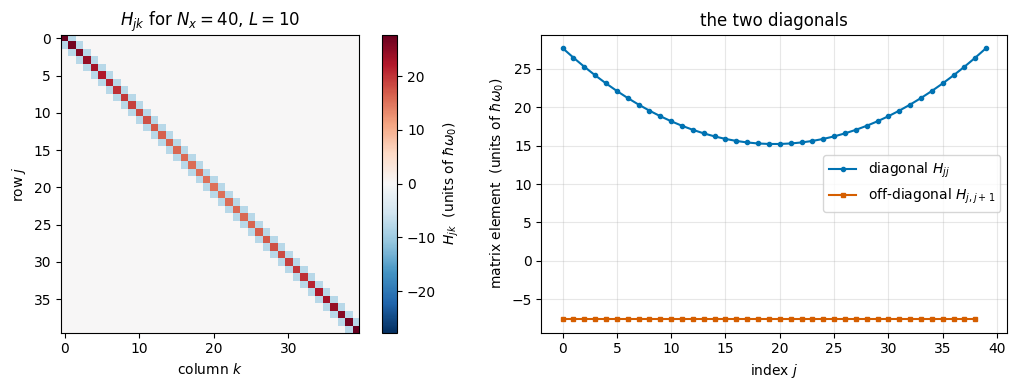

non-zero entries: 118 out of 1600  (= 3 N_x - 2 = 118)


In [7]:
# ==============================================================================
# STEP 5: what a tridiagonal matrix looks like
# ==============================================================================
x_pic, dx_pic = make_grid(L=10.0, N_x=40)
H_pic = hamiltonian_dense(x_pic, dx_pic)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
im = axes[0].imshow(H_pic, cmap="RdBu_r", vmin=-np.max(np.abs(H_pic)), vmax=np.max(np.abs(H_pic)))
axes[0].set_title(r"$H_{jk}$ for $N_x=40$, $L=10$")
axes[0].set_xlabel(r"column $k$"); axes[0].set_ylabel(r"row $j$")
fig.colorbar(im, ax=axes[0], label=r"$H_{jk}$  (units of $\hbar\omega_0$)")

axes[1].plot(np.diag(H_pic), "o-", color=C_NUM, ms=3, label=r"diagonal $H_{jj}$")
axes[1].plot(np.diag(H_pic, k=1), "s-", color=C_EXACT, ms=3, label=r"off-diagonal $H_{j,j+1}$")
axes[1].set_xlabel(r"index $j$"); axes[1].set_ylabel(r"matrix element  (units of $\hbar\omega_0$)")
axes[1].set_title("the two diagonals"); axes[1].legend(); axes[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

print(f"non-zero entries: {np.count_nonzero(H_pic)} out of {H_pic.size}  "
      f"(= 3 N_x - 2 = {3*40-2})")

The left panel shows the three stripes; everything else is exactly zero. The right panel shows the parabola
$1/\Delta x^2 + x_j^2/2$ on the diagonal and the constant $-1/(2\Delta x^2)$ off it. Storing the full square when
only three stripes are non-zero is the kind of waste that decides whether a calculation fits in memory — a theme
that returns with full force when we reach many-body systems.

## 7. Diagonalisation: the energy levels

### 7.1 What an eigensolver returns, and how it normalises

`scipy.linalg.eigh_tridiagonal(d, e)` solves $H v = \lambda v$ for a real symmetric tridiagonal matrix given by its
main diagonal `d` and its off-diagonal `e`. It returns a pair `(w, V)`:

* `w` is a 1-D array of eigenvalues in **ascending** order, `w[n]` $= E_n$;
* `V` is a 2-D array whose **columns** are the eigenvectors: `V[:, n]` is the eigenvector belonging to `w[n]`.
  (A very common bug is to use the rows. If in doubt, check $H\,V[:,n] = w[n]\,V[:,n]$ — we do it below.)

The eigenvectors come back normalised **as vectors**,

$$ \sum_{j} \vert V_{jn} \vert^2 = 1 , $$

but we want wave functions normalised **as functions** on the grid (Section 5.4),

$$ \sum_j \vert\phi_n(x_j)\vert^2\,\Delta x = 1 . $$

Comparing the two lines gives the conversion, and it is the single most common source of factor-of-$\sqrt{\Delta x}$
confusion in grid-based quantum mechanics:

$$ \boxed{\;\phi_n(x_j) \;=\; \frac{V_{jn}}{\sqrt{\Delta x}}\;} \tag{9} $$

Finally, an eigenvector is only defined up to a sign (if $v$ is one, so is $-v$), and LAPACK does not promise
anything. We fix the convention of the textbook Hermite functions: $\phi_n(x) > 0$ in its **outermost lobe on the
right**, i.e. at the largest $x$ where the amplitude is still appreciable.

In [8]:
# ==============================================================================
# STEP 6: solve the eigenvalue problem, with the grid normalisation and a fixed sign
# ==============================================================================
def solve_eigenstates(x, dx, n_states, freq_ratio=1.0):
    """Lowest `n_states` eigenpairs of the discretised Hamiltonian, Eq. (8).

    MATH
        H phi_n = E_n phi_n ,   sum_j |phi_n(x_j)|^2 dx = 1   [grid normalisation, Eq. (9)]

    IMPLEMENTATION
        `eigh_tridiagonal` with select="i" asks only for the eigenpairs with indices 0..n_states-1,
        which is much cheaper than the whole spectrum.  Its eigenvectors sit in the COLUMNS of V and
        satisfy sum_j V[j,n]^2 = 1, so we transpose (one row per state) and divide by sqrt(dx).
        The global sign is fixed so that phi_n > 0 in its outermost right-hand lobe (Hermite convention).

    COST   O(n_states * N_x) memory, roughly O(N_x * n_states) time for the vectors.

    RETURNS
        E    (n_states,)        energies in units of hbar*omega_0
        phi  (n_states, N_x)    eigenfunctions, one per ROW
    """
    diag, off = hamiltonian_tridiagonal(x, dx, freq_ratio)
    E, V = eigh_tridiagonal(diag, off, select="i", select_range=(0, n_states - 1))
    phi = V.T / np.sqrt(dx)                              # rows = states, grid normalisation
    for n in range(n_states):                            # fix the arbitrary global sign
        big = np.nonzero(np.abs(phi[n]) > 0.5 * np.max(np.abs(phi[n])))[0]
        phi[n] *= np.sign(phi[n][big[-1]])               # positive in the outermost right lobe
    return E.astype(RDTYPE), phi.astype(RDTYPE)


# ---- the production grid for all static calculations of this notebook --------------
L_STAT, NX_STAT, N_STATES = 20.0, 1001, 40
x_stat, dx_stat = make_grid(L_STAT, NX_STAT)
t_start = time.time()
E_stat, phi_stat = solve_eigenstates(x_stat, dx_stat, N_STATES)
print(f"grid: L = {L_STAT}, N_x = {NX_STAT}, dx = {dx_stat:.4f}   "
      f"({N_STATES} eigenpairs in {time.time() - t_start:.2f} s)")

# CHECKPOINT 1: is V[:, n] really an eigenvector?  (residual of the eigenvalue equation)
H_stat_dense = hamiltonian_dense(x_stat, dx_stat)
residual = np.max(np.abs(H_stat_dense @ phi_stat[3] - E_stat[3] * phi_stat[3]))
print(f"\n|H phi_3 - E_3 phi_3|_max = {residual:.3e}")
assert residual < 1e-8, "the returned vectors do not satisfy H v = E v"

# CHECKPOINT 2: grid normalisation and orthogonality
norms = np.sum(phi_stat**2, axis=1) * dx_stat
overlap_01 = np.sum(phi_stat[0] * phi_stat[1]) * dx_stat
print(f"sum_j |phi_n|^2 dx  (n = 0..4)   = {np.array2string(norms[:5], precision=12)}")
print(f"<phi_0|phi_1> on the grid        = {overlap_01:.3e}")
assert np.max(np.abs(norms - 1.0)) < 1e-12 and abs(overlap_01) < 1e-12
print("checkpoints passed: eigenvectors, unit norm on the grid, orthogonality")

grid: L = 20.0, N_x = 1001, dx = 0.0200   (40 eigenpairs in 0.30 s)

|H phi_3 - E_3 phi_3|_max = 8.339e-12


sum_j |phi_n|^2 dx  (n = 0..4)   = [1. 1. 1. 1. 1.]
<phi_0|phi_1> on the grid        = 7.105e-17


checkpoints passed: eigenvectors, unit norm on the grid, orthogonality


### 7.2 The first numbers, against $n + 1/2$

The computer knew nothing about Hermite polynomials or creation operators; it received a tridiagonal matrix
built from Taylor's theorem, and nothing else.

In [9]:
# ==============================================================================
# STEP 7: numerical levels versus the exact E_n = n + 1/2
# ==============================================================================
n_show = 10
n_idx = np.arange(n_show)
E_exact = n_idx + 0.5

print(f"{'n':>3s} {'E_n (numerical)':>18s} {'E_n = n+1/2':>14s} {'absolute error':>16s} {'relative':>12s}")
for n in n_idx:
    err = E_stat[n] - E_exact[n]
    print(f"{n:3d} {E_stat[n]:18.10f} {E_exact[n]:14.1f} {err:16.3e} {abs(err)/E_exact[n]:12.3e}")

# spacings: the hallmark of the harmonic oscillator
spacings = np.diff(E_stat[:n_show])
print(f"\nlevel spacings E_(n+1) - E_n : {np.array2string(spacings, precision=6)}")
print(f"they should all equal 1 (i.e. hbar*omega_0); max deviation = {np.max(np.abs(spacings - 1.0)):.3e}")
print(f"(Section 8.2 will derive this deviation: -(dx^2/32)(4n+4), i.e. "
      f"{-dx_stat**2 / 32 * (4 * (n_show - 2) + 4):.3e} for the last pair shown)")

# CHECKPOINT: the lowest ten levels agree with n + 1/2 to better than 4e-3 (Eq. (10) predicts 2.3e-3 for n = 9)
assert np.max(np.abs(E_stat[:n_show] - E_exact)) < 4e-3
print("checkpoint passed: the spectrum of a tridiagonal matrix reproduces E_n = n + 1/2")

  n    E_n (numerical)    E_n = n+1/2   absolute error     relative
  0       0.4999874997            0.5       -1.250e-05    2.500e-05
  1       1.4999374972            1.5       -6.250e-05    4.167e-05
  2       2.4998374891            2.5       -1.625e-04    6.500e-05
  3       3.4996874716            3.5       -3.125e-04    8.929e-05
  4       4.4994874409            4.5       -5.126e-04    1.139e-04
  5       5.4992373934            5.5       -7.626e-04    1.387e-04
  6       6.4989373252            6.5       -1.063e-03    1.635e-04
  7       7.4985872327            7.5       -1.413e-03    1.884e-04
  8       8.4981871120            8.5       -1.813e-03    2.133e-04
  9       9.4977369594            9.5       -2.263e-03    2.382e-04

level spacings E_(n+1) - E_n : [0.99995 0.9999  0.99985 0.9998  0.99975 0.9997  0.99965 0.9996  0.99955]
they should all equal 1 (i.e. hbar*omega_0); max deviation = 4.502e-04


(Section 8.2 will derive this deviation: -(dx^2/32)(4n+4), i.e. -4.500e-04 for the last pair shown)
checkpoint passed: the spectrum of a tridiagonal matrix reproduces E_n = n + 1/2


Ten digits of $E_0 = 0.4999875$ against the exact $0.5$. The **equal spacing** is reproduced to $5\times10^{-4}$ —
and that equal spacing is the entire physics of the harmonic oscillator: it is why a molecule absorbs light at one
sharp frequency, and why an $LC$ resonator alone cannot be a qubit (you cannot address one transition without
driving all the others).

Notice that the errors are **negative** and grow with $n$. That is not an accident; Section 8.2 predicts both facts
from Eq. (7).

## 8. Convergence: the grid spacing and the box size

There are exactly two knobs, and they must be turned one at
a time.

### 8.1 Refining the grid at fixed box size

Keep $L = 20$ and increase $N_x$, so $\Delta x = L/(N_x-1)$ shrinks. From Eq. (7) the error should fall like
$\Delta x^2 \propto N_x^{-2}$: on log-log axes, a straight line of slope $-2$.

In [10]:
# ==============================================================================
# STEP 8: convergence of E_n with the number of grid points (L fixed)
# ==============================================================================
def levels_only(L, N_x, n_max, freq_ratio=1.0):
    """The lowest n_max+1 eigenVALUES only -- much cheaper than also computing the vectors."""
    x, dx = make_grid(L, N_x)
    diag, off = hamiltonian_tridiagonal(x, dx, freq_ratio)
    return eigh_tridiagonal(diag, off, select="i", select_range=(0, n_max), eigvals_only=True)


N_LIST = np.array([51, 101, 201, 401, 801, 1601, 3201])
N_PROBE = [0, 2, 5, 10]                                   # which levels we track
L_CONV = 20.0

t_start = time.time()
err_vs_N = np.zeros((len(N_LIST), len(N_PROBE)))
dx_list = np.zeros(len(N_LIST))
for i, N_x in enumerate(N_LIST):
    E_num = levels_only(L_CONV, N_x, max(N_PROBE))
    dx_list[i] = L_CONV / (N_x - 1)
    err_vs_N[i] = [E_num[n] - (n + 0.5) for n in N_PROBE]
print(f"convergence scan ({len(N_LIST)} diagonalisations) in {time.time() - t_start:.2f} s")

print(f"\n{'N_x':>6s} {'dx':>9s} " + " ".join(f"{'err n=' + str(n):>12s}" for n in N_PROBE))
for i, N_x in enumerate(N_LIST):
    print(f"{N_x:6d} {dx_list[i]:9.5f} " + " ".join(f"{e:12.4e}" for e in err_vs_N[i]))

convergence scan (7 diagonalisations) in 1.62 s

   N_x        dx      err n=0      err n=2      err n=5     err n=10
    51   0.40000  -5.0516e-03  -6.6888e-02  -3.2506e-01  -1.2716e+00
   101   0.20000  -1.2531e-03  -1.6361e-02  -7.7355e-02  -2.8406e-01
   201   0.10000  -3.1270e-04  -4.0694e-03  -1.9130e-02  -6.9525e-02
   401   0.05000  -7.8137e-05  -1.0161e-03  -4.7698e-03  -1.7294e-02
   801   0.02500  -1.9532e-05  -2.5393e-04  -1.1917e-03  -4.3182e-03
  1601   0.01250  -4.8829e-06  -6.3478e-05  -2.9787e-04  -1.0792e-03
  3201   0.00625  -1.2207e-06  -1.5869e-05  -7.4464e-05  -2.6978e-04


### 8.2 Predicting the error before measuring it

We can do better than "slope $-2$". Equation (7) says that the discrete kinetic operator is not $-\tfrac12 d^2/dx^2$
but

$$ \hat T_{\rm disc} = -\frac{1}{2}\left(\frac{d^2}{dx^2} + \frac{\Delta x^2}{12}\frac{d^4}{dx^4}\right) + O(\Delta x^4)
   = \hat T - \frac{\Delta x^2}{24}\,\frac{d^4}{dx^4} + O(\Delta x^4). $$

So the matrix we diagonalise is $H + \delta H$ with the small perturbation

$$ \delta H = -\frac{\Delta x^2}{24}\,\frac{d^4}{dx^4} = -\frac{\Delta x^2}{24}\,\hat p^{\,4} , $$

because in our units $\hat p = -i\,d/dx$, hence $\hat p^{\,4} = d^4/dx^4$. First-order perturbation theory gives
the shift of the $n$-th level as the expectation value of $\delta H$ in the *unperturbed* state:

$$ \Delta E_n \;=\; \langle \phi_n \vert \delta H \vert \phi_n\rangle
   \;=\; -\frac{\Delta x^2}{24}\,\langle \phi_n \vert \hat p^{\,4} \vert \phi_n\rangle . $$

The matrix element is a standard oscillator result. With $\hat x = (a + a^\dagger)/\sqrt2$ and
$\hat p = i(a^\dagger - a)/\sqrt2$ one finds $\langle n \vert \hat p^{\,4}\vert n\rangle =
\langle n \vert \hat x^{4}\vert n\rangle = \tfrac{3}{4}\left(2n^2 + 2n + 1\right)$. (Quick route: insert a complete
set, $\langle \hat p^4\rangle = \sum_m \vert\langle m\vert \hat p^2\vert n\rangle\vert^2$, and use that
$\hat p^2$ only connects $n$ to $n$ and $n\pm2$.) Therefore

$$ \boxed{\;\Delta E_n \;\simeq\; -\frac{\Delta x^2}{32}\left(2n^2 + 2n + 1\right)\;} \tag{10} $$

Three predictions to test: the error is **negative** (the grid *underestimates* the energies), it scales as
$\Delta x^2$, and it grows like $n^2$ — high levels converge much more slowly, because they wiggle faster and the
grid resolves them less well.

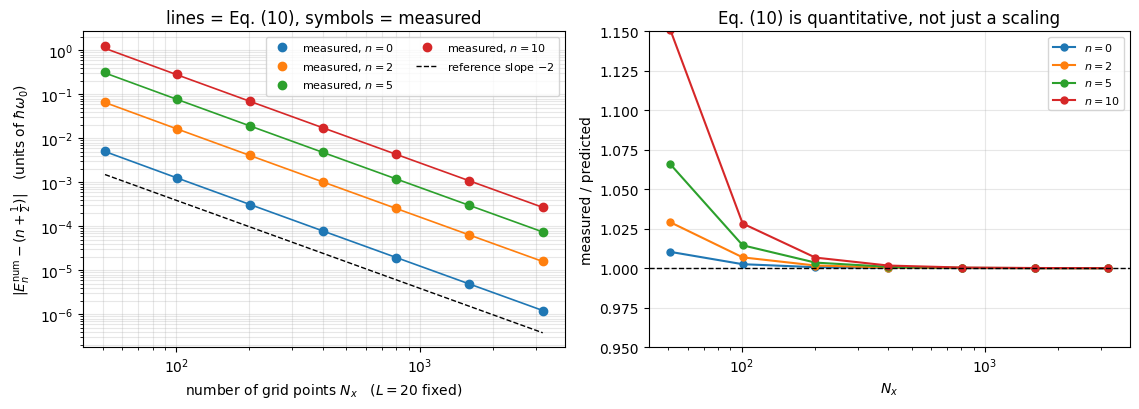

measured/predicted on the two finest grids: min = 1.0000, max = 1.0001
checkpoint passed: first-order perturbation theory in dx^2 predicts the discretisation error to <1%


In [11]:
# ==============================================================================
# STEP 9: measured error vs the prediction of Eq. (10)
# ==============================================================================
def predicted_error(dx, n):
    """Eq. (10):  Delta E_n = -(dx^2/32) (2 n^2 + 2 n + 1)."""
    return -dx**2 / 32.0 * (2.0 * n**2 + 2.0 * n + 1.0)


fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# --- left: error vs N_x on log-log axes, with the predicted curves ---
for k, n in enumerate(N_PROBE):
    axes[0].loglog(N_LIST, np.abs(err_vs_N[:, k]), "o", color=f"C{k}", ms=6,
                   label=rf"measured, $n={n}$")
    axes[0].loglog(N_LIST, np.abs(predicted_error(L_CONV / (N_LIST - 1), n)), "-", color=f"C{k}", lw=1.2)
axes[0].loglog(N_LIST, 1.5e-3 * (N_LIST / N_LIST[0]) ** (-2.0), "k--", lw=1,
               label=r"reference slope $-2$")
axes[0].set_xlabel(r"number of grid points $N_x$   ($L=20$ fixed)")
axes[0].set_ylabel(r"$\vert E_n^{\rm num} - (n+\frac{1}{2})\vert$   (units of $\hbar\omega_0$)")
axes[0].set_title("lines = Eq. (10), symbols = measured")
axes[0].legend(fontsize=8, ncol=2); axes[0].grid(which="both", alpha=.3)

# --- right: ratio measured/predicted, should be 1 ---
for k, n in enumerate(N_PROBE):
    axes[1].semilogx(N_LIST, err_vs_N[:, k] / predicted_error(L_CONV / (N_LIST - 1), n),
                     "o-", color=f"C{k}", ms=5, label=rf"$n={n}$")
axes[1].axhline(1.0, color="k", ls="--", lw=1)
axes[1].set_xlabel(r"$N_x$"); axes[1].set_ylabel("measured / predicted")
axes[1].set_ylim(0.95, 1.15); axes[1].set_title("Eq. (10) is quantitative, not just a scaling")
axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

# CHECKPOINT: on the finest grids the prediction is accurate to better than 1 %
ratio_fine = err_vs_N[-2:] / predicted_error(dx_list[-2:, None], np.array(N_PROBE)[None, :])
print(f"measured/predicted on the two finest grids: "
      f"min = {ratio_fine.min():.4f}, max = {ratio_fine.max():.4f}")
assert np.all(np.abs(ratio_fine - 1.0) < 0.01)
print("checkpoint passed: first-order perturbation theory in dx^2 predicts the discretisation error to <1%")

The symbols fall on the predicted lines over the whole plot — nearly four decades of error for each individual
level, six decades across the panel — and the ratio is $1.000$ on the fine grids. Read the
left panel as a practical tool: it tells you *in advance* how many grid points you need. Want $E_{10}$ to
$10^{-6}$? Equation (10) gives $\Delta x^2 \le 32\times10^{-6}/(2\cdot100+2\cdot10+1) = 1.4\times10^{-7}$, i.e.
$\Delta x \le 3.8\times10^{-4}$, i.e. $N_x \gtrsim 53\,000$ for $L=20$. That is the cost of a second-order
method, and it is the reason Exercise 3 asks you to build a fourth-order one.

> **Numerical practice.** "It converges" is worth little; "it converges at the rate my derivation predicts" is
> worth a lot. If the measured slope disagrees with the derived one, there is a bug — in the code or in the
> derivation. Both are worth finding.

### 8.3 Shrinking the box at fixed resolution

Now the other knob. Fix $\Delta x = 0.02$ and vary $L$. If $L$ is too small, the hard walls — not the potential —
decide the energies, and we are simulating a particle in a box.

     L    N_x          E_0          E_2          E_5   turning point sqrt(2 E_n) of the highest level shown
   3.0    151     0.678012     5.164392    19.578330      x_tp(n=5) = 3.32,  L/2 = 1.5
   4.0    201     0.534846     3.357029    11.551849      x_tp(n=5) = 3.32,  L/2 = 2.0
   5.0    251     0.504510     2.722515     8.055339      x_tp(n=5) = 3.32,  L/2 = 2.5
   6.0    301     0.500337     2.537738     6.428490      x_tp(n=5) = 3.32,  L/2 = 3.0
   7.0    351     0.500003     2.503404     5.741892      x_tp(n=5) = 3.32,  L/2 = 3.5
   8.0    401     0.499988     2.500014     5.535227      x_tp(n=5) = 3.32,  L/2 = 4.0
  10.0    501     0.499987     2.499838     5.499322      x_tp(n=5) = 3.32,  L/2 = 5.0
  12.0    601     0.499987     2.499837     5.499237      x_tp(n=5) = 3.32,  L/2 = 6.0
  16.0    801     0.499987     2.499837     5.499237      x_tp(n=5) = 3.32,  L/2 = 8.0
  20.0   1001     0.499987     2.499837     5.499237      x_tp(n=5) = 3.32,  L/2 = 10.0


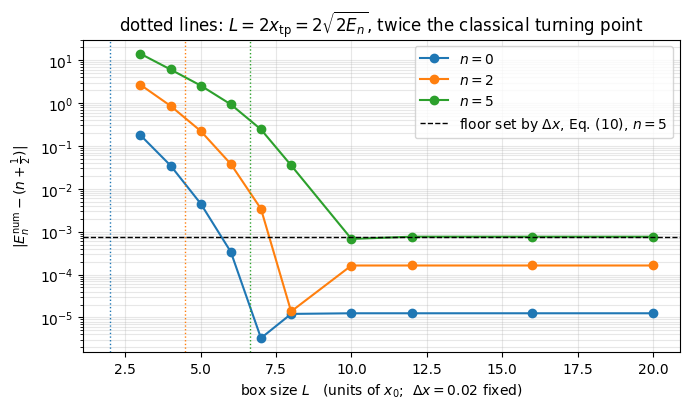

checkpoint passed: at L = 20 the n=5 error is 7.626e-04, the dx-limited floor of Eq. (10) is 7.625e-04


In [12]:
# ==============================================================================
# STEP 10: convergence in the box size L at fixed dx
# ==============================================================================
DX_BOX = 0.02
L_LIST = np.array([3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 16.0, 20.0])
N_BOX = [0, 2, 5]

E_vs_L = np.zeros((len(L_LIST), max(N_BOX) + 1))
for i, L in enumerate(L_LIST):
    N_x = int(round(L / DX_BOX)) + 1
    E_vs_L[i] = levels_only(L, N_x, max(N_BOX))

print(f"{'L':>6s} {'N_x':>6s} " + " ".join(f"{'E_' + str(n):>12s}" for n in N_BOX)
      + "   turning point sqrt(2 E_n) of the highest level shown")
for i, L in enumerate(L_LIST):
    print(f"{L:6.1f} {int(round(L/DX_BOX))+1:6d} " + " ".join(f"{E_vs_L[i, n]:12.6f}" for n in N_BOX)
          + f"      x_tp(n={max(N_BOX)}) = {np.sqrt(2*(max(N_BOX)+0.5)):.2f},  L/2 = {L/2:.1f}")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for k, n in enumerate(N_BOX):
    ax.semilogy(L_LIST, np.abs(E_vs_L[:, n] - (n + 0.5)), "o-", color=f"C{k}", label=rf"$n={n}$")
    ax.axvline(2 * np.sqrt(2 * (n + 0.5)), color=f"C{k}", ls=":", lw=1)
ax.axhline(DX_BOX**2 / 32 * (2 * 5**2 + 2 * 5 + 1), color="k", ls="--", lw=1,
           label=r"floor set by $\Delta x$, Eq. (10), $n=5$")
ax.set_xlabel(r"box size $L$   (units of $x_0$;  $\Delta x = 0.02$ fixed)")
ax.set_ylabel(r"$\vert E_n^{\rm num} - (n+\frac{1}{2})\vert$")
ax.set_title(r"dotted lines: $L = 2 x_{\rm tp} = 2\sqrt{2E_n}$, twice the classical turning point")
ax.legend(); ax.grid(alpha=.3, which="both")
fig.tight_layout(); plt.show()

# CHECKPOINT: once L is large enough the error saturates at the dx-limited floor of Eq. (10)
floor_n5 = abs(predicted_error(DX_BOX, 5))
assert abs(abs(E_vs_L[-1, 5] - 5.5) - floor_n5) / floor_n5 < 0.05
print(f"checkpoint passed: at L = 20 the n=5 error is {abs(E_vs_L[-1,5]-5.5):.3e}, "
      f"the dx-limited floor of Eq. (10) is {floor_n5:.3e}")

For each level there is a threshold: the error falls off a cliff as soon as the box
comfortably contains the state, and then **stops falling** — it hits the floor set by $\Delta x$ through Eq. (10),
because at that point the box is no longer the limiting approximation.

Look closely at the $n=0$ and $n=2$ curves just before they flatten: they dip *below* their own floor and then
come back up to it. That is not noise. The two errors have **opposite signs** — squeezing the state into too
small a box pushes $E_n$ *up*, while the grid of Eq. (10) pushes it *down* — so at one particular $L$ they cancel
and the total error passes through zero. Never read such an accidental crossing as "converged": the giveaway is
that the dip moves when you change $\Delta x$, whereas a genuine plateau does not.

The threshold is set by the **classical turning point**. A classical particle of energy $E_n$ can only reach
$\vert x\vert \le x_{\rm tp}$ with $\tfrac12 x_{\rm tp}^2 = E_n$, i.e. $x_{\rm tp} = \sqrt{2E_n} = \sqrt{2n+1}$.
Beyond that the wave function decays like $e^{-x^2/2}$, so the box must contain the turning point *plus a few units
of decay*. The dotted lines mark $L = 2x_{\rm tp}$ and sit right where each curve starts to drop. Practical rule:

$$ \frac{L}{2} \;\gtrsim\; \sqrt{2n_{\max}+1} \;+\; 4 . $$

For $n_{\max}=5$ this gives $L \gtrsim 14.6$, consistent with what we see. And look at $L=3$: $E_0$ comes out near
$0.68$ instead of $0.5$, and $E_5$ near $19.6$ instead of $5.5$ — that is a particle in a box wearing an
oscillator's clothes.

> **Common pitfall.** Increasing $N_x$ while keeping $L$ fixed makes the plot on the left of Section 8.2 look
> beautiful even if $L$ is far too small. Always converge in *both* knobs; report both.

## 9. The eigenstates versus the Hermite functions

### 9.1 The analytic solution

In our dimensionless units the normalised eigenfunctions of Eq. (5) are the **Hermite functions** (Griffiths and
Schroeter, §2.3, derive them both algebraically and analytically)

$$ \phi_n(x) \;=\; \frac{1}{\pi^{1/4}}\,\frac{1}{\sqrt{2^n\,n!}}\; H_n(x)\; e^{-x^2/2}, \tag{11} $$

where $H_n$ is the physicists' Hermite polynomial, $H_0 = 1$, $H_1 = 2x$, $H_2 = 4x^2-2$, and so on. Coding
Eq. (11) literally is a trap: $2^n n!$ overflows and $H_n(x)$ grows enormously for large $\vert x\vert$, so the
ratio of two huge numbers loses all its digits. The cure is to build the *normalised functions directly* with a
recurrence. Starting from $H_{n+1} = 2xH_n - 2nH_{n-1}$ and inserting Eq. (11), the prefactors combine into

$$ \phi_{n+1}(x) = \sqrt{\frac{2}{n+1}}\;x\,\phi_n(x) \;-\; \sqrt{\frac{n}{n+1}}\;\phi_{n-1}(x), \tag{12} $$

starting from $\phi_0 = \pi^{-1/4} e^{-x^2/2}$ and $\phi_1 = \sqrt{2}\,x\,\phi_0$. Every quantity in Eq. (12) is of
order one, so nothing overflows. (This is the same trick that makes Chebyshev and Legendre expansions usable, and
we will meet it again in Chapter 5.)

In [13]:
# ==============================================================================
# STEP 11: the analytic eigenfunctions, built with a stable recurrence
# ==============================================================================
def hermite_functions(x, n_max):
    """Normalised harmonic-oscillator eigenfunctions phi_0 .. phi_n_max on the grid `x`.

    MATH
        phi_n(x) = pi^(-1/4) (2^n n!)^(-1/2) H_n(x) exp(-x^2/2)          [Eq. (11)]
        built from the STABLE recurrence for the normalised functions:   [Eq. (12)]
            phi_0     = pi^(-1/4) exp(-x^2/2)
            phi_1     = sqrt(2) x phi_0
            phi_(n+1) = sqrt(2/(n+1)) x phi_n - sqrt(n/(n+1)) phi_(n-1)

    IMPLEMENTATION
        Never form 2^n n! or H_n(x) separately: both overflow long before n = 50.
        Here every intermediate is O(1), so the recurrence is safe to n of several hundred.

    RETURNS  array of shape (n_max+1, len(x)), one state per ROW
    """
    phi = np.zeros((n_max + 1, len(x)), dtype=RDTYPE)
    phi[0] = np.pi**-0.25 * np.exp(-x**2 / 2.0)
    if n_max >= 1:
        phi[1] = np.sqrt(2.0) * x * phi[0]
    for n in range(1, n_max):
        phi[n + 1] = np.sqrt(2.0 / (n + 1)) * x * phi[n] - np.sqrt(n / (n + 1)) * phi[n - 1]
    return phi


phi_exact = hermite_functions(x_stat, N_STATES - 1)

# CHECKPOINT 1: the recurrence agrees with the literal formula (11) where the latter is still safe
print(f"{'n':>3s} {'max |recurrence - Eq.(11)|':>28s} {'norm on the grid':>20s}")
for n in [0, 1, 2, 5, 10]:
    literal = (eval_hermite(n, x_stat) * np.exp(-x_stat**2 / 2.0)
               / np.sqrt(2.0**n * math.factorial(n) * np.sqrt(np.pi)))
    print(f"{n:3d} {np.max(np.abs(literal - phi_exact[n])):28.3e} "
          f"{np.sum(phi_exact[n]**2) * dx_stat:20.12f}")
grid_norms = np.sum(phi_exact**2, axis=1) * dx_stat
assert np.max(np.abs(grid_norms[:26] - 1.0)) < 1e-10
print("\ncheckpoint passed: the recurrence reproduces Eq. (11) to machine precision, and the Riemann sum")
print("                  gives unit norm to 1e-10 for n <= 25")
print(f"(for comparison, the literal formula needs 2^n n! = {2.0**60 * math.factorial(60):.3e} at n = 60)")
print(f"\nbut watch the top of the list: 1 - norm  =  {1 - grid_norms[30]:.2e} at n = 30 and "
      f"{1 - grid_norms[39]:.2e} at n = 39.")
print(f"That is the BOX, not the recurrence: the turning point sqrt(2n+1) = {np.sqrt(2*39+1):.2f} at n = 39 is "
      f"already close to the wall at L/2 = {L_STAT/2:.0f},")
print("so part of the state is cut off -- exactly the failure mode of Section 8.3. The analytic functions are "
      "not immune to a box that is too small.")

  n   max |recurrence - Eq.(11)|     norm on the grid
  0                    1.110e-16       1.000000000000
  1                    2.220e-16       1.000000000000
  2                    2.220e-16       1.000000000000
  5                    5.551e-16       1.000000000000
 10                    1.277e-15       1.000000000000



checkpoint passed: the recurrence reproduces Eq. (11) to machine precision, and the Riemann sum
                  gives unit norm to 1e-10 for n <= 25
(for comparison, the literal formula needs 2^n n! = 9.593e+99 at n = 60)

but watch the top of the list: 1 - norm  =  6.46e-11 at n = 30 and 7.37e-06 at n = 39.
That is the BOX, not the recurrence: the turning point sqrt(2n+1) = 8.89 at n = 39 is already close to the wall at L/2 = 10,
so part of the state is cut off -- exactly the failure mode of Section 8.3. The analytic functions are not immune to a box that is too small.


### 9.2 Numerics against analytics

Now the comparison that gives this notebook its title. The eigenvectors of a $1001\times1001$ tridiagonal matrix
are plotted on top of Eq. (11).

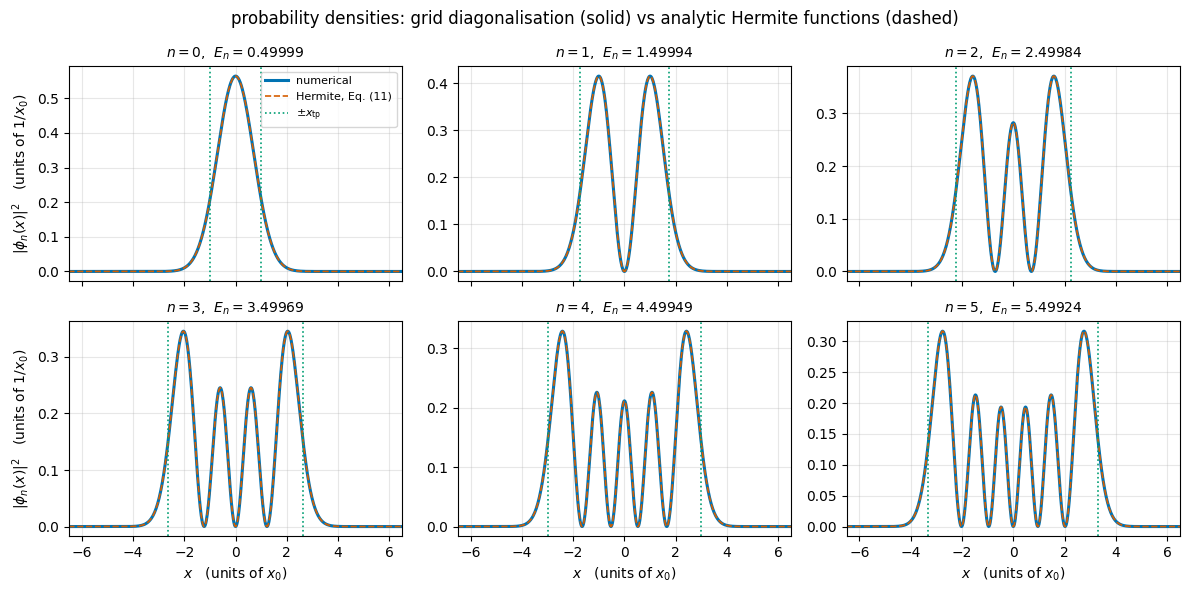

  n   max |phi_num - phi_ex|   max |dens difference|   1 - <phi_num|phi_ex>    <x^2> num    n+1/2
  0                1.180e-05               1.763e-05              1.693e-10     0.499975      0.5
  1                3.095e-05               3.294e-05              1.367e-09     1.499875      1.5
  2                6.284e-05               5.385e-05              5.457e-09     2.499675      2.5
  3                1.145e-04               8.219e-05              1.583e-08     3.499375      3.5
  4                1.820e-04               1.162e-04              3.756e-08     4.498975      4.5
  5                2.628e-04               1.550e-04              7.742e-08     5.498475      5.5
  6                3.547e-04               1.976e-04              1.439e-07     6.497874      6.5
  7                4.565e-04               2.443e-04              2.472e-07     7.497174      7.5



checkpoints passed: same sign convention, overlaps > 0.999, and <x^2>_n = n + 1/2 to 2.8e-03


In [14]:
# ==============================================================================
# STEP 12: numerical eigenfunctions vs Hermite functions
# ==============================================================================
n_panels = [0, 1, 2, 3, 4, 5]
fig, axes = plt.subplots(2, 3, figsize=(12.0, 6.0), sharex=True)
for ax, n in zip(axes.ravel(), n_panels):
    ax.plot(x_stat, phi_stat[n]**2, color=C_NUM, lw=2.2, label="numerical")
    ax.plot(x_stat, phi_exact[n]**2, color=C_EXACT, lw=1.2, ls="--", label="Hermite, Eq. (11)")
    x_tp = np.sqrt(2 * (n + 0.5))
    ax.axvline(+x_tp, color=C_HL, ls=":", lw=1.2)
    ax.axvline(-x_tp, color=C_HL, ls=":", lw=1.2, label=r"$\pm x_{\rm tp}$")
    ax.set_xlim(-6.5, 6.5)
    ax.set_title(rf"$n={n}$,  $E_n = {E_stat[n]:.5f}$", fontsize=10)
    ax.grid(alpha=.3)
    if n == 0:
        ax.legend(fontsize=8)
for ax in axes[1]:
    ax.set_xlabel(r"$x$   (units of $x_0$)")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\vert\phi_n(x)\vert^2$   (units of $1/x_0$)")
fig.suptitle("probability densities: grid diagonalisation (solid) vs analytic Hermite functions (dashed)")
fig.tight_layout(); plt.show()

# ---- quantify the agreement -------------------------------------------------------
print(f"{'n':>3s} {'max |phi_num - phi_ex|':>24s} {'max |dens difference|':>23s} "
      f"{'1 - <phi_num|phi_ex>':>22s} {'<x^2> num':>12s} {'n+1/2':>8s}")
for n in range(8):
    overlap = np.sum(phi_stat[n] * phi_exact[n]) * dx_stat
    x2_num = np.sum(x_stat**2 * phi_stat[n]**2) * dx_stat
    print(f"{n:3d} {np.max(np.abs(phi_stat[n] - phi_exact[n])):24.3e} "
          f"{np.max(np.abs(phi_stat[n]**2 - phi_exact[n]**2)):23.3e} "
          f"{1 - overlap:22.3e} {x2_num:12.6f} {n + 0.5:8.1f}")

# CHECKPOINT: sign convention, wave functions and <x^2> = n + 1/2 all agree
overlaps = np.sum(phi_stat[:8] * phi_exact[:8], axis=1) * dx_stat
assert np.all(overlaps > 0.999), "sign convention or shape mismatch"
x2_all = np.sum(x_stat**2 * phi_stat[:8]**2, axis=1) * dx_stat
assert np.max(np.abs(x2_all - (np.arange(8) + 0.5))) < 5e-3
print(f"\ncheckpoints passed: same sign convention, overlaps > 0.999, "
      f"and <x^2>_n = n + 1/2 to {np.max(np.abs(x2_all - (np.arange(8) + 0.5))):.1e}")

The curves are indistinguishable by eye; the numbers say the wave functions agree to a few times $10^{-4}$ and
the overlaps $\langle\phi_n^{\rm num}\vert\phi_n^{\rm exact}\rangle$ differ from $1$ by a few times $10^{-7}$
at worst (and by $2\times10^{-10}$ for the ground state).
(An overlap is a *second-order* quantity: if the error in the state is $\epsilon$, the overlap deviates from $1$ by
only $\epsilon^2/2$ — which is why overlaps always look better than pointwise differences. Both are reported above
so that you learn to read the difference.)

We also confirmed $\langle x^2\rangle_n = n + \tfrac12$, the virial theorem at work: in the oscillator the average
kinetic and potential energies are equal, so $\tfrac12\langle x^2\rangle = \tfrac12 E_n$.

### 9.3 The classic picture, and the correspondence principle

Every quantum-mechanics textbook has this figure: the parabola, the horizontal levels, and the densities drawn on
top of them. The cell below assembles it from the eigenvalues and eigenvectors computed in Section 7.

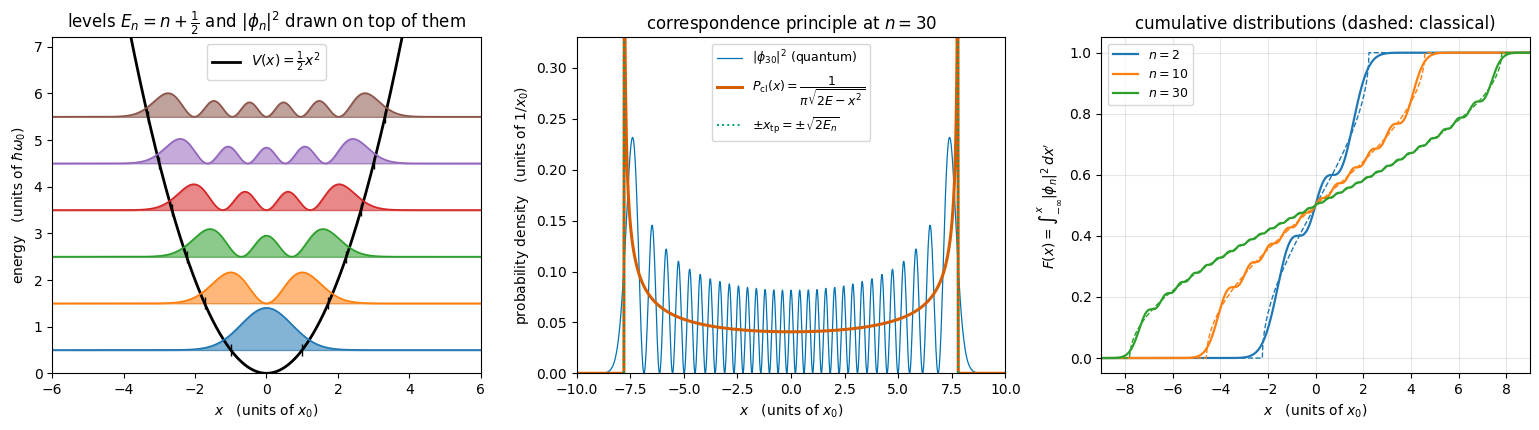

   n    sup |F_quantum - F_classical|   attained at x    x/x_tp
   0                           0.1010           0.580     0.580
   1                           0.0684           1.400     0.808
   2                           0.0572           1.920     0.859
   5                           0.0436           3.040     0.917
  10                           0.0351           4.340     0.947
  20                           0.0281           6.180     0.965
  30                           0.0247           7.600     0.973

measured decay of the distance with n (fit over n = 2..30): distance ~ n^(-0.31)
checkpoint passed: the quantum and classical cumulative distributions converge monotonically;
                  at n = 30 they never differ by more than 0.025 in probability


In [15]:
# ==============================================================================
# STEP 13: levels and densities inside the potential + the classical limit
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))

# --- left: the textbook picture ---
ax = axes[0]
x_plot = x_stat[np.abs(x_stat) <= 6.0]
ax.plot(x_plot, 0.5 * x_plot**2, color="k", lw=2, label=r"$V(x)=\frac{1}{2} x^2$")
scale = 1.6                                             # visual scale of the densities
for n in range(6):
    dens = phi_stat[n][np.abs(x_stat) <= 6.0] ** 2
    ax.axhline(E_stat[n], color="0.8", lw=.8, zorder=0)
    ax.fill_between(x_plot, E_stat[n], E_stat[n] + scale * dens, color=f"C{n}", alpha=.55)
    ax.plot(x_plot, E_stat[n] + scale * dens, color=f"C{n}", lw=1.2)
    x_tp = np.sqrt(2 * E_stat[n])
    ax.plot([-x_tp, x_tp], [E_stat[n], E_stat[n]], "|", color="k", ms=9)
ax.set_xlim(-6, 6); ax.set_ylim(0, 7.2)
ax.set_xlabel(r"$x$   (units of $x_0$)")
ax.set_ylabel(r"energy   (units of $\hbar\omega_0$)")
ax.set_title(r"levels $E_n=n+\frac{1}{2}$ and $\vert\phi_n\vert^2$ drawn on top of them")
ax.legend(loc="upper center")

# --- middle: correspondence principle at n = 30 ---
ax = axes[1]
n_big = 30
E_big = E_stat[n_big]
x_tp = np.sqrt(2 * E_big)
mask = np.abs(x_stat) < x_tp * 0.999
P_classical = np.zeros_like(x_stat)
P_classical[mask] = 1.0 / (np.pi * np.sqrt(2 * E_big - x_stat[mask]**2))
ax.plot(x_stat, phi_stat[n_big]**2, color=C_NUM, lw=.9, label=rf"$\vert\phi_{{{n_big}}}\vert^2$ (quantum)")
ax.plot(x_stat, P_classical, color=C_EXACT, lw=2.2,
        label=r"$P_{\rm cl}(x)=\dfrac{1}{\pi\sqrt{2E-x^2}}$")
ax.axvline(+x_tp, color=C_HL, ls=":", lw=1.4)
ax.axvline(-x_tp, color=C_HL, ls=":", lw=1.4, label=r"$\pm x_{\rm tp}=\pm\sqrt{2E_n}$")
ax.set_xlim(-10, 10); ax.set_ylim(0, 0.33)
ax.set_xlabel(r"$x$   (units of $x_0$)"); ax.set_ylabel(r"probability density   (units of $1/x_0$)")
ax.set_title(rf"correspondence principle at $n={n_big}$")
ax.legend(fontsize=9)


# --- right: the same statement, made quantitative with cumulative distributions ---
def cumulative_quantum(phi_n, dx):
    """F(x) = int_{-inf}^{x} |phi_n|^2 dx' -- a running Riemann sum."""
    return np.cumsum(np.abs(phi_n)**2) * dx


def cumulative_classical(x, E):
    """F_cl(x) = (1/pi) [arcsin(x/x_tp) + pi/2], the integral of P_cl; 0 and 1 outside the turning points."""
    return (np.arcsin(np.clip(x / np.sqrt(2.0 * E), -1.0, 1.0)) + 0.5 * np.pi) / np.pi


ax = axes[2]
for k, n in enumerate([2, 10, 30]):
    ax.plot(x_stat, cumulative_quantum(phi_stat[n], dx_stat), color=f"C{k}", lw=1.6, label=rf"$n={n}$")
    ax.plot(x_stat, cumulative_classical(x_stat, E_stat[n]), color=f"C{k}", lw=1.0, ls="--")
ax.set_xlim(-9, 9)
ax.set_xlabel(r"$x$   (units of $x_0$)"); ax.set_ylabel(r"$F(x)=\int_{-\infty}^{x}\vert\phi_n\vert^2\,dx'$")
ax.set_title("cumulative distributions (dashed: classical)")
ax.legend(fontsize=9); ax.grid(alpha=.3)
fig.tight_layout(); plt.show()

# The densities themselves never converge pointwise (phi_n keeps oscillating), but their INTEGRALS do.
# The largest gap between the two cumulative distributions is the standard "Kolmogorov distance".
print(f"{'n':>4s} {'sup |F_quantum - F_classical|':>32s} {'attained at x':>15s} {'x/x_tp':>9s}")
n_list_corr = [0, 1, 2, 5, 10, 20, 30]
kolmogorov = []
for n in n_list_corr:
    gap = np.abs(cumulative_quantum(phi_stat[n], dx_stat) - cumulative_classical(x_stat, E_stat[n]))
    dist = np.max(gap)
    x_sup = x_stat[np.argmax(gap)]                       # WHERE the two descriptions disagree most
    kolmogorov.append(dist)
    print(f"{n:4d} {dist:32.4f} {x_sup:15.3f} {x_sup / np.sqrt(2 * E_stat[n]):9.3f}")
kolmogorov = np.array(kolmogorov)
slope = np.polyfit(np.log(np.array(n_list_corr[2:])), np.log(kolmogorov[2:]), 1)[0]
print(f"\nmeasured decay of the distance with n (fit over n = 2..30): distance ~ n^({slope:.2f})")
assert np.all(np.diff(kolmogorov) < 0), "the classical limit must improve monotonically with n"
assert kolmogorov[-1] < 0.03
print("checkpoint passed: the quantum and classical cumulative distributions converge monotonically;")
print(f"                  at n = 30 they never differ by more than {kolmogorov[-1]:.3f} in probability")

The left panel is the standard textbook figure, drawn here from the eigenvalues and eigenvectors of the
tridiagonal matrix. The small ticks mark the classical turning points $\pm\sqrt{2E_n}$; the wave function leaks
beyond them (tunnelling into the classically forbidden region), and the leak becomes relatively smaller as $n$
grows.

The middle panel is the **correspondence principle**. A classical particle oscillating with energy $E$ spends most
of its time near the turning points, where it moves slowly; the time it spends in $[x, x+dx]$ is
$dx/\vert v(x)\vert$ with $v = \sqrt{2E-x^2}$, and normalising gives
$P_{\rm cl}(x) = 1/(\pi\sqrt{2E-x^2})$, the orange curve. The quantum density at $n=30$ oscillates rapidly around it.

How do we turn "oscillates around it" into a number? Not by comparing the densities pointwise — $\vert\phi_n\vert^2$
hits zero $n+1$ times, so the pointwise difference never goes away however large $n$ is. What converges is the
**integrated** probability, so we compare the two *cumulative* distributions,

$$ F(x) = \int_{-\infty}^{x}\vert\phi_n(x')\vert^2 dx', \qquad
   F_{\rm cl}(x) = \int_{-\infty}^{x} P_{\rm cl}(x')dx' = \frac{1}{\pi}\left[\arcsin\frac{x}{x_{\rm tp}} + \frac{\pi}{2}\right], $$

and report the largest gap between them (the "Kolmogorov distance"). The right-hand panel shows the two curves for
$n=2, 10, 30$, and the printed table shows the distance falling monotonically — at $n=30$ the quantum and the
classical description never disagree about the probability of finding the particle in any interval by more than
$0.025$.

**Why $n^{-1/3}$.** The last column of the table says where the disagreement lives: the supremum is attained at
$x/x_{\rm tp} \to 1$, i.e. right at the classical turning point, and that is exactly where $P_{\rm cl}$ diverges
and the semiclassical picture fails. Near $x_{\rm tp}$ the wave function is an Airy function whose width is set
by the local slope of the potential, $\delta \sim \left(2V'(x_{\rm tp})\right)^{-1/3} = (2x_{\rm tp})^{-1/3}$.
The *classical* probability contained in a layer of that thickness is

$$ \int_{x_{\rm tp}-\delta}^{x_{\rm tp}} P_{\rm cl}\,dx \;\simeq\;
   \frac{1}{\pi}\int_0^{\delta}\frac{du}{\sqrt{2x_{\rm tp}\,u}}
   \;=\; \frac{\sqrt2}{\pi}\sqrt{\frac{\delta}{x_{\rm tp}}} \;\sim\; x_{\rm tp}^{-2/3} \;\sim\; n^{-1/3}, $$

using $x_{\rm tp}=\sqrt{2n+1}$. That layer is the one region where quantum and classical probabilities differ by
an $O(1)$ fraction, so it sets the size of the largest gap — hence $n^{-1/3}$. The fit over $n=2\ldots30$ gives
an exponent near $-0.31$; it approaches $-1/3$ only slowly, and on this $L=20$ grid the $n=20$ and $n=30$ entries
are themselves a few per cent too large because the box is starting to bite (Section 9.1). Exercise 7 asks you to
do the job properly. The table attaches a number, and a rate, to the statement that classical mechanics is quantum
mechanics with the wiggles unresolved.

## 10. What we will watch: position, momentum and their spreads

From here on the wave function moves, and we need a small set of numbers that summarise *how*. Four of them carry
almost all of the physics:

$$ \langle x\rangle(t), \qquad \mathrm{Var}(x)(t) = \langle x^2\rangle - \langle x\rangle^2, \qquad
   \langle p\rangle(t), \qquad \mathrm{Var}(p)(t) = \langle p^2\rangle - \langle p\rangle^2 . $$

The first pair says *where the packet is and how wide it is*; the second says *how fast it is moving and how
spread out its velocities are*. Their product is constrained by Heisenberg,
$\mathrm{Var}(x)\,\mathrm{Var}(p) \ge \tfrac14$ in our units.

In the dimensionless variables of Section 4 the momentum operator is

$$ \hat p \;=\; -\,i\,\frac{\partial}{\partial x}, \qquad [\hat x, \hat p] = i , $$

(the SI operator $-i\hbar\,\partial/\partial x$ divided by the momentum unit $\hbar/x_0 = \sqrt{\hbar m\omega_0}$),
and expectation values are

$$ \langle \hat p\rangle = \int \psi^{*}(x)\left(-i\frac{\partial\psi}{\partial x}\right) dx, \qquad
   \langle \hat p^{\,2}\rangle = \int \psi^{*}(x)\left(-\frac{\partial^2\psi}{\partial x^2}\right) dx . $$

Both are real, because $\hat p$ and $\hat p^2$ are Hermitian.

What makes the harmonic oscillator exceptional is that **all four of these functions of time can be written
down exactly**, for any initial state. That is what we derive now, and what the numerics will have to reproduce
three times over.

### 10.1 Ehrenfest's theorem: the centre moves classically

The derivation follows Sakurai and Napolitano, §§2.2.3–2.2.4. Start from the TDSE. For an operator $\hat A$ that does not depend on time,

$$ \frac{d}{dt}\langle \hat A\rangle
  = \left\langle \frac{\partial\psi}{\partial t}\right\vert \hat A \left\vert \psi \right\rangle
  + \left\langle \psi \right\vert \hat A \left\vert \frac{\partial\psi}{\partial t}\right\rangle
  = i\langle \psi\vert \hat H\hat A\vert\psi\rangle - i\langle\psi\vert \hat A\hat H\vert\psi\rangle
  = i\,\big\langle [\hat H, \hat A]\big\rangle , $$

where we used $\partial_t\psi = -i\hat H\psi$ and, for the first term, its adjoint
$\langle\partial_t\psi\vert = +i\langle\psi\vert\hat H$.

Apply this to $\hat x$ and $\hat p$ with $\hat H = \tfrac12\hat p^2 + \tfrac12 r^2\hat x^2$. The two commutators
follow from $[\hat x,\hat p] = i$ alone:

$$ [\hat H, \hat x] = \tfrac12[\hat p^2, \hat x] = \tfrac12\big(\hat p[\hat p,\hat x] + [\hat p,\hat x]\hat p\big)
   = -i\,\hat p , \qquad
   [\hat H, \hat p] = \tfrac12 r^2[\hat x^2, \hat p] = \tfrac12 r^2\big(\hat x[\hat x,\hat p] + [\hat x,\hat p]\hat x\big)
   = i\,r^2\hat x . $$

Hence

$$ \frac{d\langle \hat x\rangle}{dt} = \langle \hat p\rangle, \qquad
   \frac{d\langle \hat p\rangle}{dt} = -\,r^2\,\langle \hat x\rangle . \tag{13} $$

These are **Newton's equations** for $\langle x\rangle$, with no approximation. (In a general potential
Ehrenfest gives $d\langle p\rangle/dt = -\langle V'(x)\rangle$, which is *not* $-V'(\langle x\rangle)$ unless
$V'$ is linear — the harmonic oscillator is precisely the case where the two coincide.) Differentiating the first
and substituting the second gives $\ddot{\langle x\rangle} = -r^2\langle x\rangle$, so for **any** initial state

$$ \langle x\rangle(t) = \langle x\rangle_0\cos(r t) + \frac{\langle p\rangle_0}{r}\sin(r t), \qquad
   \langle p\rangle(t) = \langle p\rangle_0\cos(r t) - r\,\langle x\rangle_0\sin(r t) . \tag{14} $$

The centre of *any* wave packet in a harmonic trap traces the classical orbit exactly, at the trap frequency
$r$ (that is $\omega$ in SI units) — never at $2\omega$, never damped, never dephased.

### 10.2 The spreads obey their own closed equations

The widths are *not* given by Eq. (14): a packet can stand still and breathe. We need the second moments. Write

$$ u = \langle \hat x^2\rangle, \qquad v = \langle \hat x\hat p + \hat p\hat x\rangle, \qquad w = \langle \hat p^2\rangle . $$

(The symmetric combination $\hat x\hat p + \hat p\hat x$ appears because $\hat x\hat p$ alone is not Hermitian.)
Three more commutators, each obtained exactly like the two above:

$$ [\hat H, \hat x^2] = -i(\hat x\hat p + \hat p\hat x), \qquad
   [\hat H, \hat p^2] = i\,r^2(\hat x\hat p + \hat p\hat x), \qquad
   [\hat H, \hat x\hat p + \hat p\hat x] = -2i\,\hat p^2 + 2i\,r^2\hat x^2 , $$

so that $\frac{d}{dt}\langle A\rangle = i\langle[H,A]\rangle$ gives the **closed linear system**

$$ \dot u = v, \qquad \dot v = 2w - 2r^2 u, \qquad \dot w = -r^2 v . \tag{15} $$

"Closed" is the key word: three ordinary differential equations, no wave function in sight. This is a special
property of *quadratic* Hamiltonians and it is why the oscillator can be solved so completely.

The same three equations hold for the **central** moments. Put
$V_x = \mathrm{Var}(x) = u - \langle x\rangle^2$, $V_p = \mathrm{Var}(p) = w - \langle p\rangle^2$ and
$C = \tfrac12 v - \langle x\rangle\langle p\rangle$ (the covariance); subtracting the contributions of Eq. (13)
from Eq. (15) leaves

$$ \dot V_x = 2C, \qquad \dot C = V_p - r^2 V_x, \qquad \dot V_p = -2r^2 C . $$

For an initial state with $C(0) = 0$ — true for every *real* wave function, hence for every case in this
notebook — the solution is

$$ V_x(t) = V_x(0)\cos^2(rt) + \frac{V_p(0)}{r^2}\sin^2(rt), \qquad
   V_p(t) = V_p(0)\cos^2(rt) + r^2 V_x(0)\sin^2(rt) . \tag{16} $$

Because $\cos^2 = \tfrac12(1+\cos 2rt)$, **the widths oscillate at $2r$, i.e. at twice the trap frequency**, and
in antiphase with each other. The factor of two has a simple origin: a packet that is squeezed returns to the same
*width* after half a period of the motion, even though the state itself needs a full period.

### 10.3 Two exact checks that cost nothing

**Energy.** $\langle H\rangle = \tfrac12\langle p^2\rangle + \tfrac12 r^2\langle x^2\rangle$ is conserved. With
Eqs. (14) and (16) you can verify this by hand; numerically it is a free bug detector.

**Virial theorem.** For a *stationary* state nothing depends on time, so $\dot v = 0$ in Eq. (15), giving
$\langle p^2\rangle = r^2\langle x^2\rangle$: the mean kinetic and potential energies are equal,
$\langle T\rangle = \langle V\rangle = E_n/2$. For $r=1$ this forces
$\langle x^2\rangle_n = \langle p^2\rangle_n = n + \tfrac12$, hence the uncertainty product of the $n$-th
eigenstate is $\mathrm{Var}(x)\mathrm{Var}(p) = (n+\tfrac12)^2$ — equal to the Heisenberg minimum $\tfrac14$ only
for the ground state.

### 10.4 Measuring the four numbers on a grid

Position moments are Riemann sums, exactly as in Section 5.4:

$$ \langle x^k\rangle \;=\; \sum_j x_j^{\,k}\,\vert\psi_j\vert^2\,\Delta x . $$

Momentum needs derivatives, and here we must be careful to stay *consistent with the Hamiltonian we actually
diagonalised*.

* For $\langle p\rangle$ we use the **central** first difference,
  $(\hat p\psi)_j \simeq -i(\psi_{j+1}-\psi_{j-1})/(2\Delta x)$. Its matrix is real and antisymmetric, so
  $-i\times(\text{it})$ is Hermitian and $\langle p\rangle$ comes out real automatically. The error is
  $O(\Delta x^2)$.
* For $\langle p^2\rangle$ we use **the same three-point Laplacian that is inside $H$**,

$$ \langle p^2\rangle = -\sum_j \psi_j^{*}\,\frac{\psi_{j+1}-2\psi_j+\psi_{j-1}}{\Delta x^2}\,\Delta x . $$

Using anything else (for instance the square of the central first difference, which is a *five*-point operator)
would break the exact identity $\langle H\rangle = \tfrac12\langle p^2\rangle + \langle V\rangle$ on the grid and
spoil the energy-conservation check.

A useful identity: summing by parts with the Dirichlet condition $\psi_{-1}=\psi_{N_x}=0$ turns that expression
into a manifestly non-negative one,

$$ \langle p^2\rangle \;=\; \sum_{j=-1}^{N_x-1} \frac{\vert\psi_{j+1}-\psi_j\vert^2}{\Delta x^2}\,\Delta x \;\ge\; 0 . $$

Mind the summation range: it runs over all $N_x+1$ *links* of the grid, including the two that connect the end
points to the walls. The $j=-1$ link contributes $\vert\psi_0\vert^2$ and the $j=N_x-1$ link contributes
$\vert\psi_{N_x-1}\vert^2$, because $\psi$ vanishes on the far side of each. (For our states both are of order
$10^{-22}$, but the identity is only exact with them.) The two forms are *algebraically identical*, so computing
both is a cheap self-test of the implementation — and we do exactly that below.

In [16]:
# ==============================================================================
# STEP 14: the four observables on a grid, and their self-tests
# ==============================================================================
def shift(psi, k):
    """psi_{j+k} on the grid, with zeros outside (the Dirichlet walls of Section 5.3).

    Works for a single state of shape (N_x,) and for a stack of shape (n_t, N_x):
    the shift is always along the LAST axis.
    """
    pad = np.zeros(psi.shape[:-1] + (1,), dtype=psi.dtype)
    if k == +1:
        return np.concatenate([psi[..., 1:], pad], axis=-1)      # psi_{j+1}
    return np.concatenate([pad, psi[..., :-1]], axis=-1)          # psi_{j-1}


def grid_norm(psi, dx):
    """sum_j |psi_j|^2 dx -- the discrete version of int |psi|^2 dx; should stay 1 forever."""
    return np.sum(np.abs(psi)**2, axis=-1) * dx


def grid_expect(psi, f_values, dx):
    """<f(x)> = sum_j f(x_j) |psi_j|^2 dx, for one state or a whole stack of states."""
    return np.sum(np.abs(psi)**2 * f_values, axis=-1) * dx


def grid_sigma(psi, x, dx):
    """The width sigma = sqrt(Var(x))."""
    return np.sqrt(np.maximum(grid_var_x(psi, x, dx), 0.0))


def grid_energy(psi, x, dx, freq_ratio=1.0):
    """<H> = (1/2)<p^2> + (1/2) r^2 <x^2>, with the SAME Laplacian that is inside H."""
    return 0.5 * grid_momentum2(psi, dx) + 0.5 * freq_ratio**2 * grid_expect(psi, x**2, dx)


def grid_momentum(psi, dx):
    """<p> with the central first difference.

    MATH   <p> = sum_j conj(psi_j) * (-i) (psi_{j+1} - psi_{j-1}) / (2 dx) * dx
    NOTE   the central-difference matrix is real and antisymmetric, so -i*(it) is Hermitian
           and the result is real up to round-off; we take the real part explicitly.
    """
    d_psi = (shift(psi, +1) - shift(psi, -1)) / (2.0 * dx)
    return np.real(np.sum(np.conj(psi) * (-1j) * d_psi, axis=-1)) * dx


def grid_momentum2(psi, dx):
    """<p^2> with the SAME three-point Laplacian that sits inside H (Eq. (8)).

    MATH   <p^2> = -sum_{j=0..N_x-1} conj(psi_j) (psi_{j+1} - 2 psi_j + psi_{j-1})/dx^2 * dx
                 =  sum_{j=-1..N_x-1} |psi_{j+1} - psi_j|^2 / dx^2 * dx   (summation by parts, Dirichlet;
                    the j = -1 link contributes |psi_0|^2, the j = N_x-1 link |psi_{N_x-1}|^2)
    """
    lap = (shift(psi, +1) - 2.0 * psi + shift(psi, -1)) / dx**2
    return np.real(np.sum(np.conj(psi) * (-lap), axis=-1)) * dx


def grid_momentum2_by_parts(psi, dx):
    """The same <p^2> written as a manifestly non-negative sum -- used only as a self-test."""
    diff = shift(psi, +1) - psi                       # psi_{j+1} - psi_j, and psi_{N_x} = 0
    first = np.abs(psi[..., 0])**2                    # the j = -1 term:  |psi_0 - 0|^2
    return (np.sum(np.abs(diff)**2, axis=-1) + first) / dx**2 * dx


def grid_var_x(psi, x, dx):
    """Var(x) = <x^2> - <x>^2."""
    return grid_expect(psi, x**2, dx) - grid_expect(psi, x, dx)**2


def grid_var_p(psi, dx):
    """Var(p) = <p^2> - <p>^2."""
    return grid_momentum2(psi, dx) - grid_momentum(psi, dx)**2


# ---- self-test 1: the two forms of <p^2> agree ------------------------------------
p2_a = grid_momentum2(phi_stat[3].astype(CDTYPE), dx_stat)
p2_b = grid_momentum2_by_parts(phi_stat[3].astype(CDTYPE), dx_stat)
print(f"<p^2> from -<psi|D2|psi>        = {p2_a:.12f}")
print(f"<p^2> from sum |D psi|^2        = {p2_b:.12f}   difference = {abs(p2_a-p2_b):.2e}")
assert abs(p2_a - p2_b) < 1e-10

# ---- self-test 2: the eigenstates, the virial theorem and the uncertainty product ---
print(f"\n{'n':>3s} {'<x>':>10s} {'<p>':>10s} {'<x^2>':>10s} {'<p^2>':>10s} {'n+1/2':>8s} "
      f"{'<T>-<V>':>11s} {'Var x Var p':>13s} {'(n+1/2)^2':>11s}")
for n in range(6):
    st = phi_stat[n].astype(CDTYPE)
    xm, pm = grid_expect(st, x_stat, dx_stat), grid_momentum(st, dx_stat)
    x2, p2 = grid_expect(st, x_stat**2, dx_stat), grid_momentum2(st, dx_stat)
    print(f"{n:3d} {xm:10.2e} {pm:10.2e} {x2:10.6f} {p2:10.6f} {n+0.5:8.1f} "
          f"{0.5*p2 - 0.5*x2:11.3e} {grid_var_x(st, x_stat, dx_stat)*grid_var_p(st, dx_stat):13.6f} "
          f"{(n+0.5)**2:11.4f}")

vx_vp = np.array([grid_var_x(phi_stat[n].astype(CDTYPE), x_stat, dx_stat)
                  * grid_var_p(phi_stat[n].astype(CDTYPE), dx_stat) for n in range(6)])
assert np.max(np.abs(vx_vp / (np.arange(6) + 0.5)**2 - 1.0)) < 1e-3     # relative: the product grows as n^2
virial = np.array([0.5 * grid_momentum2(phi_stat[n].astype(CDTYPE), dx_stat)
                   - 0.5 * grid_expect(phi_stat[n].astype(CDTYPE), x_stat**2, dx_stat) for n in range(6)])
assert np.max(np.abs(virial)) < 2e-3
print("\ncheckpoints passed: <p^2> consistent, virial theorem <T> = <V>, "
      "and Var(x)Var(p) = (n+1/2)^2 for the eigenstates")
print(f"note: the tiny virial defect <T>-<V> = {virial[5]:+.2e} at n=5 is MINUS the energy error of Eq. (10), "
      f"{predicted_error(dx_stat, 5):+.2e}")
print("      (reason: on the grid <p^2> stays equal to n+1/2 to first order in dx^2, so the whole energy error")
print("       sits in <x^2>; then E_num - E_n = (1/2)d<x^2> while <T>-<V> = -(1/2)d<x^2>)")

<p^2> from -<psi|D2|psi>        = 3.500000028451
<p^2> from sum |D psi|^2        = 3.500000028451   difference = 4.00e-15

  n        <x>        <p>      <x^2>      <p^2>    n+1/2     <T>-<V>   Var x Var p   (n+1/2)^2


  0   1.08e-14   0.00e+00   0.499975   0.500000      0.5   1.250e-05      0.249987      0.2500
  1  -4.63e-14   0.00e+00   1.499875   1.500000      1.5   6.251e-05      2.249812      2.2500
  2   2.52e-14   0.00e+00   2.499675   2.500000      2.5   1.625e-04      6.249187      6.2500
  3  -2.66e-13   0.00e+00   3.499375   3.500000      3.5   3.126e-04     12.247812     12.2500
  4   6.49e-13   0.00e+00   4.498975   4.500000      4.5   5.126e-04     20.245387     20.2500
  5  -6.02e-13   0.00e+00   5.498475   5.500000      5.5   7.627e-04     30.241611     30.2500

checkpoints passed: <p^2> consistent, virial theorem <T> = <V>, and Var(x)Var(p) = (n+1/2)^2 for the eigenstates
note: the tiny virial defect <T>-<V> = +7.63e-04 at n=5 is MINUS the energy error of Eq. (10), -7.62e-04
      (reason: on the grid <p^2> stays equal to n+1/2 to first order in dx^2, so the whole energy error
       sits in <x^2>; then E_num - E_n = (1/2)d<x^2> while <T>-<V> = -(1/2)d<x^2>)


Every entry behaves: $\langle x\rangle$ and $\langle p\rangle$ vanish by symmetry, $\langle x^2\rangle$ and
$\langle p^2\rangle$ are both $n+\tfrac12$, kinetic and potential energies are equal (virial), and the uncertainty
product climbs as $(n+\tfrac12)^2$, saturating the Heisenberg bound $\tfrac14$ only in the ground state. The
last printed lines show that the grid violates the virial theorem by *precisely* the discretisation error of Eq. (10),
with the opposite sign. Look at the $\langle x^2\rangle$ and $\langle p^2\rangle$ columns to see why: on the grid
$\langle p^2\rangle$ comes out equal to $n+\tfrac12$ to all the digits shown, and the entire error sits in
$\langle x^2\rangle$, which is low by $2\vert\Delta E_n\vert$. Since $E = \tfrac12(\langle p^2\rangle +
\langle x^2\rangle)$ and $\langle T\rangle - \langle V\rangle = \tfrac12(\langle p^2\rangle - \langle x^2\rangle)$,
the two quantities must come out equal and opposite. The errors of a numerical scheme are not random — they have
a structure you can predict.

### 10.5 One panel for every experiment

The next two sections run three dynamical experiments. To show all experiments in the same format, we write **one**
plotting function that always shows the same six things and always draws the analytic prediction underneath the
numerical points.

In [17]:
# ==============================================================================
# STEP 15: the reusable "moments" panel -- numerics on top of analytics, plus errors
# ==============================================================================
def moment_panels(times, psi_t, x, dx, analytic, freq_ratio=1.0, title="", extra=None):
    """Six-panel diagnostic of a trajectory: means, variances, uncertainty, phase space, errors, conservation.

    PARAMETERS
        times     (n_t,)               the snapshot times
        psi_t     (n_t, N_x) complex   the trajectory
        analytic  dict with entries "x", "p", "vx", "vp": arrays of shape (n_t,) -- the exact curves
        freq_ratio  r of the trap the state evolves in (for the energy check)
        extra     optional dict {label: (times, psi_t)} of OTHER integrators, drawn as markers

    RETURNS  dict of the measured arrays and of the maximal errors (for the asserts).
    """
    x_num = grid_expect(psi_t, x, dx)
    p_num = grid_momentum(psi_t, dx)
    vx_num = grid_var_x(psi_t, x, dx)
    vp_num = grid_var_p(psi_t, dx)
    norm = grid_norm(psi_t, dx)
    energy = 0.5 * grid_momentum2(psi_t, dx) + 0.5 * freq_ratio**2 * grid_expect(psi_t, x**2, dx)

    fig, axes = plt.subplots(2, 3, figsize=(14.0, 7.0))

    # a common scale for the two "means" panels: the analytic amplitude, with a floor so that a state
    # whose means are identically zero shows a flat line instead of magnified round-off noise
    amp = max(float(np.max(np.abs(analytic["x"]))), float(np.max(np.abs(analytic["p"]))))
    amp_plot = 1.25 * max(amp, 0.05)

    ax = axes[0, 0]
    ax.plot(times, analytic["x"], color=C_EXACT, lw=3, alpha=.45, label=r"$\langle x\rangle$ exact")
    ax.plot(times, analytic["p"], color=C_HL, lw=3, alpha=.45, label=r"$\langle p\rangle$ exact")
    ax.plot(times, x_num, color=C_NUM, lw=1.3, label=r"$\langle x\rangle$ numerical")
    ax.plot(times, p_num, "k--", lw=1.1, label=r"$\langle p\rangle$ numerical")
    ax.set_ylim(-amp_plot, amp_plot)
    ax.text(0.02, 0.03, rf"$\max_t\vert\Delta\langle x\rangle\vert$ = "
                        rf"{np.max(np.abs(x_num - analytic['x'])):.1e}", transform=ax.transAxes, fontsize=8)
    ax.set_xlabel(r"$t$   (units of $1/\omega_0$)"); ax.set_ylabel(r"$\langle x\rangle$, $\langle p\rangle$")
    ax.set_title("means: Ehrenfest, Eq. (14)"); ax.legend(fontsize=7, loc="upper right"); ax.grid(alpha=.3)

    ax = axes[0, 1]
    ax.plot(times, analytic["vx"], color=C_EXACT, lw=3, alpha=.45, label=r"$\mathrm{Var}(x)$ exact")
    ax.plot(times, analytic["vp"], color=C_HL, lw=3, alpha=.45, label=r"$\mathrm{Var}(p)$ exact")
    ax.plot(times, vx_num, color=C_NUM, lw=1.3, label=r"$\mathrm{Var}(x)$ num.")
    ax.plot(times, vp_num, "k--", lw=1.1, label=r"$\mathrm{Var}(p)$ num.")
    if extra:
        for lab, (t_e, psi_e) in extra.items():
            ax.plot(t_e[::6], grid_var_x(psi_e, x, dx)[::6], "o", ms=4, mfc="none", label=lab)
    ax.set_xlabel(r"$t$"); ax.set_ylabel("variance")
    ax.set_title("spreads: Eq. (16), oscillating at $2r$"); ax.legend(fontsize=7); ax.grid(alpha=.3)

    ax = axes[0, 2]
    ax.plot(times, analytic["vx"] * analytic["vp"], color=C_EXACT, lw=3, alpha=.45, label="exact")
    ax.plot(times, vx_num * vp_num, color=C_NUM, lw=1.3, label="numerical")
    ax.axhline(0.25, color="k", ls="--", lw=1.2, label=r"Heisenberg bound $1/4$")
    ax.set_xlabel(r"$t$"); ax.set_ylabel(r"$\mathrm{Var}(x)\,\mathrm{Var}(p)$")
    ax.set_title("uncertainty product"); ax.legend(fontsize=7); ax.grid(alpha=.3)

    ax = axes[1, 0]
    ax.plot(analytic["x"], analytic["p"], color=C_EXACT, lw=3, alpha=.45, label="exact orbit")
    ax.plot(x_num, p_num, color=C_NUM, lw=1.3, label="numerical")
    ax.plot([x_num[0]], [p_num[0]], "o", color="k", ms=7, label=r"$t=0$")
    ax.set_xlabel(r"$\langle x\rangle$   (units of $x_0$)")
    ax.set_ylabel(r"$\langle p\rangle$   (units of $\hbar/x_0$)")
    ax.set_title("phase-space orbit of the centre"); ax.legend(fontsize=7); ax.grid(alpha=.3)
    ax.set_xlim(-amp_plot, amp_plot); ax.set_ylim(-amp_plot, amp_plot)
    ax.set_aspect("equal")                                # a circle must look like a circle

    ax = axes[1, 1]
    errs = {r"$\langle x\rangle$": np.abs(x_num - analytic["x"]),
            r"$\langle p\rangle$": np.abs(p_num - analytic["p"]),
            r"$\mathrm{Var}(x)$": np.abs(vx_num - analytic["vx"]),
            r"$\mathrm{Var}(p)$": np.abs(vp_num - analytic["vp"])}
    e_top = max(float(np.max(e)) for e in errs.values())
    for lab, e in errs.items():
        ax.semilogy(times, np.maximum(e, 1e-6 * e_top), lw=1.4, label=lab)
    ax.set_ylim(3e-7 * e_top, 5.0 * e_top)                # anything below is round-off, not information
    ax.axhline(1e-6 * e_top, color="0.8", lw=1.0)         # curves resting on this line are at round-off
    ax.set_xlabel(r"$t$"); ax.set_ylabel("|numerical - exact|")
    ax.set_title(r"errors (grid error, $\propto \Delta x^2$)"); ax.legend(fontsize=7); ax.grid(alpha=.3, which="both")

    # conservation is best seen as a DEVIATION from the initial value -- plotting the values themselves
    # only shows two flat lines whose height carries no information about the quality of the simulation
    ax = axes[1, 2]
    ax.plot(times, energy - energy[0], color=C_NUM, lw=1.6,
            label=rf"$\langle H\rangle - \langle H\rangle_0$   ($\langle H\rangle_0={energy[0]:.6f}$)")
    ax.plot(times, norm - 1.0, color=C_HL, lw=1.6, label=r"$\Vert\psi\Vert^2 - 1$")
    ax.set_xlabel(r"$t$"); ax.set_ylabel("deviation from the initial value")
    ax.set_title("conservation checks"); ax.legend(fontsize=7); ax.grid(alpha=.3)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

    fig.suptitle(title, fontsize=12)
    fig.tight_layout(); plt.show()

    max_err = {k: float(np.max(v)) for k, v in
               {"x": errs[r"$\langle x\rangle$"], "p": errs[r"$\langle p\rangle$"],
                "vx": errs[r"$\mathrm{Var}(x)$"], "vp": errs[r"$\mathrm{Var}(p)$"]}.items()}
    return dict(x=x_num, p=p_num, vx=vx_num, vp=vp_num, norm=norm, energy=energy, max_err=max_err)


print("moment_panels defined -- it will be used for all three dynamical experiments")

moment_panels defined -- it will be used for all three dynamical experiments


## 11. Time evolution by spectral decomposition

### 11.1 The method

Having the eigenpairs, time evolution costs almost nothing. Expand the initial state in the eigenbasis,

$$ \psi(x, 0) \;=\; \sum_n c_n\,\phi_n(x), \qquad
   c_n \;=\; \int \phi_n^{*}(x)\,\psi(x,0)\,dx \;\longrightarrow\; \sum_j \phi_n^{*}(x_j)\,\psi_j(0)\,\Delta x . $$

Each eigenstate is a solution of the TDSE with the trivial time dependence $e^{-iE_n t}$ (this is exactly where the
separation of variables in Section 3 came from), and the TDSE is linear, so

$$ \boxed{\;\psi(x,t) \;=\; \sum_n c_n\,e^{-i E_n t}\,\phi_n(x)\;} \tag{17} $$

Three consequences, all worth internalising:

* the populations $\vert c_n\vert^2$ **never change** — only the phases rotate. Norm and energy are conserved
  automatically, exactly, for any $t$;
* there is no time step and therefore **no time-step error**: Eq. (17) is exact for the discretised Hamiltonian at
  any $t$, however large;
* the cost is one diagonalisation, $O(N_x^3)$ for a dense matrix, then $O(N_x N_{\rm states})$ per snapshot.

### 11.2 A two-state superposition

Take $\psi(x,0) = \tfrac{1}{\sqrt2}\left[\phi_0(x) + \phi_1(x)\right]$, so $c_0 = c_1 = 1/\sqrt2$. Then by
Eq. (17),

$$ \langle x\rangle(t) = \int x\,\vert\psi(x,t)\vert^2 dx
   = \tfrac12\Big[\langle 0\vert x\vert 0\rangle + \langle 1\vert x\vert 1\rangle +
     2\,\mathrm{Re}\left(e^{-i(E_1-E_0)t}\,\langle 0\vert x\vert 1\rangle\right)\Big]. $$

The diagonal elements vanish by parity ($\vert\phi_n\vert^2$ is even, $x$ is odd). The off-diagonal one is the
standard oscillator matrix element $\langle 0\vert x\vert 1\rangle = 1/\sqrt2$, and $E_1 - E_0 = 1$. Hence

$$ \langle x\rangle(t) \;=\; \frac{1}{\sqrt2}\,\cos t \tag{18} $$

— in SI units, an oscillation of the mean position at exactly the trap frequency $\omega_0$, with amplitude
$x_0/\sqrt2$. This is the simplest possible "quantum clock", and the check below is our first dynamical
numerics-against-analytics test.

**All four moments, with ladder operators.** The matrix elements above are quickest to get from the operators

$$ \hat a = \frac{\hat x + i\hat p}{\sqrt2}, \qquad \hat a^{\dagger} = \frac{\hat x - i\hat p}{\sqrt2}
   \qquad\Longleftrightarrow\qquad
   \hat x = \frac{\hat a + \hat a^{\dagger}}{\sqrt2}, \qquad \hat p = i\,\frac{\hat a^{\dagger} - \hat a}{\sqrt2}, $$

which act on the eigenstates as $\hat a\vert n\rangle = \sqrt{n}\,\vert n-1\rangle$ and
$\hat a^{\dagger}\vert n\rangle = \sqrt{n+1}\,\vert n+1\rangle$. (If you have not met them, you may equally read
the same matrix elements off the recurrence (12).) They give at once

$$ \langle 0\vert \hat x\vert 1\rangle = \frac{1}{\sqrt2}, \qquad
   \langle 0\vert \hat p\vert 1\rangle = -\frac{i}{\sqrt2}, \qquad
   \langle n\vert \hat x^2\vert n\rangle = \langle n\vert \hat p^{\,2}\vert n\rangle = n+\tfrac12, \qquad
   \langle 0\vert \hat x^2\vert 1\rangle = \langle 0\vert \hat p^{\,2}\vert 1\rangle = 0 , $$

the last one because $\hat x^2$ and $\hat p^2$ connect $n$ only to $n$ and $n\pm2$. Repeating the calculation of
$\langle x\rangle$ for the other three moments with $E_1-E_0=1$:

$$ \begin{aligned}
 \langle p\rangle(t) &= \tfrac12\left(e^{-it}\langle 0\vert \hat p\vert 1\rangle + \text{c.c.}\right)
                      = -\frac{1}{\sqrt2}\sin t , \\
 \langle x^2\rangle(t) &= \tfrac12\left(\tfrac12 + \tfrac32\right) = 1 \quad\text{(time independent)}, \\
 \langle p^2\rangle(t) &= \tfrac12\left(\tfrac12 + \tfrac32\right) = 1 \quad\text{(time independent)} ,
\end{aligned} $$

and therefore

$$ \mathrm{Var}(x)(t) = 1 - \tfrac12\cos^2 t, \qquad \mathrm{Var}(p)(t) = 1 - \tfrac12\sin^2 t . $$

Check them against the general results of Section 10: $\langle p\rangle = d\langle x\rangle/dt$ as Ehrenfest
(13) demands, and the variances oscillate at $2\times$ the trap frequency in antiphase, exactly as Eq. (16) says
(here with $r=1$, $V_x(0)=1/2$, $V_p(0)=1$, so that Eq. (16) reads
$V_x = \tfrac12\cos^2 t + \sin^2 t = 1 - \tfrac12\cos^2 t$). The energy is
$\tfrac12(\langle p^2\rangle + \langle x^2\rangle) = 1 = (E_0+E_1)/2$, constant.

Finally the uncertainty product,

$$ \mathrm{Var}(x)\,\mathrm{Var}(p) = \left(1-\tfrac12\cos^2 t\right)\left(1-\tfrac12\sin^2 t\right)
   = \tfrac12 + \tfrac{1}{16}\sin^2(2t) \;\ge\; \tfrac12 , $$

comfortably above the Heisenberg bound $\tfrac14$: a superposition of two eigenstates is *not* a
minimum-uncertainty state. Keep that number in mind — the quench of Section 12 will produce a state that *does*
touch the bound.

In [18]:
# ==============================================================================
# STEP 16: spectral time evolution -- the engine of this section
# ==============================================================================
def spectral_coefficients(phi, psi0, dx):
    """c_n = <phi_n | psi0> = sum_j conj(phi_n(x_j)) psi0(x_j) dx.

    IMPLEMENTATION  phi has shape (n_states, N_x), psi0 shape (N_x,) -> one matrix-vector product.
    """
    return (phi.conj() @ psi0) * dx


def spectral_evolve(E, phi, c, times):
    """psi(x,t) = sum_n c_n exp(-i E_n t) phi_n(x)   [Eq. (17)], for a whole array of times.

    IMPLEMENTATION
        phases[k,n] = exp(-i E_n t_k)        outer product of `times` and `E`
        psi[k,j]    = sum_n (c_n phases[k,n]) phi[n,j]     -- one (n_t x n_states) @ (n_states x N_x) product

    COST  O(n_t * n_states * N_x). No time step, no integration error.
    RETURNS array of shape (len(times), N_x), complex.
    """
    phases = np.exp(-1j * np.outer(np.asarray(times), E))
    return ((c[None, :] * phases) @ phi).astype(CDTYPE)


# --- the superposition (phi_0 + phi_1)/sqrt(2) --------------------------------------
psi_sup0 = ((phi_stat[0] + phi_stat[1]) / np.sqrt(2.0)).astype(CDTYPE)
c_sup = spectral_coefficients(phi_stat, psi_sup0, dx_stat)
print("expansion coefficients c_n (n = 0..4):", np.array2string(np.real(c_sup[:5]), precision=8))
print(f"1/sqrt(2) = {1/np.sqrt(2):.8f}   ->  the state is exactly (phi_0 + phi_1)/sqrt(2), as intended")

t_sup = np.linspace(0.0, 4.0 * np.pi, 401)              # two full oscillation periods
psi_sup_t = spectral_evolve(E_stat, phi_stat, c_sup, t_sup)

x_mean_num = grid_expect(psi_sup_t, x_stat, dx_stat)
x_mean_exact = np.cos(t_sup) / np.sqrt(2.0)
norm_t = grid_norm(psi_sup_t, dx_stat)
energy_t = np.array([grid_energy(psi_sup_t[k], x_stat, dx_stat) for k in range(0, 401, 40)])

print(f"\nmax |<x>(t) - cos(t)/sqrt(2)|      = {np.max(np.abs(x_mean_num - x_mean_exact)):.3e}")
print(f"norm:   min = {norm_t.min():.12f}   max = {norm_t.max():.12f}   (exactly 1 expected)")
print(f"energy: min = {energy_t.min():.10f}   max = {energy_t.max():.10f}   "
      f"(exact <H> = (E_0+E_1)/2 = 1)")

assert np.max(np.abs(norm_t - 1.0)) < 1e-12, "spectral evolution must conserve the norm exactly"
assert np.max(np.abs(energy_t - 1.0)) < 5e-4, "energy is not conserved / wrong value"
assert np.max(np.abs(x_mean_num - x_mean_exact)) < 1e-3
print("checkpoints passed: norm and energy conserved, <x>(t) follows Eq. (18)")

expansion coefficients c_n (n = 0..4): [ 7.07106781e-01  7.07106781e-01 -8.85794057e-18 -2.17306933e-18
  3.51475145e-17]
1/sqrt(2) = 0.70710678   ->  the state is exactly (phi_0 + phi_1)/sqrt(2), as intended



max |<x>(t) - cos(t)/sqrt(2)|      = 3.923e-04


norm:   min = 1.000000000000   max = 1.000000000000   (exactly 1 expected)
energy: min = 0.9999624984   max = 0.9999624984   (exact <H> = (E_0+E_1)/2 = 1)
checkpoints passed: norm and energy conserved, <x>(t) follows Eq. (18)


Now the full diagnostic panel of Section 10.5, with all four analytic curves drawn underneath the numerics.

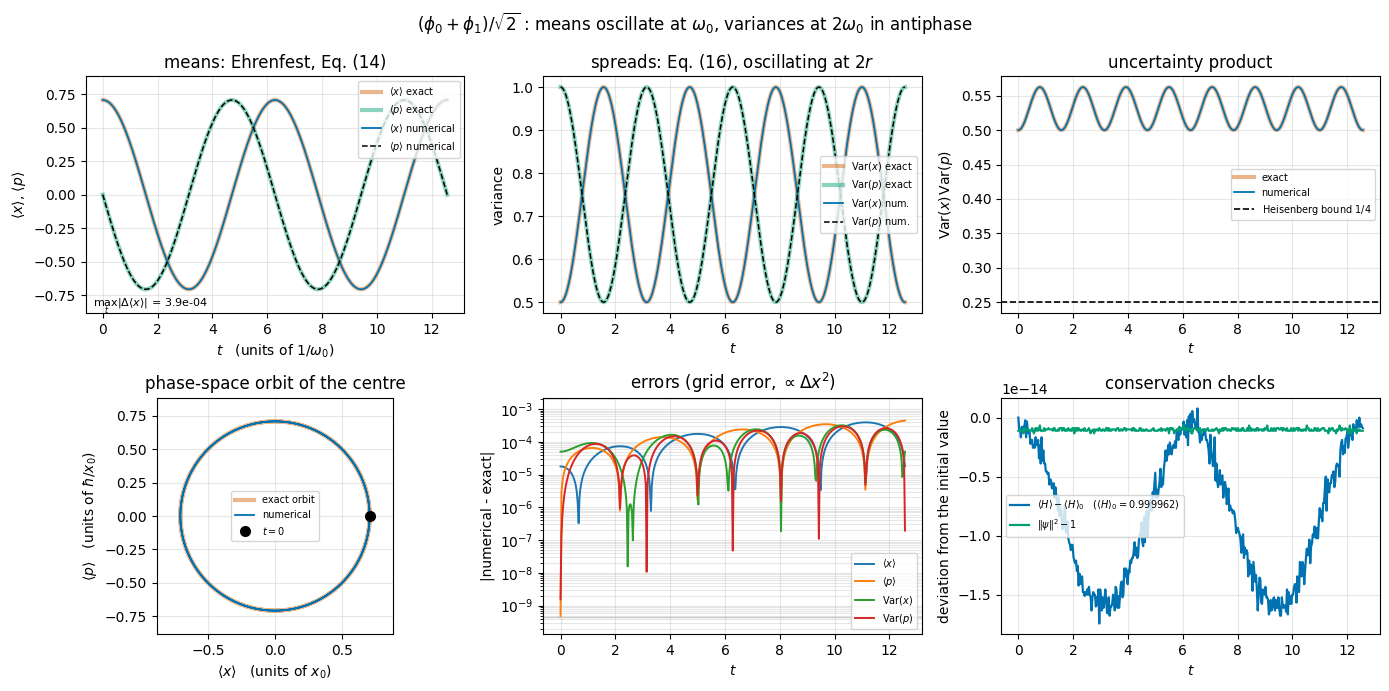

maximal |numerical - analytic| over two periods:
   <x>      3.923e-04
   <p>      4.443e-04
   Var(x)   3.189e-04
   Var(p)   2.976e-04
uncertainty product: min 0.49995, max 0.56248   (exact: 1/2 and 1/2 + 1/16 = 0.56250)
energy: 0.999962 .. 0.999962   (exact 1)
checkpoints passed: Ehrenfest, both variances, and the uncertainty product all reproduced


In [19]:
# ==============================================================================
# STEP 17: the superposition (phi_0 + phi_1)/sqrt(2) -- all four moments
# ==============================================================================
analytic_sup = dict(x=np.cos(t_sup) / np.sqrt(2.0),
                    p=-np.sin(t_sup) / np.sqrt(2.0),
                    vx=1.0 - 0.5 * np.cos(t_sup)**2,
                    vp=1.0 - 0.5 * np.sin(t_sup)**2)
res_sup = moment_panels(t_sup, psi_sup_t, x_stat, dx_stat, analytic_sup, freq_ratio=1.0,
                        title=r"$(\phi_0+\phi_1)/\sqrt{2}$ : means oscillate at $\omega_0$, "
                              r"variances at $2\omega_0$ in antiphase")

print("maximal |numerical - analytic| over two periods:")
for key, label in [("x", "<x>"), ("p", "<p>"), ("vx", "Var(x)"), ("vp", "Var(p)")]:
    print(f"   {label:8s} {res_sup['max_err'][key]:.3e}")
prod = res_sup["vx"] * res_sup["vp"]
print(f"uncertainty product: min {prod.min():.5f}, max {prod.max():.5f}   "
      f"(exact: 1/2 and 1/2 + 1/16 = {0.5 + 1/16:.5f})")
print(f"energy: {res_sup['energy'].min():.6f} .. {res_sup['energy'].max():.6f}   (exact 1)")

for key in ("x", "p", "vx", "vp"):
    assert res_sup["max_err"][key] < 5e-3, f"{key} does not follow the analytic law"
assert prod.min() > 0.25, "the uncertainty product must stay above the Heisenberg bound"
assert abs(prod.min() - 0.5) < 5e-3 and abs(prod.max() - 0.5625) < 5e-3
print("checkpoints passed: Ehrenfest, both variances, and the uncertainty product all reproduced")

Panel by panel: $\langle p\rangle$ is exactly the time derivative of $\langle x\rangle$ (Ehrenfest); the two
variances breathe at $2\omega_0$ in perfect antiphase; the uncertainty product stays between $0.5$ and $0.5625$,
i.e. **two to two-and-a-quarter times** the Heisenberg minimum $\tfrac14$; the phase-space orbit $(\langle x\rangle, \langle p\rangle)$ is a circle of
radius $1/\sqrt2$ traversed once per period — the classical orbit of a unit-mass unit-frequency oscillator; the
error panel shows all four errors at the $10^{-4}$ level and *growing linearly in time*, which is the signature of
the phase error we are about to dissect; and energy and norm are flat lines.

### 11.3 Where the remaining $10^{-4}$ comes from

The agreement with Eq. (18) is *not* perfect, and it is worth understanding why, because the explanation is a
template for reading every error in this field. The numerical Bohr frequency is $E_1 - E_0$, and by Eq. (10) it is
not exactly $1$ but

$$ (E_1 - E_0)^{\rm num} - 1 \;=\; \Delta E_1 - \Delta E_0 \;=\; -\frac{\Delta x^2}{32}\left(5 - 1\right)
   \;=\; -\frac{\Delta x^2}{8}. $$

A frequency error $\delta\omega$ turns into a *growing* phase error $\delta\omega\,t$, so the deviation in
$\langle x\rangle$ after a time $t$ is about $\tfrac{1}{\sqrt2}\,\delta\omega\,t$. It should therefore (i) grow
linearly in $t$ and (ii) shrink as $\Delta x^2$. Let us check both.

   N_x       dx   max|<x>-exact|   predicted (dx^2/8)*t_max/sqrt2


   251   0.0800        6.283e-03                        7.109e-03
   501   0.0400        1.570e-03                        1.777e-03


  1001   0.0200        3.923e-04                        4.443e-04


  2001   0.0100        9.808e-05                        1.111e-04


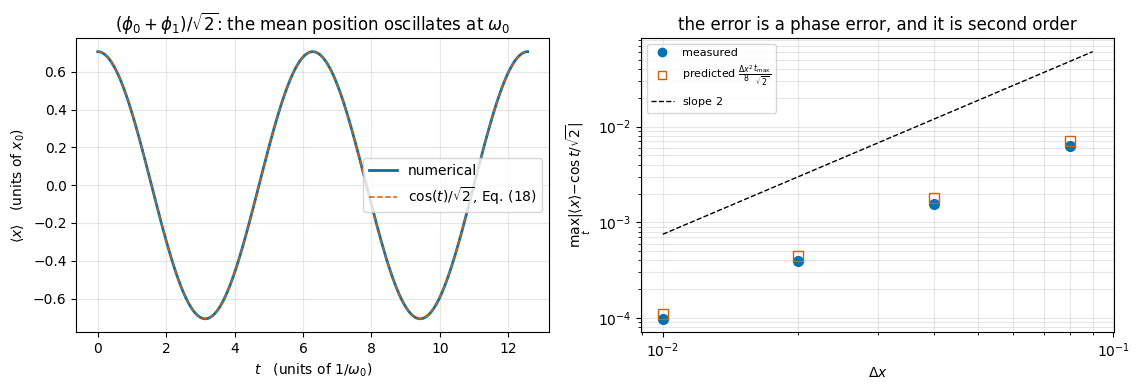

In [20]:
# ==============================================================================
# STEP 18: the error in <x>(t) is a phase error -- linear in t, quadratic in dx
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))

axes[0].plot(t_sup, x_mean_num, color=C_NUM, lw=2.0, label="numerical")
axes[0].plot(t_sup, x_mean_exact, color=C_EXACT, lw=1.1, ls="--", label=r"$\cos(t)/\sqrt{2}$, Eq. (18)")
axes[0].set_xlabel(r"$t$   (units of $1/\omega_0$)"); axes[0].set_ylabel(r"$\langle x\rangle$   (units of $x_0$)")
axes[0].set_title(r"$(\phi_0+\phi_1)/\sqrt{2}$: the mean position oscillates at $\omega_0$")
axes[0].legend(); axes[0].grid(alpha=.3)

print(f"{'N_x':>6s} {'dx':>8s} {'max|<x>-exact|':>16s} {'predicted (dx^2/8)*t_max/sqrt2':>32s}")
for N_x in [251, 501, 1001, 2001]:
    x_c, dx_c = make_grid(L_STAT, N_x)
    E_c, phi_c = solve_eigenstates(x_c, dx_c, 4)
    psi_c = ((phi_c[0] + phi_c[1]) / np.sqrt(2.0)).astype(CDTYPE)
    psi_ct = spectral_evolve(E_c, phi_c, spectral_coefficients(phi_c, psi_c, dx_c), t_sup)
    err_max = np.max(np.abs(grid_expect(psi_ct, x_c, dx_c) - x_mean_exact))
    pred = dx_c**2 / 8.0 * t_sup[-1] / np.sqrt(2.0)
    print(f"{N_x:6d} {dx_c:8.4f} {err_max:16.3e} {pred:32.3e}")
    axes[1].loglog(dx_c, err_max, "o", color=C_NUM, ms=7)
    axes[1].loglog(dx_c, pred, "s", color=C_EXACT, ms=7, mfc="none")

axes[1].loglog([], [], "o", color=C_NUM, label="measured")
axes[1].loglog([], [], "s", color=C_EXACT, mfc="none", label=r"predicted $\frac{\Delta x^2}{8}\frac{t_{\max}}{\sqrt{2}}$")
dxs = np.array([0.01, 0.09])
axes[1].loglog(dxs, 3e-3 * (dxs / 0.02)**2, "k--", lw=1, label=r"slope $2$")
axes[1].set_xlabel(r"$\Delta x$"); axes[1].set_ylabel(r"$\max_t\vert\langle x\rangle-\cos t/\sqrt{2}\vert$")
axes[1].set_title("the error is a phase error, and it is second order")
axes[1].legend(fontsize=8); axes[1].grid(which="both", alpha=.3)
fig.tight_layout(); plt.show()

Measured and predicted both fall with slope $2$, and their ratio is $0.88$ on every grid. The deviation is
$\tfrac{1}{\sqrt2}\,\delta\omega\,t\,\vert\sin t\vert$, and the maximum of $t\,\vert\sin t\vert$ on $[0, 4\pi]$ is
$11.04$ (at $t \approx 11.1$) rather than the $4\pi$ used in the prediction: $11.04/4\pi = 0.88$. The error is now
*explained*.

### 11.4 A coherent state: the most classical quantum state

Displace the ground state by $x_d$ without giving it momentum:

$$ \psi(x, 0) \;=\; \pi^{-1/4}\,e^{-(x-x_d)^2/2} . $$

This is a **coherent state**. Everything about it follows from Section 10 without any new work. The initial
moments are $\langle x\rangle_0 = x_d$, $\langle p\rangle_0 = 0$ (the wave function is real), and
$V_x(0) = V_p(0) = \tfrac12$ (a displaced Gaussian has the same spreads as the ground state). Substituting into
Eqs. (14) and (16) with $r=1$:

$$ \langle x\rangle(t) = x_d\cos t, \qquad \langle p\rangle(t) = -x_d\sin t, \qquad
   \mathrm{Var}(x)(t) = \tfrac12, \qquad \mathrm{Var}(p)(t) = \tfrac12 . $$

Three remarkable facts, all of which we check numerically:

* its centre follows the *classical* trajectory exactly, and in phase space $(\langle x\rangle,\langle p\rangle)$
  traces the classical circle of radius $x_d$;
* its shape does **not** change: $\sigma(t) = \sqrt{V_x} = 1/\sqrt2$ for all $t$. Equation (16) explains why in one
  line: with $r=1$ it reduces to $V_x(t) = V_x(0)\cos^2 t + V_p(0)\sin^2 t$, which is constant precisely when
  $V_x(0) = V_p(0)$: the spreading caused by the kinetic term is exactly balanced by the focusing of the trap. Every
  eigenstate, displaced or not, has the same property; the displaced Gaussian is the one among them that also
  saturates the Heisenberg bound. (A free Gaussian packet, as in notebook 00a, spreads without limit.)
* $\mathrm{Var}(x)\,\mathrm{Var}(p) = \tfrac14$ at **all** times: the coherent state is a *minimum-uncertainty*
  state, the closest a quantum state comes to being a classical point in phase space.

Its energy is $\langle H\rangle = \tfrac12 + \tfrac12 x_d^2$: zero-point energy plus the classical energy of an
oscillation of amplitude $x_d$.

sum_j |psi_j|^2 dx of the initial coherent state: 1.000000000000
population of the 40 kept eigenstates: 1.000000000000  (1 means the basis is big enough)


the |c_n|^2 are a Poisson distribution with mean x_d^2/2 = 2.00:  0.1353 0.2707 0.2706 0.1804 0.0902 0.0361 0.0120


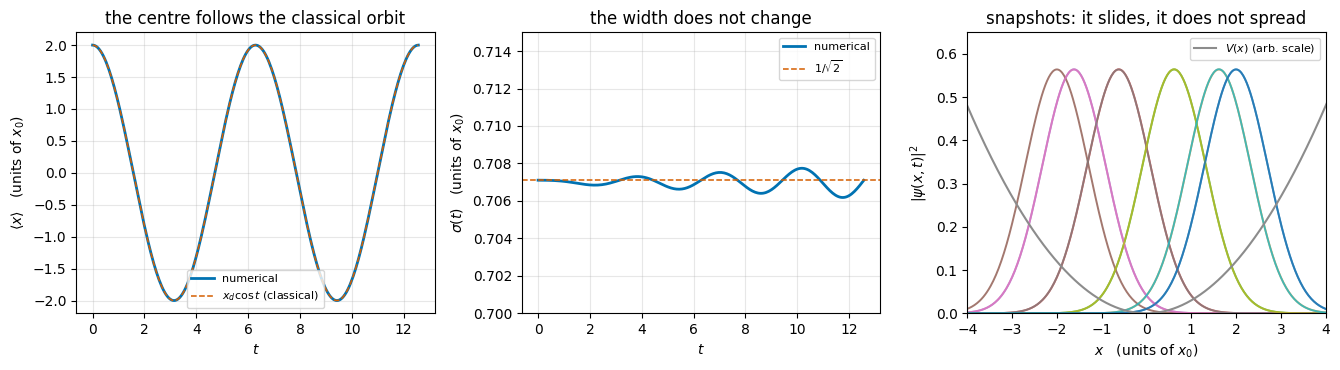


max |<x>(t) - x_d cos t|        = 3.336e-03
sigma(t): min 0.706185, max 0.707743, exact 0.707107
<H> = 2.499988,  exact 1/2 + x_d^2/2 = 2.500000
checkpoints passed: classical orbit, constant width, correct energy


In [21]:
# ==============================================================================
# STEP 19: a displaced ground state (coherent state) oscillates without spreading
# ==============================================================================
X_DISPLACE = 2.0
psi_coh0 = (np.pi**-0.25 * np.exp(-(x_stat - X_DISPLACE)**2 / 2.0)).astype(CDTYPE)
print(f"sum_j |psi_j|^2 dx of the initial coherent state: {grid_norm(psi_coh0, dx_stat):.12f}")

c_coh = spectral_coefficients(phi_stat, psi_coh0, dx_stat)
print(f"population of the {N_STATES} kept eigenstates: {np.sum(np.abs(c_coh)**2):.12f}  "
      f"(1 means the basis is big enough)")
print("the |c_n|^2 are a Poisson distribution with mean x_d^2/2 = "
      f"{X_DISPLACE**2/2:.2f}:  " + " ".join(f"{abs(c_coh[n])**2:.4f}" for n in range(7)))

t_coh = np.linspace(0.0, 4.0 * np.pi, 241)
psi_coh_t = spectral_evolve(E_stat, phi_stat, c_coh, t_coh)
x_coh = grid_expect(psi_coh_t, x_stat, dx_stat)
sig_coh = grid_sigma(psi_coh_t, x_stat, dx_stat)
E_coh = grid_energy(psi_coh0, x_stat, dx_stat)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
axes[0].plot(t_coh, x_coh, color=C_NUM, lw=2.0, label="numerical")
axes[0].plot(t_coh, X_DISPLACE * np.cos(t_coh), color=C_EXACT, lw=1.1, ls="--",
             label=r"$x_d\cos t$ (classical)")
axes[0].set_xlabel(r"$t$"); axes[0].set_ylabel(r"$\langle x\rangle$   (units of $x_0$)")
axes[0].set_title("the centre follows the classical orbit"); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

axes[1].plot(t_coh, sig_coh, color=C_NUM, lw=2.0, label="numerical")
axes[1].axhline(1 / np.sqrt(2), color=C_EXACT, lw=1.1, ls="--", label=r"$1/\sqrt{2}$")
axes[1].set_ylim(0.70, 0.715)
axes[1].set_xlabel(r"$t$"); axes[1].set_ylabel(r"$\sigma(t)$   (units of $x_0$)")
axes[1].set_title("the width does not change"); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)

for k in range(0, 121, 12):                              # one full period, 11 evenly spaced snapshots
    axes[2].plot(x_stat, np.abs(psi_coh_t[k])**2, lw=1.4, alpha=.8)
axes[2].plot(x_stat, 0.06 * 0.5 * x_stat**2, color=C_POT, lw=1.5, label=r"$V(x)$ (arb. scale)")
axes[2].set_xlim(-4, 4); axes[2].set_ylim(0, 0.65)
axes[2].set_xlabel(r"$x$   (units of $x_0$)"); axes[2].set_ylabel(r"$\vert\psi(x,t)\vert^2$")
axes[2].set_title("snapshots: it slides, it does not spread"); axes[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"\nmax |<x>(t) - x_d cos t|        = {np.max(np.abs(x_coh - X_DISPLACE*np.cos(t_coh))):.3e}")
print(f"sigma(t): min {sig_coh.min():.6f}, max {sig_coh.max():.6f}, exact {1/np.sqrt(2):.6f}")
print(f"<H> = {E_coh:.6f},  exact 1/2 + x_d^2/2 = {0.5 + 0.5*X_DISPLACE**2:.6f}")
assert np.max(np.abs(x_coh - X_DISPLACE * np.cos(t_coh))) < 5e-3
assert np.max(np.abs(sig_coh - 1 / np.sqrt(2))) < 5e-3
assert abs(E_coh - (0.5 + 0.5 * X_DISPLACE**2)) < 1e-3
print("checkpoints passed: classical orbit, constant width, correct energy")

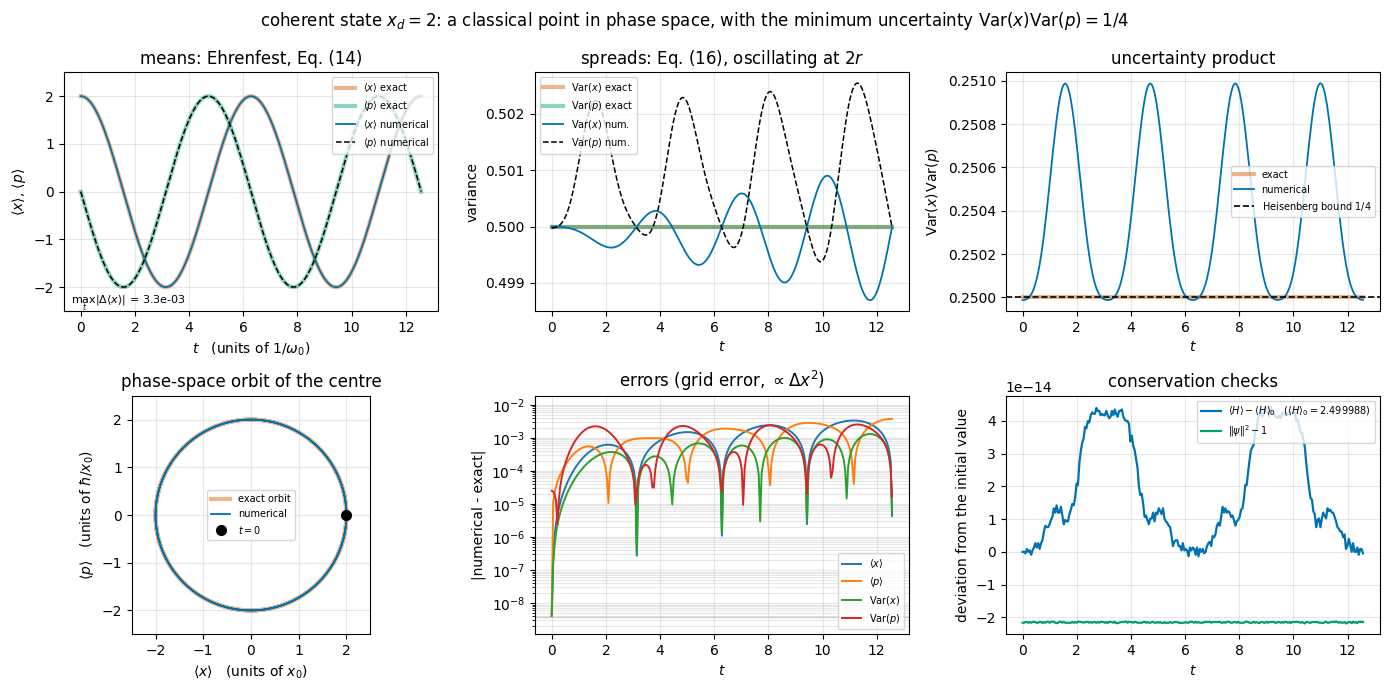

maximal |numerical - analytic|:
   <x>      3.336e-03
   <p>      3.771e-03
   Var(x)   1.303e-03
   Var(p)   2.538e-03


uncertainty product: min 0.249988, max 0.250988   (exact 1/4 = 0.250000)
energy: 2.499988 .. 2.499988   (exact 2.500000)
checkpoints passed: classical circle in phase space, constant variances, minimum uncertainty


In [22]:
# ==============================================================================
# STEP 20: the coherent state -- all four moments and the minimum-uncertainty property
# ==============================================================================
analytic_coh = dict(x=X_DISPLACE * np.cos(t_coh),
                    p=-X_DISPLACE * np.sin(t_coh),
                    vx=np.full_like(t_coh, 0.5),
                    vp=np.full_like(t_coh, 0.5))
res_coh = moment_panels(t_coh, psi_coh_t, x_stat, dx_stat, analytic_coh, freq_ratio=1.0,
                        title=r"coherent state $x_d=2$: a classical point in phase space, "
                              r"with the minimum uncertainty $\mathrm{Var}(x)\mathrm{Var}(p)=1/4$")

print("maximal |numerical - analytic|:")
for key, label in [("x", "<x>"), ("p", "<p>"), ("vx", "Var(x)"), ("vp", "Var(p)")]:
    print(f"   {label:8s} {res_coh['max_err'][key]:.3e}")
prod_coh = res_coh["vx"] * res_coh["vp"]
print(f"uncertainty product: min {prod_coh.min():.6f}, max {prod_coh.max():.6f}   (exact 1/4 = 0.250000)")
print(f"energy: {res_coh['energy'].min():.6f} .. {res_coh['energy'].max():.6f}   "
      f"(exact {0.5 + 0.5*X_DISPLACE**2:.6f})")

for key in ("x", "p", "vx", "vp"):
    assert res_coh["max_err"][key] < 1e-2, f"{key} does not follow the analytic law"
assert np.max(np.abs(prod_coh - 0.25)) < 1e-2
print("checkpoints passed: classical circle in phase space, constant variances, minimum uncertainty")

The populations $\vert c_n\vert^2$ printed above are a Poisson distribution with mean
$\bar n = x_d^2/2 = 2$ — the defining property of a coherent state, and the reason a laser beam (a coherent state
of light) has Poissonian photon statistics.

The phase-space panel is worth a second look. A classical oscillator is a *point* going round a circle of radius
$x_d$; the coherent state is that same point surrounded by an irreducible fuzz,
$\sigma_x = \sigma_p = 1/\sqrt2$, that never grows and never changes shape. That picture — a rigid disc sliding around
the classical orbit — is the standard mental image of a coherent state, and it came out of a tridiagonal
matrix.

## 12. Quenching the trap frequency: four integrators

### 12.1 The protocol and the physics

We now do something the analytic textbook treatment rarely does explicitly, and that is the bread and butter of
modern cold-atom experiments: a **quench**. Prepare the ground state of a trap of frequency $\omega_0$, then at
$t=0$ *suddenly* change the trap frequency to $\omega_1 = r\,\omega_0$. The wave function has no time to react, so

$$ \psi(x, 0^{+}) = \psi(x, 0^{-}) = \phi_0^{(\omega_0)}(x) = \pi^{-1/4}e^{-x^2/2}, $$

but this Gaussian is *not* the ground state of the new trap (whose ground state has width $1/\sqrt{2r}$). The state
is too wide for $r>1$, so it contracts; then it overshoots, expands, and so on: the **breathing mode**.

By symmetry nothing moves: the initial state is even and the new potential is even, so $\langle x\rangle(t)=0$ for
all $t$. The interesting observable is the width $\sigma^2(t) = \langle x^2\rangle(t)$.

### 12.2 The exact moments after the quench, and a squeezed state

All the work was done in Section 10; we only have to insert the initial conditions. The state at $t=0^{+}$ is the
ground state of the *old* trap, so

$$ \langle x\rangle_0 = \langle p\rangle_0 = 0, \qquad V_x(0) = V_p(0) = \tfrac12, \qquad C(0) = 0 , $$

and it evolves in the *new* trap, i.e. with $r = \omega_1/\omega_0 \ne 1$ in Eqs. (14) and (16).

**The means.** Equation (14) gives $\langle x\rangle(t) = \langle p\rangle(t) = 0$ for all $t$: nothing moves,
exactly as parity demands (an even initial state in an even potential). Any non-zero $\langle x\rangle$ in the
numerics is pure discretisation noise — a very clean bug detector.

**The spreads.** Equation (16) with $V_x(0)=V_p(0)=\tfrac12$ gives directly

$$ \boxed{\;\mathrm{Var}(x)(t) \;=\; \frac{1}{2}\left[\cos^2(rt) + \frac{\sin^2(rt)}{r^2}\right]\;} \tag{19} $$

$$ \boxed{\;\mathrm{Var}(p)(t) \;=\; \frac{1}{2}\left[\cos^2(rt) + r^2\sin^2(rt)\right]\;} \tag{20} $$

Using $\cos^2\theta = \tfrac12(1+\cos2\theta)$, Eq. (19) can also be written in the equivalent "breathing" form

$$ \sigma^2(t) \equiv \mathrm{Var}(x)(t) = \frac{(1+r^2) \;+\; (r^2-1)\cos(2 r t)}{4r^2}, $$

which is the form to read the physics off:

* the widths **breathe at $2r$**, i.e. at $2\omega_1$ in SI units — *twice* the new trap frequency, because the
  width returns to itself every half period of the motion, and $\mathrm{Var}(x)$ and $\mathrm{Var}(p)$ do it in
  antiphase;
* $\sigma^2$ swings between $\tfrac12$ (the initial value, at $rt = 0, \pi, 2\pi,\dots$) and $1/(2r^2)$ (the
  ground-state width of the *new* trap, at $rt = \pi/2, 3\pi/2,\dots$), while $\mathrm{Var}(p)$ swings between
  $\tfrac12$ and $r^2/2$;
* for $r=1$ (no quench) both reduce to the constant $\tfrac12$, as they must;
* the energy after the quench is
  $\langle H\rangle = \tfrac12\langle p^2\rangle + \tfrac12 r^2\langle x^2\rangle = (1+r^2)/4$, i.e.
  $\hbar(\omega_0^2+\omega_1^2)/(4\omega_0)$ in SI units — more than the new ground-state energy $r/2$ whenever
  $r \ne 1$. The difference is the energy the quench injected.

**Squeezing.** Multiply Eqs. (19) and (20). With $s = \sin^2(rt)$, $c = \cos^2(rt)$, $s + c = 1$:

$$ \mathrm{Var}(x)\,\mathrm{Var}(p)
   = \frac{1}{4}\left[c^2 + s^2 + sc\left(r^2 + \frac{1}{r^2}\right)\right]
   = \frac{1}{4}\left[1 + sc\left(r - \frac{1}{r}\right)^{2}\right]
   = \frac{1}{4}\left[1 + \frac{\sin^2(2rt)}{4}\left(r - \frac{1}{r}\right)^{2}\right] . \tag{21} $$

This is $\ge \tfrac14$, as Heisenberg requires, and it **touches $\tfrac14$ exactly at the turning points of the
breathing**, $\sin(2rt) = 0$. At those instants the state is a minimum-uncertainty Gaussian. At $rt = \pi/2,
3\pi/2, \dots$ its $\mathrm{Var}(x) = 1/(2r^2)$ is, for $r>1$, *narrower in position than the ground state of the
new trap* (whose variance is $1/(2r)$), at the price of being correspondingly broader in momentum; at
$rt = \pi, 2\pi, \dots$ it is the initial Gaussian, too narrow in momentum for the new trap. A minimum-uncertainty
state with unequal, rescaled variances is exactly what is called a **squeezed state**. Modulating a trap frequency
(the sudden quench, followed by a quarter of the new trap period, is its simplest form) is how squeezed motional
states of trapped ions are prepared, and its optical analogue, parametric amplification, produces the squeezed
light that lowers the quantum noise of LIGO below the shot-noise level.

### 12.3 The plan

We solve the same problem four ways and compare them; the fourth, Crank–Nicolson, is added in Section 12.11 once the
step limit of RK4 has been derived:

| method | idea | cost | time-step error |
|---|---|---|---|
| (a) spectral | diagonalise $H_1$, use Eq. (17) | $O(N_x^3)$ once, then $O(N_x^2)$ per snapshot | none |
| (b) propagator | build $U = e^{-iH_1\Delta t}$ once, apply repeatedly | $O(N_x^3)$ once, then $O(N_x^2)$ per step | none |
| (c) RK4 | integrate $\dot\psi = -iH_1\psi$ step by step | $O(N_x)$ per step, no matrix at all | $O(\Delta t^4)$ |
| (d) Crank–Nicolson | implicit trapezoidal rule, one tridiagonal solve per step (Section 12.11) | $O(N_x)$ per step | $O(\Delta t^2)$, but no stability limit |

Methods (a) and (b) are *exact in time* but need a dense linear-algebra operation whose cost explodes with $N_x$;
(c) is approximate in time but never builds a matrix. In one dimension all three are affordable, and (a) is the fastest. In the many-body
problems of later chapters $N_x$ is replaced by $2^N$, and building a matrix becomes impossible — then (c), the
**matrix-free** route, is the only one left. That is why we practise it here, where we can check it against an
exact answer.

In [23]:
# ==============================================================================
# PARAMETERS of the quench experiment  -- change these and rerun
# ==============================================================================
R_QUENCH = 2.0                      # r = omega_1 / omega_0 : the trap is suddenly made twice as stiff
L_DYN    = 16.0                     # box for the dynamics (the state is narrow, so a smaller box suffices)
NX_DYN   = 641                      # grid points  ->  dx = 0.025
N_SNAP   = 60                       # snapshots stored for plots and animations
T_BREATH = np.pi / R_QUENCH         # breathing period pi/r from Eq. (19)
T_FINAL  = 3.0 * T_BREATH           # simulate three breathing periods

x_dyn, dx_dyn = make_grid(L_DYN, NX_DYN)
V_dyn = harmonic_potential(x_dyn, R_QUENCH)
t_snap = np.linspace(0.0, T_FINAL, N_SNAP + 1)

# the initial state: ground state of the OLD trap (r = 1), analytically a unit-width Gaussian
psi_quench0 = (np.pi**-0.25 * np.exp(-x_dyn**2 / 2.0)).astype(CDTYPE)
psi_quench0 /= np.sqrt(grid_norm(psi_quench0, dx_dyn))      # remove the O(1e-16) grid truncation

def sigma2_exact(t, r):
    """Eq. (19):  Var(x)(t) = (1/2)[cos^2(r t) + sin^2(r t)/r^2]   after the quench from the ground state.
    (Equivalently ((1+r^2) + (r^2-1) cos(2 r t)) / (4 r^2) -- the two forms are identical.)"""
    t = np.asarray(t)
    return 0.5 * (np.cos(r * t)**2 + np.sin(r * t)**2 / r**2)


def varp_exact(t, r):
    """Eq. (20):  Var(p)(t) = (1/2)[cos^2(r t) + r^2 sin^2(r t)]."""
    t = np.asarray(t)
    return 0.5 * (np.cos(r * t)**2 + r**2 * np.sin(r * t)**2)


# the two forms of Eq. (19) must agree -- a one-line check of the algebra above
_t_chk = np.linspace(0.0, 10.0, 97)
_alt = ((1.0 + R_QUENCH**2) + (R_QUENCH**2 - 1.0) * np.cos(2.0 * R_QUENCH * _t_chk)) / (4.0 * R_QUENCH**2)
assert np.max(np.abs(sigma2_exact(_t_chk, R_QUENCH) - _alt)) < 1e-14

print(f"r = omega_1/omega_0 = {R_QUENCH}")
print(f"grid: L = {L_DYN}, N_x = {NX_DYN}, dx = {dx_dyn:.4f}")
print(f"breathing period pi/r = {T_BREATH:.4f} (in units of 1/omega_0); simulating to t = {T_FINAL:.4f}")
print(f"Var(x) should swing between 1/(2r^2) = {1/(2*R_QUENCH**2):.4f} and 1/2 = 0.5")
print(f"Var(p) should swing between 1/2 = 0.5 and r^2/2 = {R_QUENCH**2/2:.4f}  (in antiphase)")
print(f"uncertainty product between 1/4 = 0.25 and "
      f"{0.25*(1 + 0.25*(R_QUENCH - 1/R_QUENCH)**2):.4f}  [Eq. (21)]")
print(f"energy after the quench: (1+r^2)/4 = {(1+R_QUENCH**2)/4:.4f} "
      f"(new ground state: r/2 = {R_QUENCH/2:.4f})")
print(f"initial norm: {grid_norm(psi_quench0, dx_dyn):.14f}")

r = omega_1/omega_0 = 2.0
grid: L = 16.0, N_x = 641, dx = 0.0250
breathing period pi/r = 1.5708 (in units of 1/omega_0); simulating to t = 4.7124
Var(x) should swing between 1/(2r^2) = 0.1250 and 1/2 = 0.5
Var(p) should swing between 1/2 = 0.5 and r^2/2 = 2.0000  (in antiphase)
uncertainty product between 1/4 = 0.25 and 0.3906  [Eq. (21)]
energy after the quench: (1+r^2)/4 = 1.2500 (new ground state: r/2 = 1.0000)
initial norm: 1.00000000000000


### 12.4 Method (a): spectral decomposition in the new eigenbasis

We need the **whole** spectrum of the new Hamiltonian this time, because we want an exact reference: any state
truncated to a few levels would introduce an error of its own. `eigh_tridiagonal` without `select` gives all $N_x$
eigenpairs.

In [24]:
# ==============================================================================
# METHOD (a): full diagonalisation of H_1 and exact spectral evolution
# ==============================================================================
t_start = time.time()
diag_dyn, off_dyn = hamiltonian_tridiagonal(x_dyn, dx_dyn, R_QUENCH)
E_dyn, V_dyn_vecs = eigh_tridiagonal(diag_dyn, off_dyn)     # ALL N_x eigenpairs
phi_dyn = (V_dyn_vecs.T / np.sqrt(dx_dyn)).astype(RDTYPE)
time_diag = time.time() - t_start

c_dyn = spectral_coefficients(phi_dyn, psi_quench0, dx_dyn)
t_start = time.time()
psi_spectral = spectral_evolve(E_dyn, phi_dyn, c_dyn, t_snap)
time_spectral = time.time() - t_start

print(f"full diagonalisation of a {NX_DYN}x{NX_DYN} tridiagonal matrix: {time_diag:.2f} s")
print(f"{N_SNAP + 1} snapshots by Eq. (17):                 {time_spectral:.2f} s")
print(f"E_n of the new trap, n = 0..4: {np.array2string(E_dyn[:5], precision=5)}   "
      f"(exact r(n+1/2) = {np.array2string(R_QUENCH*(np.arange(5)+0.5), precision=5)})")
print(f"largest eigenvalue E_max = {E_dyn[-1]:.1f}  (between 2/dx^2 = {2/dx_dyn**2:.1f} and 2/dx^2 + V_max = "
      f"{2/dx_dyn**2 + np.max(V_dyn):.1f}; Section 12.7 uses it)")
print(f"sum_n |c_n|^2 = {np.sum(np.abs(c_dyn)**2):.14f}   (completeness of the eigenbasis)")

sigma2_spectral = grid_expect(psi_spectral, x_dyn**2, dx_dyn) - grid_expect(psi_spectral, x_dyn, dx_dyn)**2
E_after = np.sum(np.abs(c_dyn)**2 * E_dyn)
print(f"\n<H_1> after the quench = {E_after:.8f}   exact (1+r^2)/4 = {(1+R_QUENCH**2)/4:.8f}")
print(f"max |<x>(t)| = {np.max(np.abs(grid_expect(psi_spectral, x_dyn, dx_dyn))):.3e}  (parity: should be 0)")
print(f"max |sigma^2_num(t) - Eq.(19)| = {np.max(np.abs(sigma2_spectral - sigma2_exact(t_snap, R_QUENCH))):.3e}")

assert abs(E_after - (1 + R_QUENCH**2) / 4) < 2e-3
assert np.max(np.abs(sigma2_spectral - sigma2_exact(t_snap, R_QUENCH))) < 3e-3
print("checkpoints passed: injected energy and the breathing law of Eq. (19) both reproduced")

full diagonalisation of a 641x641 tridiagonal matrix: 0.26 s
61 snapshots by Eq. (17):                 0.26 s
E_n of the new trap, n = 0..4: [0.99992 2.99961 4.99898 6.99805 8.9968 ]   (exact r(n+1/2) = [1. 3. 5. 7. 9.])
largest eigenvalue E_max = 3310.4  (between 2/dx^2 = 3200.0 and 2/dx^2 + V_max = 3328.0; Section 12.7 uses it)
sum_n |c_n|^2 = 1.00000000000000   (completeness of the eigenbasis)



<H_1> after the quench = 1.24998047   exact (1+r^2)/4 = 1.25000000
max |<x>(t)| = 5.196e-15  (parity: should be 0)
max |sigma^2_num(t) - Eq.(19)| = 1.007e-03
checkpoints passed: injected energy and the breathing law of Eq. (19) both reproduced


### 12.5 Method (b): the propagator $U(\Delta t) = e^{-iH\Delta t}$

The formal solution of the TDSE for a time-independent $H$ is $\psi(t) = e^{-iHt}\psi(0)$. If we only ever advance
by the *same* step $\Delta t$, we can build the matrix

$$ U(\Delta t) = e^{-iH\Delta t} $$

**once** (with `scipy.linalg.expm`, which uses a scaling-and-squaring Padé algorithm) and then apply it over and
over: $\psi_{k+1} = U\psi_k$. Because $U$ is exactly unitary (up to round-off), this conserves the norm exactly and
has **no time-step error at all** — $U(\Delta t)$ is the exact propagator, not an approximation to it. The price is
a dense $N_x \times N_x$ matrix: $O(N_x^3)$ to build, $O(N_x^2)$ memory, $O(N_x^2)$ per step.

In [25]:
# ==============================================================================
# METHOD (b): build the propagator once, apply it repeatedly
# ==============================================================================
N_SUBSTEPS = 8                                        # propagator steps between two stored snapshots
dt_prop = (t_snap[1] - t_snap[0]) / N_SUBSTEPS

H_dense_dyn = hamiltonian_dense(x_dyn, dx_dyn, R_QUENCH)
t_start = time.time()
U_dt = expm(-1j * dt_prop * H_dense_dyn).astype(CDTYPE)
time_build_U = time.time() - t_start

# CHECKPOINT: U must be unitary
unitarity = np.max(np.abs(U_dt.conj().T @ U_dt - np.eye(NX_DYN)))
print(f"expm of a {NX_DYN}x{NX_DYN} matrix: {time_build_U:.2f} s   (dt = {dt_prop:.5f})")
print(f"max |U^dagger U - 1| = {unitarity:.3e}")
assert unitarity < 1e-10

t_start = time.time()
psi_prop = np.zeros((N_SNAP + 1, NX_DYN), dtype=CDTYPE)
psi_prop[0] = psi_quench0
psi_run = psi_quench0.copy()
for k in range(N_SNAP):
    for _ in range(N_SUBSTEPS):
        psi_run = U_dt @ psi_run                      # one matrix-vector product per step
    psi_prop[k + 1] = psi_run
time_prop = time.time() - t_start

print(f"{N_SNAP * N_SUBSTEPS} propagator steps: {time_prop:.2f} s")
print(f"norm at the end:                 {grid_norm(psi_prop[-1], dx_dyn):.14f}")
print(f"max |psi_prop - psi_spectral|:   {np.max(np.abs(psi_prop - psi_spectral)):.3e}")
assert np.max(np.abs(psi_prop - psi_spectral)) < 1e-10
print("checkpoint passed: (a) and (b) agree to machine precision -- both are exact in time")

expm of a 641x641 matrix: 3.60 s   (dt = 0.00982)
max |U^dagger U - 1| = 3.109e-15


480 propagator steps: 1.15 s
norm at the end:                 0.99999999999961
max |psi_prop - psi_spectral|:   1.108e-12
checkpoint passed: (a) and (b) agree to machine precision -- both are exact in time


### 12.6 Method (c): fourth-order Runge–Kutta, matrix-free

Now we forget that $H$ can be diagonalised or exponentiated, and simply integrate the differential equation

$$ \frac{d\psi}{dt} \;=\; f(\psi) \;=\; -\,i\,H\psi . $$

**The classical fourth-order Runge–Kutta scheme** (Press *et al.*, *Numerical Recipes*, §17.1). Given $\psi_k$ at
time $t_k$, evaluate the derivative four times:

$$ \begin{aligned}
   k_1 &= f(\psi_k), \\
   k_2 &= f\!\left(\psi_k + \tfrac{\Delta t}{2}k_1\right), \\
   k_3 &= f\!\left(\psi_k + \tfrac{\Delta t}{2}k_2\right), \\
   k_4 &= f\!\left(\psi_k + \Delta t\,k_3\right),
\end{aligned} $$

and combine them with Simpson-like weights:

$$ \psi_{k+1} \;=\; \psi_k \;+\; \frac{\Delta t}{6}\left(k_1 + 2k_2 + 2k_3 + k_4\right) . \tag{22} $$

The local error of one step is $O(\Delta t^5)$, so after $T/\Delta t$ steps the **global** error is
$O(\Delta t^4)$ — we will measure exactly that exponent.

**Matrix-free $H\psi$.** Nothing in Eq. (22) needs the matrix $H$; it only needs the *action* of $H$ on a vector.
That action is three array shifts, straight from Eq. (8):

$$ (H\psi)_j = -\frac{1}{2}\,\frac{\psi_{j+1} - 2\psi_j + \psi_{j-1}}{\Delta x^2} + V(x_j)\,\psi_j . $$

Cost: $O(N_x)$ operations and $O(N_x)$ memory, instead of $O(N_x^2)$ and $O(N_x^2)$. This is the single most
important idea of the whole course; here it saves a factor of $600$, and in Chapter 3 it will be the difference
between possible and impossible.

**Two JAX features.**

* `jax.jit` takes a Python function, traces it once into a single compiled program, and from then on runs that
  program instead of the Python code. For a time loop this removes the Python interpreter from the inner loop
  entirely.
* `lax.scan` is a compiled `for` loop: `lax.scan(step, init, xs, length=n)` applies `step` $n$ times, carrying the
  state forward, and (unlike a Python loop inside `jit`) compiles to a *loop* rather than to $n$ copies of the body,
  so compilation stays fast however many steps you take.

Both are explained properly in [01 — JAX](01_jax_from_scratch.ipynb); today, treat them as "a `for`
loop that the compiler sees".

In [26]:
# ==============================================================================
# METHOD (c): RK4 with a matrix-free Hamiltonian, time loop compiled with lax.scan
# ==============================================================================
def apply_H(psi, V, dx):
    """The ACTION of the discretised Hamiltonian on a state -- no matrix is ever built.

    MATH  (H psi)_j = -(1/2)(psi_{j+1} - 2 psi_j + psi_{j-1})/dx^2 + V_j psi_j     [Eq. (8)]
          with psi_{-1} = psi_{N_x} = 0 (Dirichlet walls).

    COST  O(N_x) time and O(N_x) memory   (the dense matrix would be O(N_x^2) of both).
    JAX   jnp.concatenate builds the two shifted copies; everything is a pure array expression,
          so jit/scan can compile the whole time loop into one program.
    """
    zero = jnp.zeros(1, dtype=psi.dtype)
    psi_plus = jnp.concatenate([psi[1:], zero])            # psi_{j+1}
    psi_minus = jnp.concatenate([zero, psi[:-1]])          # psi_{j-1}
    return -0.5 * (psi_plus - 2.0 * psi + psi_minus) / dx**2 + V * psi


def rk4_step(psi, V, dx, dt):
    """One step of Eq. (22) for dpsi/dt = -i H psi."""
    f = lambda p: -1j * apply_H(p, V, dx)
    k1 = f(psi)
    k2 = f(psi + 0.5 * dt * k1)
    k3 = f(psi + 0.5 * dt * k2)
    k4 = f(psi + dt * k3)
    return psi + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


@partial(jax.jit, static_argnames=("n_inner", "n_outer"))
def rk4_evolve(psi0, V, dx, dt, n_inner, n_outer):
    """n_outer * n_inner RK4 steps, storing the state after every n_inner of them.

    IMPLEMENTATION
        two nested lax.scan loops: the inner one advances n_inner steps and stores nothing,
        the outer one runs n_outer times and stores one snapshot each time.  This keeps the
        memory at n_outer * N_x instead of (n_inner*n_outer) * N_x.

    RETURNS (psi_final, snapshots) with snapshots of shape (n_outer, N_x)
    """
    def inner(psi, _):
        return rk4_step(psi, V, dx, dt), None

    def outer(psi, _):
        psi, _ = lax.scan(inner, psi, None, length=n_inner)
        return psi, psi                                     # carry, and store a snapshot

    return lax.scan(outer, psi0, None, length=n_outer)


# ---- run it ------------------------------------------------------------------------
E_MAX_DYN = float(E_dyn[-1])                               # largest eigenvalue of H_1 on this grid
DT_CRIT = 2.0 * np.sqrt(2.0) / E_MAX_DYN                   # RK4 stability limit, derived in Sec. 12.7
N_INNER = int(np.ceil((t_snap[1] - t_snap[0]) / (0.4 * DT_CRIT)))
dt_rk4 = (t_snap[1] - t_snap[0]) / N_INNER

psi0_j = jnp.asarray(psi_quench0, dtype=CDTYPE)
V_dyn_j = jnp.asarray(V_dyn, dtype=RDTYPE)

t_start = time.time()
psi_last, snaps = rk4_evolve(psi0_j, V_dyn_j, dx_dyn, dt_rk4, N_INNER, N_SNAP)
psi_last.block_until_ready()
time_rk4 = time.time() - t_start

psi_rk4 = np.concatenate([psi_quench0[None, :], np.asarray(snaps)], axis=0)

print(f"dt = {dt_rk4:.3e}  ({N_INNER} steps per snapshot, {N_INNER * N_SNAP} steps in total)")
print(f"RK4 (compile + run): {time_rk4:.2f} s")
print(f"norm at the end:                    {grid_norm(psi_rk4[-1], dx_dyn):.14f}")
print(f"max |psi_RK4 - psi_spectral|:       {np.max(np.abs(psi_rk4 - psi_spectral)):.3e}")
assert np.max(np.abs(psi_rk4 - psi_spectral)) < 1e-8
print("checkpoint passed: the hand-written matrix-free integrator agrees with the exact spectral solution")

dt = 3.415e-04  (230 steps per snapshot, 13800 steps in total)
RK4 (compile + run): 5.86 s
norm at the end:                    1.00000000000000
max |psi_RK4 - psi_spectral|:       9.464e-12
checkpoint passed: the hand-written matrix-free integrator agrees with the exact spectral solution


### 12.7 Why explicit Euler is hopeless, and where RK4's step limit comes from

Take first the simplest possible integrator, **explicit Euler**:

$$ \psi_{k+1} = \psi_k + \Delta t\,f(\psi_k) = \left(1 - i\Delta t\,H\right)\psi_k . $$

Expand $\psi_k$ in eigenstates of $H$. A component with energy $E$ is multiplied each step by the number
$1 - iE\Delta t$, whose modulus is

$$ \left\vert 1 - i E \Delta t\right\vert = \sqrt{1 + (E\Delta t)^2} \;>\; 1
   \qquad \text{for every } E \ne 0 \text{ and every } \Delta t > 0 . $$

**Every** mode grows, for **any** step size: explicit Euler is *unconditionally unstable* for the Schrödinger
equation. The fastest-growing mode is the one with the largest $E$, and on our grid $E_{\max}$ lies between the
purely kinetic $2/\Delta x^2$ (the top of the band of the discrete Laplacian, reached by the mode that alternates
sign from point to point) and the crude bound $2/\Delta x^2 + \max_j V(x_j)$ — on a fine grid the kinetic part
dominates, and either way $E_{\max}$ is enormous. So even a component present only at the $10^{-16}$ round-off
level takes over within a few hundred steps. Concretely, the norm should grow as

$$ \ln\lVert\psi_k\rVert \;\simeq\; \text{const} + \frac{k}{2}\,\ln\!\left(1 + (E_{\max}\Delta t)^2\right) . $$

**RK4 is different.** One step multiplies an eigen-component by
$R(z) = 1 + z + \tfrac{z^2}{2} + \tfrac{z^3}{6} + \tfrac{z^4}{24}$ with $z = -iE\Delta t$. Writing
$\theta = E\Delta t$ and expanding, the real and imaginary parts give

$$ \vert R\vert^2 = \left(1 - \tfrac{\theta^2}{2} + \tfrac{\theta^4}{24}\right)^2 + \left(\theta - \tfrac{\theta^3}{6}\right)^2
  = 1 - \frac{\theta^6}{72} + O(\theta^8), $$

so $\vert R\vert \simeq 1 - \theta^6/144$: slightly **less** than one. RK4 is *very slightly dissipative* on the
imaginary axis, which is exactly what we want — small errors decay instead of growing. It stays stable as long as
$\vert R(-i\theta)\vert \le 1$, which for this polynomial holds up to

$$ \theta = E\Delta t \;\le\; 2\sqrt{2} \approx 2.828
   \qquad\Longrightarrow\qquad
   \boxed{\;\Delta t \;\le\; \frac{2\sqrt2}{E_{\max}}\;} \tag{23} $$

(Solve $\vert R\vert^2 = 1$ exactly: the $\theta^4$ terms cancel and what is left is
$\theta^8/576 = \theta^6/72$, i.e. $\theta^2 = 8$.)

### What $E_{\max}$ is on our grid

Equation (23) is useless until we know the largest eigenvalue of the matrix we are actually propagating, and for
the three-point stencil we can write it down. Apply the discrete kinetic operator to the fastest mode the grid
can hold, the one that flips sign from point to point, $\psi_j = (-1)^j$:

$$ \left(-\tfrac12 D_2\psi\right)_j = -\frac{1}{2}\,\frac{\psi_{j+1}-2\psi_j+\psi_{j-1}}{\Delta x^2}
   = -\frac{1}{2}\,\frac{(-1)-2-(-1)}{\Delta x^2}\,(-1)^j = \frac{2}{\Delta x^2}\,\psi_j . $$

The alternating mode is (almost exactly) an eigenvector with eigenvalue $2/\Delta x^2$, and it is the largest one:
the exact spectrum of the Dirichlet three-point Laplacian is
$\varepsilon(\theta) = (1-\cos\theta)/\Delta x^2$ with $\theta = \pi q/(N_x+1)$, $q=1,\dots,N_x$, so
$0 \le \varepsilon < 2/\Delta x^2$, with the top of the band reached as $\theta\to\pi$. Adding the potential can
only shift a mode by at most $\max_j V(x_j)$, so

$$ \frac{2}{\Delta x^2} \;\lesssim\; E_{\max} \;\le\; \frac{2}{\Delta x^2} + \max_j V(x_j) , $$

and on a fine grid the kinetic part dominates completely. Watch the factor: it is $4/\Delta x^2$ for $-D_2$ and
$2/\Delta x^2$ after the $-\tfrac12$ of the kinetic energy. The bracket is wide on a coarse grid and narrow on a
fine one: the cell below
prints $E_{\max}=312.8$ for $\Delta x = 0.1$, between $2/\Delta x^2 = 200$ and $2/\Delta x^2 + V_{\max} = 328$,
and Section 12.4 printed $3310.4$ for $\Delta x = 0.025$, between $3200$ and $3328$.

Putting $E_{\max}\simeq 2/\Delta x^2$ into Eq. (23) gives the rule you should carry around in your head:

$$ \boxed{\;\Delta t \;\lesssim\; \frac{2\sqrt2}{2/\Delta x^2} \;=\; \sqrt2\,\Delta x^2
   \qquad\text{i.e.}\qquad \Delta t \lesssim \Delta x^2\;} \tag{24} $$

in our dimensionless units. Restoring the units of Section 4 ($\Delta t \to \Delta t/t_0$,
$\Delta x \to \Delta x/x_0$, with $t_0 = 1/\omega_0$ and $x_0^2 = \hbar/(m\omega_0)$), the $\omega_0$ cancels and
the SI form contains no trap frequency at all:

$$ \Delta t_{\rm SI} \;\lesssim\; \sqrt2\,\frac{m\,\Delta x_{\rm SI}^2}{\hbar} . $$

That is a statement about the free-particle kinetic operator, not about the trap — which is why the same
$\Delta t \lesssim \Delta x^2$ appears for every explicit scheme on a finite-difference grid, whatever the
potential.

> **Numerical practice.** Eq. (24) is a tax on refinement, and it compounds. Halving $\Delta x$ buys a factor $4$
> in spatial accuracy (Eq. (10)) but doubles $N_x$ *and* multiplies the number of time steps by $4$, so the cost
> of a fixed physical time goes as $N_x \times N_x^2 = N_x^3$ for a one-dimensional matrix-free run. Budget for
> that before you decide to "just use a finer grid". The escape route is a scheme with no stability limit at all:
> the propagator $e^{-iH\Delta t}$ of Section 12.5 and Crank–Nicolson (Section 12.11) are exactly unitary for every
> $\Delta t$, and so is the split-step Fourier method of Feit, Fleck and Steiger (J. Comput. Phys. **47**, 412
> (1982)) that the next starter notebook builds. For those, $\Delta t$
> is set by *accuracy* alone — by how fast the physics moves — never by $\Delta x$. The unconditionally stable
> Chebyshev and Krylov propagators of Chapter 5 are the many-body version of the same idea.

We now measure both statements: the Euler growth rate, and the threshold of Eq. (23).

coarse integrator-test grid: N_x = 161, dx = 0.100
E_max = 312.8   (between the pure kinetic 2/dx^2 = 200.0 and the crude upper bound 2/dx^2 + V_max = 328.0;
            the top mode would have to sit where V is largest, and the hard wall there does not let it)
dt_crit = 2 sqrt(2) / E_max = 9.041e-03   [Eq. (23)]
the grid-only rule sqrt(2) dx^2 = 1.414e-02   [Eq. (24)], i.e. 1.56 x the true limit
  (Eq. (24) drops V_max from E_max, so it always OVERestimates the limit; the overshoot
   is large only on a coarse grid in a wide box, as here, and vanishes as dx -> 0:


   on the production grid dx = 0.025 it gives 8.839e-04 against the true 8.544e-04, only 3.5 % high)


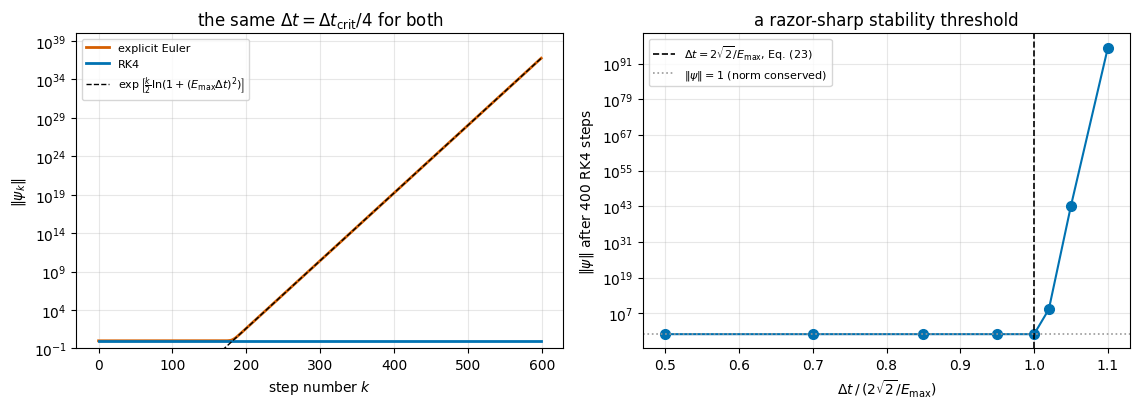


Euler: norm after 600 steps = 5.848e+36   (RK4: 0.999999999996)
Euler growth rate d ln|psi|/dk : measured 0.2027, predicted 0.2027
RK4 norm at dt = 0.95 dt_crit : 1.000000;  at dt = 1.10 dt_crit : 2.398e+96
checkpoints passed: Euler's growth rate matches the derivation; RK4 is stable exactly up to Eq. (23)


In [27]:
# ==============================================================================
# STEP 21: Euler blows up; RK4 has a sharp stability threshold at 2 sqrt(2) / E_max
# ==============================================================================
# a deliberately coarse grid: E_max is smaller, so the interesting dt range is affordable
L_INT, NX_INT = 16.0, 161
x_int, dx_int = make_grid(L_INT, NX_INT)
V_int = jnp.asarray(harmonic_potential(x_int, R_QUENCH), dtype=RDTYPE)
d_int, o_int = hamiltonian_tridiagonal(x_int, dx_int, R_QUENCH)
E_int, Vv_int = eigh_tridiagonal(d_int, o_int)
phi_int = (Vv_int.T / np.sqrt(dx_int)).astype(RDTYPE)

psi0_int = (np.pi**-0.25 * np.exp(-x_int**2 / 2.0)).astype(CDTYPE)
psi0_int /= np.sqrt(grid_norm(psi0_int, dx_int))
psi0_int_j = jnp.asarray(psi0_int, dtype=CDTYPE)
c_int = spectral_coefficients(phi_int, psi0_int, dx_int)

E_MAX_INT = float(E_int[-1])
DT_CRIT_INT = 2.0 * np.sqrt(2.0) / E_MAX_INT
print(f"coarse integrator-test grid: N_x = {NX_INT}, dx = {dx_int:.3f}")
print(f"E_max = {E_MAX_INT:.1f}   (between the pure kinetic 2/dx^2 = {2/dx_int**2:.1f} and the crude upper bound "
      f"2/dx^2 + V_max = {2/dx_int**2 + np.max(harmonic_potential(x_int, R_QUENCH)):.1f};")
print("            the top mode would have to sit where V is largest, and the hard wall there does not let it)")
print(f"dt_crit = 2 sqrt(2) / E_max = {DT_CRIT_INT:.3e}   [Eq. (23)]")
print(f"the grid-only rule sqrt(2) dx^2 = {np.sqrt(2.0) * dx_int**2:.3e}   [Eq. (24)], i.e. "
      f"{np.sqrt(2.0) * dx_int**2 / DT_CRIT_INT:.2f} x the true limit")
print("  (Eq. (24) drops V_max from E_max, so it always OVERestimates the limit; the overshoot")
print("   is large only on a coarse grid in a wide box, as here, and vanishes as dx -> 0:")
print(f"   on the production grid dx = {dx_dyn:.3f} it gives {np.sqrt(2.0) * dx_dyn**2:.3e} against the true "
      f"{2.0 * np.sqrt(2.0) / E_MAX_DYN:.3e}, only "
      f"{100 * (np.sqrt(2.0) * dx_dyn**2 / (2 * np.sqrt(2.0) / E_MAX_DYN) - 1):.1f} % high)")


def grid_norm_jax(psi, dx):
    """|| psi || = sqrt( sum_j |psi_j|^2 dx ) -- the SAME norm as grid_norm, but square-rooted and jax-friendly."""
    return jnp.sqrt(jnp.sum(jnp.abs(psi)**2) * dx)


@partial(jax.jit, static_argnames=("n_steps",))
def euler_norms(psi, V, dx, dt, n_steps):
    """Explicit Euler, recording || psi || after every step."""
    def body(p, _):
        return p - 1j * dt * apply_H(p, V, dx), grid_norm_jax(p, dx)
    return lax.scan(body, psi, None, length=n_steps)


@partial(jax.jit, static_argnames=("n_steps",))
def rk4_norms(psi, V, dx, dt, n_steps):
    """RK4, recording || psi || after every step (for the same comparison)."""
    def body(p, _):
        return rk4_step(p, V, dx, dt), grid_norm_jax(p, dx)
    return lax.scan(body, psi, None, length=n_steps)


dt_demo = DT_CRIT_INT / 4.0
n_demo = 600
_, norm_euler = euler_norms(psi0_int_j, V_int, dx_int, dt_demo, n_demo)
_, norm_rk4 = rk4_norms(psi0_int_j, V_int, dx_int, dt_demo, n_demo)
norm_euler, norm_rk4 = np.asarray(norm_euler), np.asarray(norm_rk4)

steps = np.arange(n_demo)
slope_pred = 0.5 * np.log(1.0 + (E_MAX_INT * dt_demo) ** 2)
slope_meas = np.polyfit(steps[300:], np.log(norm_euler[300:]), 1)[0]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].semilogy(steps, norm_euler, color=C_EXACT, lw=2, label="explicit Euler")
axes[0].semilogy(steps, norm_rk4, color=C_NUM, lw=2, label="RK4")
axes[0].semilogy(steps, norm_euler[300] * np.exp(slope_pred * (steps - 300)), "k--", lw=1,
                 label=r"$\exp\left[\frac{k}{2}\ln(1+(E_{\max}\Delta t)^2)\right]$")
axes[0].set_ylim(1e-1, 1e40)
axes[0].set_xlabel("step number $k$"); axes[0].set_ylabel(r"$\Vert\psi_k\Vert$")
axes[0].set_title(rf"the same $\Delta t = \Delta t_{{\rm crit}}/4$ for both")
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3, which="both")

# --- RK4 stability threshold: scan dt across 2 sqrt(2) / E_max ---
factors = np.array([0.5, 0.7, 0.85, 0.95, 1.0, 1.02, 1.05, 1.1, 1.2])
final_norms = []
for fac in factors:
    pf, _ = rk4_norms(psi0_int_j, V_int, dx_int, fac * DT_CRIT_INT, 400)
    final_norms.append(float(grid_norm_jax(pf, dx_int)))
final_norms = np.array(final_norms)
axes[1].semilogy(factors, final_norms, "o-", color=C_NUM, ms=7)
axes[1].axvline(1.0, color="k", ls="--", lw=1.2, label=r"$\Delta t = 2\sqrt{2}/E_{\max}$, Eq. (23)")
axes[1].axhline(1.0, color="0.6", ls=":", lw=1.2, label=r"$\Vert\psi\Vert = 1$ (norm conserved)")
axes[1].set_xlabel(r"$\Delta t \,/\, (2\sqrt{2}/E_{\max})$")
axes[1].set_ylabel(r"$\Vert\psi\Vert$ after 400 RK4 steps")
axes[1].set_title("a razor-sharp stability threshold"); axes[1].legend(fontsize=8)
axes[1].grid(alpha=.3, which="both")
fig.tight_layout(); plt.show()

print(f"\nEuler: norm after {n_demo} steps = {norm_euler[-1]:.3e}   (RK4: {norm_rk4[-1]:.12f})")
print(f"Euler growth rate d ln|psi|/dk : measured {slope_meas:.4f}, predicted {slope_pred:.4f}")
print(f"RK4 norm at dt = 0.95 dt_crit : {final_norms[3]:.6f};  at dt = 1.10 dt_crit : {final_norms[-2]:.3e}")
assert abs(slope_meas - slope_pred) / slope_pred < 0.02
assert final_norms[factors <= 1.0].max() < 1.0 + 1e-6 and final_norms[-1] > 1e3
print("checkpoints passed: Euler's growth rate matches the derivation; RK4 is stable exactly up to Eq. (23)")

Read the left panel carefully. Explicit Euler starts from a perfectly normalised state, and within $600$ steps
the norm has reached $6\times10^{36}$ — the dashed line shows that the growth rate is precisely the one we derived from
$\vert 1 - iE_{\max}\Delta t\vert$. Nothing about the physics is wrong; the *integrator* manufactures the
catastrophe out of round-off. RK4 at the very same $\Delta t$ keeps the norm at $1.000000000000$.

The right panel shows the threshold of Eq. (23): at $0.95\,\Delta t_{\rm crit}$ the norm is $1$ to six digits; at
$1.10\,\Delta t_{\rm crit}$ it has already exploded after 400 steps: the loss of stability is abrupt. The printed lines above compare the exact threshold $2\sqrt2/E_{\max}$ with the
grid-only rule $\sqrt2\,\Delta x^2$ of Eq. (24). The rule is always *optimistic*, because it drops
$\max_j V(x_j)$ from $E_{\max}$, and the error shrinks as $\Delta x^2 \max_j V$: on this deliberately coarse
test grid ($\Delta x = 0.1$ in a box where $V$ reaches $128$) it overestimates the limit by $56\,\%$, on the
production grid of Section 12.6 ($\Delta x = 0.025$) by only $3.5\,\%$. Use Eq. (24) to *plan* a run and
$2\sqrt2/E_{\max}$ with a safety factor to *set* the step — the production run above uses
$0.4\,\Delta t_{\rm crit}$.

### 12.8 The two error laws of RK4

Two independent predictions to test, both derived above:

1. **Global accuracy.** Local error $O(\Delta t^5)$ over $T/\Delta t$ steps gives a global error
   $\propto \Delta t^4$.
2. **Norm drift.** From $\vert R\vert \simeq 1 - \theta^6/144$ with $\theta = E_n\Delta t$, after $T/\Delta t$
   steps

$$ 1 - \lVert\psi(T)\rVert \;\simeq\; \frac{T}{144}\,\Delta t^{5}\,\sum_n \vert c_n\vert^2 E_n^{6} , \tag{25} $$

a $\Delta t^5$ law with a *computable prefactor*. The norm drifts **downwards**: RK4 quietly throws away
a little probability at every step, which is far safer than Euler's explosion but must still be monitored.

We run the scan on the coarse grid, because Eq. (23) ties the accessible $\Delta t$ to $\Delta x^2$; on the fine
grid the whole stable range already sits below the round-off floor, and we would measure nothing but noise.

sum_n |c_n|^2 E_n^6 = 6.5030e+03   (prefactor of Eq. (25))



         dt   n_steps   max|psi-exact|   ratio      1-|psi|      Eq.(25)  wall [s]
  4.518e-03      1043        1.845e-07            4.005e-10    4.007e-10      0.86
  2.260e-03      2085        1.154e-08   15.98    1.255e-11    1.255e-11      0.98
  1.130e-03      4170        7.212e-10   16.01    3.921e-13    3.922e-13      1.37
  5.650e-04      8340        4.507e-11   16.00    1.321e-14    1.226e-14      2.19
  2.825e-04     16679        2.818e-12   15.99    0.000e+00    3.831e-16      3.22


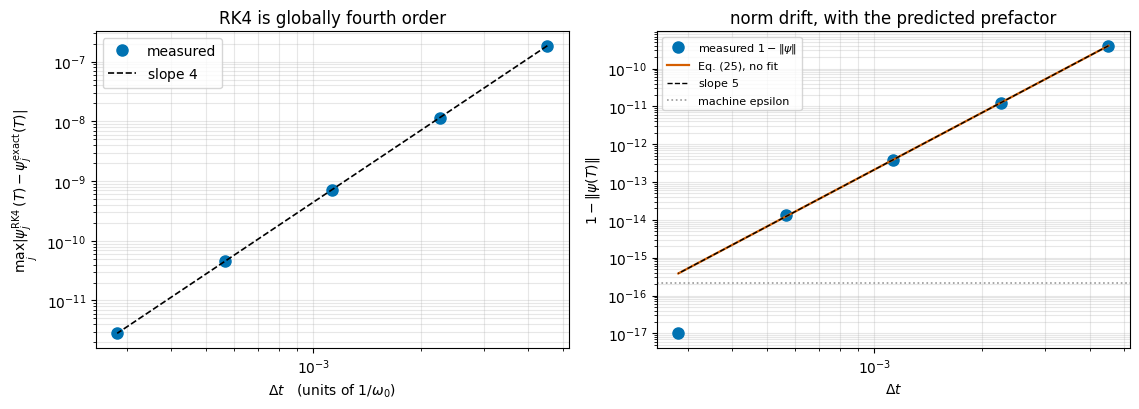


fitted order of accuracy      : 4.000   (expected 4)
measured / Eq. (25), 3 coarsest dt : [0.9996 0.9999 0.9998]   (expected 1)
(the two finest steps are left out: their drift, 1e-14 and 0, is already at the round-off floor)
checkpoints passed: order 4 in the solution, order 5 in the norm, both with the derived prefactor


In [28]:
# ==============================================================================
# STEP 22: measured RK4 error laws -- global order 4 and norm drift of order 5
# ==============================================================================
psi_ref_int = phi_int.T @ (c_int * np.exp(-1j * E_int * T_FINAL))     # exact, method (a)
sum_c2_E6 = float(np.sum(np.abs(c_int)**2 * E_int**6))
print(f"sum_n |c_n|^2 E_n^6 = {sum_c2_E6:.4e}   (prefactor of Eq. (25))")

dt_factors = [2, 4, 8, 16, 32]
dts, errs, drifts, walls = [], [], [], []
for k in dt_factors:
    n_steps = int(np.ceil(T_FINAL / (DT_CRIT_INT / k)))
    dt_k = T_FINAL / n_steps
    t_start = time.time()
    # n_inner = n_steps, n_outer = 1: all the steps in one go, and we keep only the CARRY (the final state)
    psi_k, _ = rk4_evolve(jnp.asarray(psi0_int, dtype=CDTYPE), V_int, dx_int, dt_k, n_steps, 1)
    psi_k.block_until_ready()
    walls.append(time.time() - t_start)
    psi_k = np.asarray(psi_k)
    dts.append(dt_k)
    errs.append(np.max(np.abs(psi_k - psi_ref_int)))
    drifts.append(1.0 - np.sqrt(np.sum(np.abs(psi_k)**2) * dx_int))
dts, errs, drifts = np.array(dts), np.array(errs), np.array(drifts)

print(f"\n{'dt':>11s} {'n_steps':>9s} {'max|psi-exact|':>16s} {'ratio':>7s} "
      f"{'1-|psi|':>12s} {'Eq.(25)':>12s} {'wall [s]':>9s}")
for i in range(len(dts)):
    ratio = "" if i == 0 else f"{errs[i-1]/errs[i]:7.2f}"
    pred = T_FINAL / 144.0 * dts[i]**5 * sum_c2_E6
    print(f"{dts[i]:11.3e} {int(round(T_FINAL/dts[i])):9d} {errs[i]:16.3e} {ratio:>7s} "
          f"{drifts[i]:12.3e} {pred:12.3e} {walls[i]:9.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].loglog(dts, errs, "o", color=C_NUM, ms=8, label="measured")
axes[0].loglog(dts, errs[0] * (dts / dts[0])**4, "k--", lw=1.2, label=r"slope $4$")
axes[0].set_xlabel(r"$\Delta t$   (units of $1/\omega_0$)")
axes[0].set_ylabel(r"$\max_j\vert\psi_j^{\rm RK4}(T)-\psi_j^{\rm exact}(T)\vert$")
axes[0].set_title("RK4 is globally fourth order"); axes[0].legend(); axes[0].grid(which="both", alpha=.3)

axes[1].loglog(dts, np.maximum(drifts, 1e-17), "o", color=C_NUM, ms=8,
               label=r"measured $1-\Vert\psi\Vert$")
axes[1].loglog(dts, T_FINAL / 144.0 * dts**5 * sum_c2_E6, "-", color=C_EXACT, lw=1.6,
               label="Eq. (25), no fit")
axes[1].loglog(dts, drifts[0] * (dts / dts[0])**5, "k--", lw=1.0, label=r"slope $5$")
axes[1].axhline(2.2e-16, color="0.6", ls=":", lw=1.2, label="machine epsilon")
axes[1].set_xlabel(r"$\Delta t$"); axes[1].set_ylabel(r"$1-\Vert\psi(T)\Vert$")
axes[1].set_title("norm drift, with the predicted prefactor"); axes[1].legend(fontsize=8)
axes[1].grid(which="both", alpha=.3)
fig.tight_layout(); plt.show()

order = np.polyfit(np.log(dts), np.log(errs), 1)[0]
drift_ratio = drifts[:3] / (T_FINAL / 144.0 * dts[:3]**5 * sum_c2_E6)
print(f"\nfitted order of accuracy      : {order:.3f}   (expected 4)")
print(f"measured / Eq. (25), 3 coarsest dt : {np.array2string(drift_ratio, precision=4)}   (expected 1)")
print("(the two finest steps are left out: their drift, 1e-14 and 0, is already at the round-off floor)")
assert abs(order - 4.0) < 0.05
assert np.all(np.abs(drift_ratio - 1.0) < 0.02)
print("checkpoints passed: order 4 in the solution, order 5 in the norm, both with the derived prefactor")

Both laws come out exactly as derived — the error ratio is $16.0$ per halving of $\Delta t$, and the norm drift
follows Eq. (25) *with no fitted parameter* over three decades. The last two points of the right-hand panel leave
the line because they have reached the machine-epsilon floor: the second-to-last is $8\,\%$ high, and for the last
one the measured drift is *exactly zero*, which a log axis cannot show at all — it is parked on the artificial
floor at $10^{-17}$ at the bottom of the panel. That is itself a useful thing to recognise in a convergence plot:
below round-off, "the error stops decreasing" does not mean "the method has a problem".

### 12.9 All four moments, and the squeezed state

Before comparing costs, let us hold the quench up against the analytics of Section 12.2 with the same panel we
used for the two previous experiments — and, in the variance panel, overlay the results of the other two
integrators as open circles, so that "methods (a)–(c) agree" becomes something you can see.

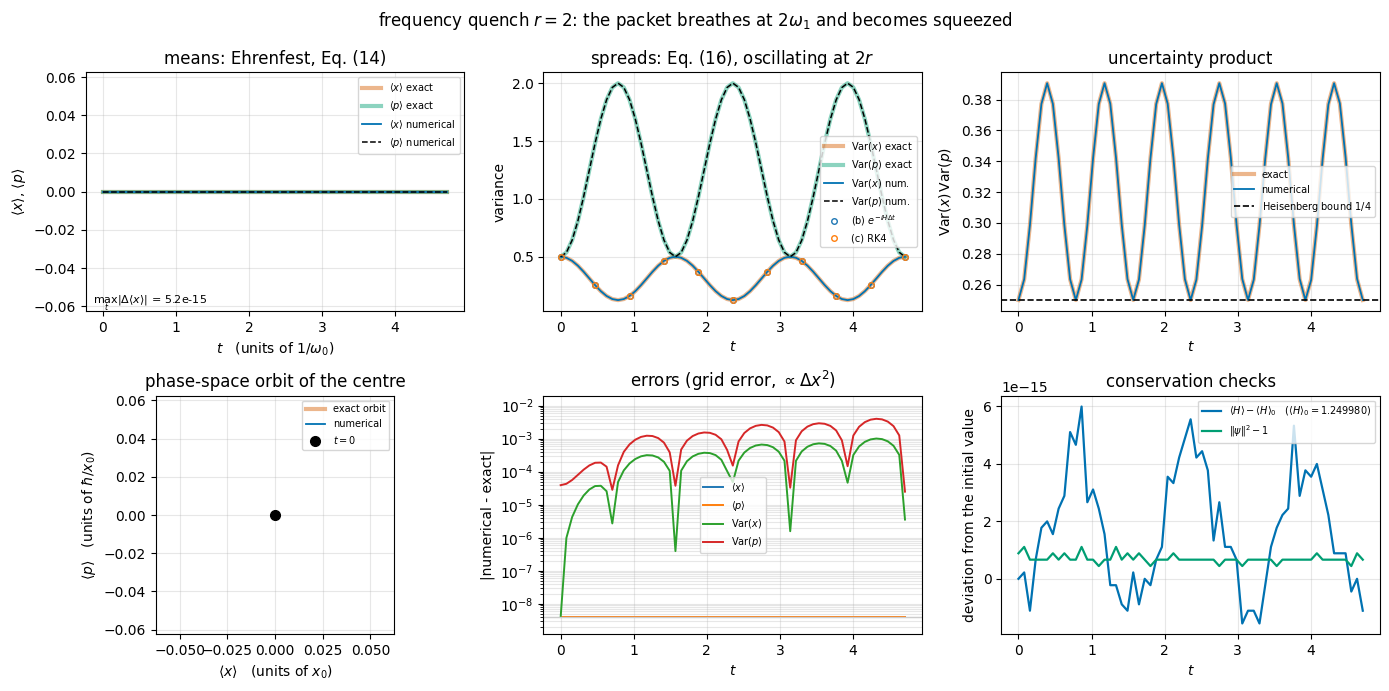

maximal |numerical - analytic|:
   <x>      5.196e-15
   <p>      6.648e-15
   Var(x)   1.007e-03
   Var(p)   3.989e-03

Var(x): min 0.12495 (exact 0.12500)   max 0.50000 (exact 0.5)
Var(p): min 0.49996 (exact 0.5)   max 2.00016 (exact 2.00000)
uncertainty product: min 0.24992 (Heisenberg bound 0.25)   max 0.39061 (exact 0.39062)
energy: 1.249980 .. 1.249980   (exact 1.250000)



at t = 0.7854 (= pi/(2r) = 0.7854):
   Var(x) = 0.12495  vs the NEW ground state 1/(2r) = 0.25000  -> squeezed by a factor 2.00 in variance
   Var(x) Var(p) = 0.24992  -> a MINIMUM-UNCERTAINTY (squeezed) state
propagator : max |Var(x) - (a)| = 1.77e-13,  max |Var(p) - (a)| = 6.21e-13
RK4        : max |Var(x) - (a)| = 1.87e-12,  max |Var(p) - (a)| = 7.42e-12
checkpoints passed: Eqs. (19), (20), (21), squeezing, and agreement of the integrators (a)-(c)


In [29]:
# ==============================================================================
# STEP 23: the quench -- means, variances, uncertainty product, squeezing
# ==============================================================================
analytic_quench = dict(x=np.zeros_like(t_snap),
                       p=np.zeros_like(t_snap),
                       vx=sigma2_exact(t_snap, R_QUENCH),
                       vp=varp_exact(t_snap, R_QUENCH))
res_q = moment_panels(t_snap, psi_spectral, x_dyn, dx_dyn, analytic_quench, freq_ratio=R_QUENCH,
                      title=rf"frequency quench $r={R_QUENCH:g}$: the packet breathes at $2\omega_1$ "
                            r"and becomes squeezed",
                      extra={r"(b) $e^{-iH\Delta t}$": (t_snap, psi_prop),
                             "(c) RK4": (t_snap, psi_rk4)})

prod_q = res_q["vx"] * res_q["vp"]
prod_max_exact = 0.25 * (1.0 + 0.25 * (R_QUENCH - 1.0 / R_QUENCH)**2)
print("maximal |numerical - analytic|:")
for key, label in [("x", "<x>"), ("p", "<p>"), ("vx", "Var(x)"), ("vp", "Var(p)")]:
    print(f"   {label:8s} {res_q['max_err'][key]:.3e}")
print(f"\nVar(x): min {res_q['vx'].min():.5f} (exact {1/(2*R_QUENCH**2):.5f})   "
      f"max {res_q['vx'].max():.5f} (exact 0.5)")
print(f"Var(p): min {res_q['vp'].min():.5f} (exact 0.5)   "
      f"max {res_q['vp'].max():.5f} (exact {R_QUENCH**2/2:.5f})")
print(f"uncertainty product: min {prod_q.min():.5f} (Heisenberg bound 0.25)   "
      f"max {prod_q.max():.5f} (exact {prod_max_exact:.5f})")
print(f"energy: {res_q['energy'].min():.6f} .. {res_q['energy'].max():.6f}   "
      f"(exact {(1+R_QUENCH**2)/4:.6f})")

# the squeezed instant: half a breathing period (a quarter of the new trap period) after the quench
k_sq = int(np.argmin(res_q["vx"]))
print(f"\nat t = {t_snap[k_sq]:.4f} (= pi/(2r) = {np.pi/(2*R_QUENCH):.4f}):")
print(f"   Var(x) = {res_q['vx'][k_sq]:.5f}  vs the NEW ground state 1/(2r) = {1/(2*R_QUENCH):.5f}"
      f"  -> squeezed by a factor {1/(2*R_QUENCH)/res_q['vx'][k_sq]:.2f} in variance")
print(f"   Var(x) Var(p) = {prod_q[k_sq]:.5f}  -> a MINIMUM-UNCERTAINTY (squeezed) state")

for key in ("x", "p", "vx", "vp"):
    # Var(p) swings up to r^2/2 = 2, so its absolute dx^2 error is correspondingly larger
    assert res_q["max_err"][key] < 1e-2, f"{key} does not follow the analytic law"
assert prod_q.min() > 0.25 - 1e-3 and abs(prod_q.min() - 0.25) < 5e-3
assert abs(prod_q.max() - prod_max_exact) < 5e-3
# the integrators (a)–(c) must give the same moments, far below the grid error
for name, psi_other in [("propagator", psi_prop), ("RK4", psi_rk4)]:
    d_vx = np.max(np.abs(grid_var_x(psi_other, x_dyn, dx_dyn) - res_q["vx"]))
    d_vp = np.max(np.abs(grid_var_p(psi_other, dx_dyn) - res_q["vp"]))
    print(f"{name:11s}: max |Var(x) - (a)| = {d_vx:.2e},  max |Var(p) - (a)| = {d_vp:.2e}")
    assert d_vx < 1e-8 and d_vp < 1e-8
print("checkpoints passed: Eqs. (19), (20), (21), squeezing, and agreement of the integrators (a)-(c)")

Everything in the derivation is visible at once. The means stay at zero to $10^{-15}$ (parity). The two variances
oscillate at $2\omega_1$ in exact antiphase between the predicted extremes. The uncertainty product rises to
$0.39$ in between and comes back down to **exactly $1/4$** at every turning point of the breathing. At
$t = \pi/(2r)$ and every breathing period after it the minimum-uncertainty Gaussian has the position variance
$1/(2r^2) = 0.125$, a factor $r=2$ *below* that of the new trap's own ground state — a **squeezed state**,
produced by suddenly stiffening a trap and waiting a quarter of its period.

One caveat about the uncertainty panel. The printed minimum is $0.24992$, a hair *below* the Heisenberg
bound $\tfrac14$. Heisenberg is not in danger: what we compute on the grid is not $\mathrm{Var}(p)$ but its
three-point approximation, which by Eq. (10) undershoots by $O(\Delta x^2)$ — and $8\times10^{-5}$ is exactly
that size. A discretised operator obeys the discrete algebra; a bound that must hold *exactly* has to be built
into the scheme.

The open circles from the propagator and from RK4 sit exactly on the spectral curve: the integrators (a)–(c) agree
on the moments to better than $10^{-11}$, which is some **eight orders of magnitude** better than their common distance from
the analytic law ($10^{-3}$, the $\Delta x^2$ grid error). That observation sets up the next subsection.

### 12.10 Accuracy and cost, side by side

Finally, the comparison that a practitioner actually cares about.

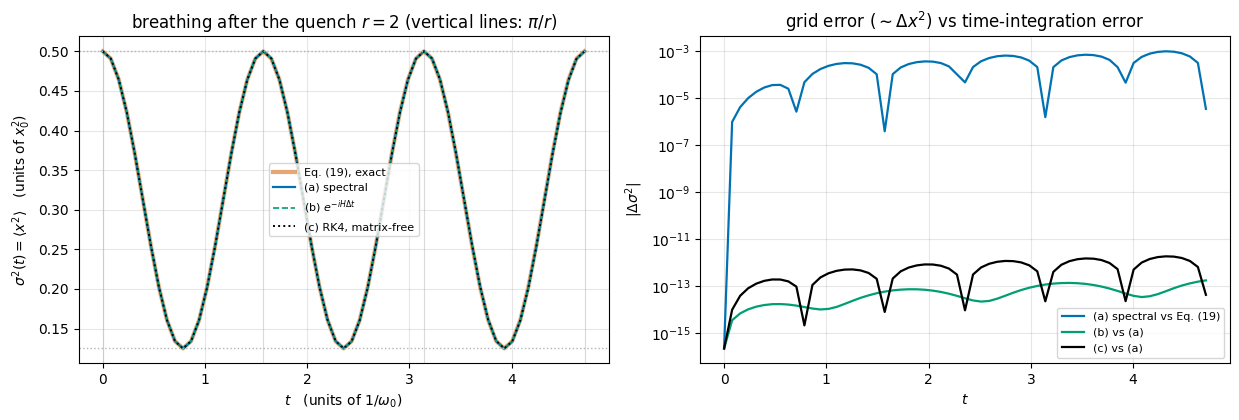

method                              wall time [s]    norm error   max |psi - (a)|
(a) diagonalise + Eq. (17)                   0.52      6.66e-16          0.00e+00
(b) expm + 480 matvecs                       4.75      3.90e-13          1.11e-12
(c) RK4, 13800 matrix-free steps             5.86      1.78e-15          9.46e-12

methods (a)-(c) agree with the analytic law of Eq. (19) to 1.01e-03, which is the GRID error of Eq. (10), not a time-integration error


In [30]:
# ==============================================================================
# STEP 24: methods (a)-(c) -- agreement and measured cost
# ==============================================================================
sigma2_prop = grid_expect(psi_prop, x_dyn**2, dx_dyn) - grid_expect(psi_prop, x_dyn, dx_dyn)**2
sigma2_rk4 = grid_expect(psi_rk4, x_dyn**2, dx_dyn) - grid_expect(psi_rk4, x_dyn, dx_dyn)**2
sigma2_ref = sigma2_exact(t_snap, R_QUENCH)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
axes[0].plot(t_snap, sigma2_ref, color=C_EXACT, lw=3.0, alpha=.55, label="Eq. (19), exact")
axes[0].plot(t_snap, sigma2_spectral, color=C_NUM, lw=1.6, label="(a) spectral")
axes[0].plot(t_snap, sigma2_prop, color=C_HL, lw=1.2, ls="--", label=r"(b) $e^{-iH\Delta t}$")
axes[0].plot(t_snap, sigma2_rk4, "k:", lw=1.4, label="(c) RK4, matrix-free")
for k in range(4):
    axes[0].axvline(k * T_BREATH, color="0.85", lw=.8, zorder=0)
axes[0].axhline(0.5, color="0.7", ls=":", lw=1)
axes[0].axhline(1 / (2 * R_QUENCH**2), color="0.7", ls=":", lw=1)
axes[0].set_xlabel(r"$t$   (units of $1/\omega_0$)")
axes[0].set_ylabel(r"$\sigma^2(t)=\langle x^2\rangle$   (units of $x_0^2$)")
axes[0].set_title(rf"breathing after the quench $r={R_QUENCH:g}$ (vertical lines: $\pi/r$)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

axes[1].semilogy(t_snap, np.abs(sigma2_spectral - sigma2_ref) + 1e-18, color=C_NUM, lw=1.6,
                 label="(a) spectral vs Eq. (19)")
axes[1].semilogy(t_snap, np.abs(sigma2_prop - sigma2_spectral) + 1e-18, color=C_HL, lw=1.6,
                 label="(b) vs (a)")
axes[1].semilogy(t_snap, np.abs(sigma2_rk4 - sigma2_spectral) + 1e-18, "k-", lw=1.6, label="(c) vs (a)")
axes[1].set_xlabel(r"$t$"); axes[1].set_ylabel(r"$\vert\Delta\sigma^2\vert$")
axes[1].set_title(r"grid error ($\sim\Delta x^2$) vs time-integration error")
axes[1].legend(fontsize=8); axes[1].grid(alpha=.3, which="both")
fig.tight_layout(); plt.show()

print(f"{'method':34s} {'wall time [s]':>14s} {'norm error':>13s} {'max |psi - (a)|':>17s}")
print(f"{'(a) diagonalise + Eq. (17)':34s} {time_diag + time_spectral:14.2f} "
      f"{abs(grid_norm(psi_spectral[-1], dx_dyn) - 1):13.2e} {0.0:17.2e}")
print(f"{'(b) expm + ' + str(N_SNAP*N_SUBSTEPS) + ' matvecs':34s} {time_build_U + time_prop:14.2f} "
      f"{abs(grid_norm(psi_prop[-1], dx_dyn) - 1):13.2e} {np.max(np.abs(psi_prop - psi_spectral)):17.2e}")
print(f"{'(c) RK4, ' + str(N_INNER*N_SNAP) + ' matrix-free steps':34s} {time_rk4:14.2f} "
      f"{abs(grid_norm(psi_rk4[-1], dx_dyn) - 1):13.2e} {np.max(np.abs(psi_rk4 - psi_spectral)):17.2e}")
print(f"\nmethods (a)-(c) agree with the analytic law of Eq. (19) to "
      f"{max(np.max(np.abs(s - sigma2_ref)) for s in (sigma2_spectral, sigma2_prop, sigma2_rk4)):.2e}, "
      f"which is the GRID error of Eq. (10), not a time-integration error")

Read the right-hand panel carefully, because it makes the central point of the whole notebook. The blue curve is
the difference between the *exact solution of the discretised problem* and the *exact solution of the continuum
problem*: it is the $\Delta x^2$ grid error, around $10^{-3}$, and no integrator can do anything about it. The
green and black curves are the differences between the integrators (a)–(c), $10^{-13}$ or below: the time
integration is some **ten orders of magnitude** more accurate than the space discretisation.

> **Numerical practice.** Spend your effort where the error is. Tightening $\Delta t$ here would be a complete
> waste of CPU time; the only way to improve this simulation is a finer grid or a better stencil (Exercise 3).
> Always *measure* the two error sources separately, as we just did, before optimising anything.

### 12.11 Method (d): the Crank–Nicolson scheme

RK4 was stable only for $\Delta t\le2\sqrt2/E_{\max}$, and on our grid $E_{\max}=3310$ forces $\Delta t<8.5\times10^{-4}$, although the state itself only contains energies of
order one. The step is set by the *fastest mode the grid can hold*, not by the physics. We now build an integrator without this limit.

**Derivation 1: the trapezoidal rule.** Integrate $\dot\psi=-iH\psi$ exactly from $t_k$ to $t_{k+1}=t_k+\Delta t$:

$$ \psi_{k+1}-\psi_k=-i\int_{t_k}^{t_{k+1}}H\psi(t)\,dt . $$

Explicit Euler replaced the integrand by its value at the *left* end, $\Delta t\,H\psi_k$. The trapezoidal rule uses the *average* of both ends, which is exact for any
integrand that is linear in $t$ and therefore one order more accurate:

$$ \psi_{k+1}-\psi_k=-\frac{i\Delta t}{2}\big(H\psi_{k+1}+H\psi_k\big) . \tag{26}$$

The unknown $\psi_{k+1}$ appears on both sides. Collecting it on the left gives a **linear system** for the new state:

$$ \Big(1+\frac{i\Delta t}{2}H\Big)\,\psi_{k+1}=\Big(1-\frac{i\Delta t}{2}H\Big)\,\psi_k . \tag{27}$$

This is the **Crank–Nicolson** scheme (Crank and Nicolson, 1947). A scheme in which the new state appears on the right-hand side of its own definition is called *implicit*: every step costs a linear solve.

**Derivation 2: the Cayley form.** Write the exact propagator as a ratio of two half steps, $e^{-iH\Delta t}=e^{-iH\Delta t/2}\big/e^{+iH\Delta t/2}$, and expand numerator and denominator to first order:
$e^{-iH\Delta t}\approx(1-\tfrac{i\Delta t}{2}H)(1+\tfrac{i\Delta t}{2}H)^{-1}$. Multiplying Eq. (27) by $(1+\tfrac{i\Delta t}{2}H)^{-1}$ gives exactly this operator: the two derivations agree.

**Why it is unitary for every $\Delta t$.** Expand $\psi_k$ in the eigenstates of $H$. A component with energy $E$ is multiplied in one step by

$$ R_{\rm CN}(\theta)=\frac{1-i\theta/2}{1+i\theta/2},\qquad \theta=E\Delta t . \tag{28}$$

Numerator and denominator are complex conjugates, so $|R_{\rm CN}|=1$ **exactly**, for every real $\theta$: no mode grows, no mode decays, the norm is conserved for any step, and
there is no stability limit. (Compare Eq. (23) for RK4, whose $|R|$ exceeds one beyond $\theta^2=8$.)

**How accurate it is.** A unit complex number is a pure phase, $R_{\rm CN}=e^{-i\varphi(\theta)}$. Writing $1+i\theta/2=\rho\,e^{i\alpha}$ with $\alpha=\arctan(\theta/2)$, the numerator is
$\rho\,e^{-i\alpha}$ and $R_{\rm CN}=e^{-2i\alpha}$, so

$$ \varphi(\theta)=2\arctan\frac\theta2=\theta-\frac{\theta^3}{12}+\mathcal O(\theta^5), \tag{29}$$

using $\arctan u=u-u^3/3+\dots$. The exact phase is $\theta$; each step makes a phase error $-\theta^3/12=-E^3\Delta t^3/12$, and after $t/\Delta t$ steps the eigencomponent $E_n$ carries
the accumulated phase error $\delta_n=-E_n^3\,t\,\Delta t^2/12$: **Crank–Nicolson is second order**. How much does such an error cost in fidelity? The numerical state is
$\sum_nc_ne^{-iE_nt}e^{-i\delta_n}|n\rangle$ and the exact one $\sum_nc_ne^{-iE_nt}|n\rangle$, so their overlap is $\sum_n|c_n|^2e^{-i\delta_n}$. Expanding the exponential to second order,
$|\sum_np_ne^{-i\delta_n}|^2\simeq1-\big(\sum_np_n\delta_n^2-(\sum_np_n\delta_n)^2\big)$ with $p_n=|c_n|^2$: the infidelity is the **variance of the phase errors**. With Eq. (29),

$$ 1-F(t)\simeq\Big(\frac{t\,\Delta t^2}{12}\Big)^2\,\mathrm{Var}(E^3),\qquad \mathrm{Var}(E^3)=\sum_np_nE_n^6-\Big(\sum_np_nE_n^3\Big)^2 . \tag{30}$$

A prediction without any fitted parameter: the infidelity grows as $t^2$ and falls as $\Delta t^4$, and its size is set by the energies *present in the state* — not by $E_{\max}$.
A mode with a huge $E$ does get a wrong phase (for $\theta\to\infty$, $\varphi\to\pi$), but it is never amplified, and if the state does not contain it, it costs nothing.

**From formula to code.** $H$ is tridiagonal (Section 6), so $A=1+\tfrac{i\Delta t}{2}H$ is tridiagonal too: diagonal $1+\tfrac{i\Delta t}{2}\big(1/\Delta x^2+V_j\big)$, off-diagonals
$\tfrac{i\Delta t}{2}\big(-\tfrac{1}{2\Delta x^2}\big)$. A tridiagonal system is solved by one forward elimination and one back substitution (the Thomas algorithm) in $O(N_x)$ operations —
the same order as one RK4 step. JAX provides it as `jax.lax.linalg.tridiagonal_solve(dl, d, du, b)`, which takes the lower diagonal `dl` (first entry unused, set to zero), the diagonal
`d`, the upper diagonal `du` (last entry unused) and a right-hand side of shape `(N_x, 1)`. The right-hand side of Eq. (27) is one `apply_H`. The time loop is the same nested `lax.scan` as for RK4.

In [31]:
# ==============================================================================
# METHOD (d): Crank-Nicolson, Eq. (27): one apply_H and one tridiagonal solve per step
# ==============================================================================
def crank_nicolson_diagonals(V, dx, dt):
    """The three diagonals of A = 1 + (i dt/2) H, H = tridiagonal Hamiltonian of Eq. (8) on the grid.

    MATH   A_jj = 1 + (i dt/2)(1/dx^2 + V_j),   A_{j,j+1} = A_{j+1,j} = (i dt/2)(-1/(2 dx^2))
    RETURNS (dl, d, du) in the layout of jax.lax.linalg.tridiagonal_solve: dl[0] = 0 and du[-1] = 0 are not used.
    """
    d = 1.0 + 0.5j * dt * (1.0 / dx**2 + V)
    off = jnp.full(V.shape, 0.5j * dt * (-0.5 / dx**2), dtype=CDTYPE)
    return off.at[0].set(0.0), d.astype(CDTYPE), off.at[-1].set(0.0)


def cn_step(psi, V, dx, dt, diagonals):
    """One Crank-Nicolson step:  solve (1 + i dt H/2) psi_new = (1 - i dt H/2) psi.   COST O(N_x)."""
    dl, d, du = diagonals
    rhs = psi - 0.5j * dt * apply_H(psi, V, dx)                            # right-hand side of the Crank-Nicolson step
    return lax.linalg.tridiagonal_solve(dl, d, du, rhs[:, None])[:, 0]     # Thomas algorithm, O(N_x)


@partial(jax.jit, static_argnames=("n_inner", "n_outer"))
def cn_evolve(psi0, V, dx, dt, n_inner, n_outer):
    """n_outer * n_inner Crank-Nicolson steps, storing the state after every n_inner of them (as rk4_evolve)."""
    diagonals = crank_nicolson_diagonals(V, dx, dt)                        # built once: the step is fixed

    def inner(psi, _):
        return cn_step(psi, V, dx, dt, diagonals), None

    def outer(psi, _):
        psi, _ = lax.scan(inner, psi, None, length=n_inner)
        return psi, psi

    return lax.scan(outer, psi0, None, length=n_outer)


# ------------------------------------------------------------------------------
# CHECKPOINT: one step against the exact Cayley matrix  (1 + i dt H/2)^{-1} (1 - i dt H/2)
# ------------------------------------------------------------------------------
dt_chk = 0.05
H_chk = hamiltonian_dense(x_dyn, dx_dyn, R_QUENCH)
cayley = np.linalg.solve(np.eye(NX_DYN) + 0.5j * dt_chk * H_chk, np.eye(NX_DYN) - 0.5j * dt_chk * H_chk)
V_dyn_j, psi_quench0_j = jnp.asarray(V_dyn), jnp.asarray(psi_quench0)
one_step = cn_step(psi_quench0_j, V_dyn_j, dx_dyn, dt_chk, crank_nicolson_diagonals(V_dyn_j, dx_dyn, dt_chk))
print(f"one CN step vs dense Cayley matrix: max difference {np.max(np.abs(np.asarray(one_step) - cayley @ psi_quench0)):.1e}")
print(f"Cayley matrix unitary:              max |C^dag C - 1| = {np.max(np.abs(cayley.conj().T @ cayley - np.eye(NX_DYN))):.1e}")
assert np.max(np.abs(np.asarray(one_step) - cayley @ psi_quench0)) < 1e-12

one CN step vs dense Cayley matrix: max difference 2.9e-15


Cayley matrix unitary:              max |C^dag C - 1| = 1.8e-15


**The experiment.** We solve the quench of this section again and compare both integrators with the exact spectral solution of method (a) — the *same* grid Hamiltonian, so that only the time
error is measured. The measure is the infidelity $1-F=1-|\langle\psi_{\rm exact}|\psi\rangle|^2$ of the normalised states. We vary the step in two ways: along the whole trajectory for a few
fixed $\Delta t$, and at the final time for many $\Delta t$, and compare Crank–Nicolson with the prediction (30).

Var(E^3) of the quenched state = 6.3652e+03;   RK4 limit dt_crit = 8.544e-04


CN  dt = 3.927e-02: 1-F at T/3, 2T/3, T = 2.33e-04, 8.67e-04, 1.79e-03   Eq. (30) at T: 2.334e-03
CN  dt = 9.817e-03: 1-F at T/3, 2T/3, T = 1.01e-06, 4.03e-06, 9.06e-06   Eq. (30) at T: 9.119e-06
CN  dt = 2.454e-03: 1-F at T/3, 2T/3, T = 3.96e-09, 1.58e-08, 3.56e-08   Eq. (30) at T: 3.562e-08
RK4 dt = 7.854e-04: 1-F at T/3, 2T/3, T = -4.44e-16, -2.22e-16, 1.11e-16   (0.92 dt_crit)



CN, final time: largest norm error over all steps 1.4e-14
   CN  dt = 7.854e-02  (  91.9 dt_crit): 1-F(T) = 1.447e-02   Eq. (30): 3.735e-02
   CN  dt = 3.927e-02  (  46.0 dt_crit): 1-F(T) = 1.793e-03   Eq. (30): 2.334e-03
   CN  dt = 1.963e-02  (  23.0 dt_crit): 1-F(T) = 1.395e-04   Eq. (30): 1.459e-04
   CN  dt = 9.817e-03  (  11.5 dt_crit): 1-F(T) = 9.058e-06   Eq. (30): 9.119e-06
   CN  dt = 4.909e-03  (   5.7 dt_crit): 1-F(T) = 5.692e-07   Eq. (30): 5.699e-07
   CN  dt = 2.454e-03  (   2.9 dt_crit): 1-F(T) = 3.561e-08   Eq. (30): 3.562e-08
   CN  dt = 1.227e-03  (   1.4 dt_crit): 1-F(T) = 2.226e-09   Eq. (30): 2.226e-09
   RK4 dt = 9.240e-04  (  1.08 dt_crit): 1-F(T) = nan
   RK4 dt = 7.854e-04  (  0.92 dt_crit): 1-F(T) = 1.110e-16
   RK4 dt = 5.236e-04  (  0.61 dt_crit): 1-F(T) = -4.441e-16
   RK4 dt = 3.927e-04  (  0.46 dt_crit): 1-F(T) = 3.331e-16
   RK4 dt = 1.963e-04  (  0.23 dt_crit): 1-F(T) = -2.220e-16


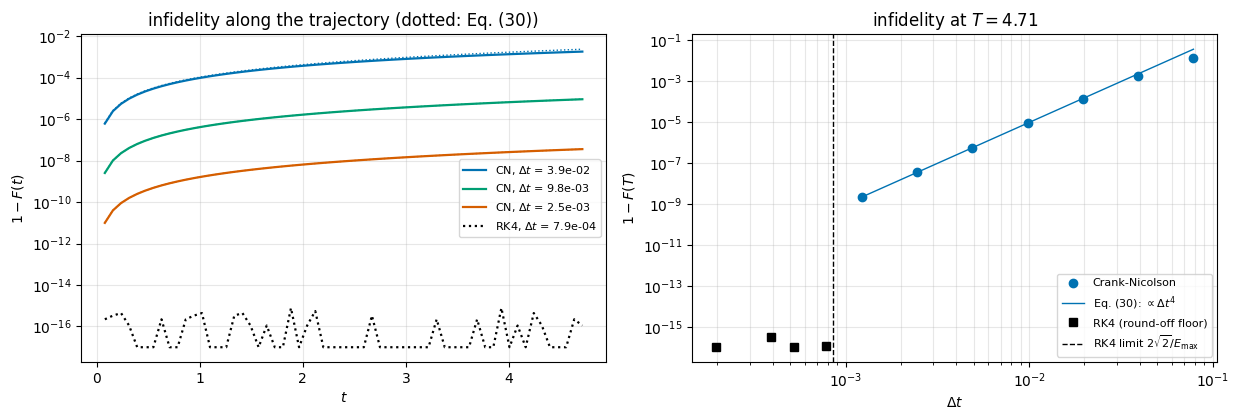

In [32]:
# ==============================================================================
# EXPERIMENT: Crank-Nicolson vs RK4 -- infidelity as a function of time and of the step
# ==============================================================================
def infidelity(psi_num, psi_exact, dx):
    """1 - |<psi_exact|psi_num>|^2 / (||psi_exact||^2 ||psi_num||^2), along the last axis (grid)."""
    overlap = np.abs(np.sum(np.conj(psi_exact) * psi_num, axis=-1) * dx) ** 2
    return 1.0 - overlap / (np.sum(np.abs(psi_num) ** 2, axis=-1) * dx * np.sum(np.abs(psi_exact) ** 2, axis=-1) * dx)


p_n = np.abs(c_dyn) ** 2                                                    # weights |c_n|^2 of the quenched state
var_E3 = np.sum(p_n * E_dyn**6) - np.sum(p_n * E_dyn**3) ** 2               # Var(E^3) of Eq. (30)
interval = t_snap[1] - t_snap[0]
DT_CRIT = 2.0 * np.sqrt(2.0) / E_MAX_DYN
print(f"Var(E^3) of the quenched state = {var_E3:.4e};   RK4 limit dt_crit = {DT_CRIT:.3e}")

# (1) along the trajectory, three CN steps and RK4 just inside its limit
traj = {}
for n_inner in (2, 8, 32):
    _, s = cn_evolve(psi_quench0_j, V_dyn_j, dx_dyn, interval / n_inner, n_inner, N_SNAP)
    traj[("CN", n_inner)] = infidelity(np.concatenate([psi_quench0[None], np.asarray(s)]), psi_spectral, dx_dyn)
_, s = rk4_evolve(psi_quench0_j, V_dyn_j, dx_dyn, interval / 100, 100, N_SNAP)
traj[("RK4", 100)] = infidelity(np.concatenate([psi_quench0[None], np.asarray(s)]), psi_spectral, dx_dyn)
for (name, n_inner), f in traj.items():
    dt = interval / n_inner
    extra = f"   Eq. (30) at T: {(T_FINAL * dt**2 / 12) ** 2 * var_E3:.3e}" if name == "CN" else f"   ({dt / DT_CRIT:.2f} dt_crit)"
    print(f"{name:3s} dt = {dt:.3e}: 1-F at T/3, 2T/3, T = {f[20]:.2e}, {f[40]:.2e}, {f[60]:.2e}{extra}")

# (2) at the final time, many steps
dts_cn, inf_cn, norm_cn = [], [], []
for n_inner in (1, 2, 4, 8, 16, 32, 64):
    psi_T, _ = cn_evolve(psi_quench0_j, V_dyn_j, dx_dyn, interval / n_inner, n_inner, N_SNAP)
    dts_cn.append(interval / n_inner); inf_cn.append(infidelity(np.asarray(psi_T), psi_spectral[-1], dx_dyn))
    norm_cn.append(abs(grid_norm(np.asarray(psi_T), dx_dyn) - 1.0))
dts_rk, inf_rk = [], []
for n_inner in (85, 100, 150, 200, 400):
    psi_T, _ = rk4_evolve(psi_quench0_j, V_dyn_j, dx_dyn, interval / n_inner, n_inner, N_SNAP)
    with np.errstate(all="ignore"):
        dts_rk.append(interval / n_inner); inf_rk.append(infidelity(np.asarray(psi_T), psi_spectral[-1], dx_dyn))
dts_cn, inf_cn, dts_rk, inf_rk = map(np.array, (dts_cn, inf_cn, dts_rk, inf_rk))
print(f"\nCN, final time: largest norm error over all steps {max(norm_cn):.1e}")
for dt, f in zip(dts_cn, inf_cn):
    print(f"   CN  dt = {dt:.3e}  ({dt / DT_CRIT:6.1f} dt_crit): 1-F(T) = {f:.3e}   Eq. (30): {(T_FINAL * dt**2 / 12) ** 2 * var_E3:.3e}")
for dt, f in zip(dts_rk, inf_rk):
    print(f"   RK4 dt = {dt:.3e}  ({dt / DT_CRIT:6.2f} dt_crit): 1-F(T) = {f:.3e}")
assert max(norm_cn) < 1e-12
assert abs(inf_cn[-1] / ((T_FINAL * dts_cn[-1]**2 / 12) ** 2 * var_E3) - 1) < 0.01

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
for (name, n_inner), c, ls in zip(traj, (C_NUM, C_HL, C_EXACT, "k"), ("-", "-", "-", ":")):
    dt = interval / n_inner
    axes[0].semilogy(t_snap[1:], np.maximum(traj[(name, n_inner)][1:], 1e-17), ls, color=c, lw=1.6, label=f"{name}, $\\Delta t$ = {dt:.1e}")
    if name == "CN":
        axes[0].semilogy(t_snap[1:], (t_snap[1:] * dt**2 / 12) ** 2 * var_E3, ":", color=c, lw=1)
axes[0].set_xlabel("$t$"); axes[0].set_ylabel(r"$1-F(t)$"); axes[0].set_title("infidelity along the trajectory (dotted: Eq. (30))")
axes[0].legend(fontsize=8); axes[0].grid(alpha=.3, which="both")
axes[1].loglog(dts_cn, inf_cn, "o", color=C_NUM, label="Crank-Nicolson")
dd = np.logspace(np.log10(dts_cn.min()), np.log10(dts_cn.max()), 50)
axes[1].loglog(dd, (T_FINAL * dd**2 / 12) ** 2 * var_E3, "-", color=C_NUM, lw=1, label=r"Eq. (30): $\propto\Delta t^4$")
ok = np.isfinite(inf_rk)
axes[1].loglog(dts_rk[ok], np.maximum(inf_rk[ok], 1e-16), "s", color="k", label="RK4 (round-off floor)")
axes[1].axvline(DT_CRIT, color="k", ls="--", lw=1, label=r"RK4 limit $2\sqrt{2}/E_{\max}$")
axes[1].set_xlabel(r"$\Delta t$"); axes[1].set_ylabel(r"$1-F(T)$"); axes[1].set_title(f"infidelity at $T={T_FINAL:.2f}$")
axes[1].legend(fontsize=8); axes[1].grid(alpha=.3, which="both")
fig.tight_layout(); plt.show()

**Reading the figure.**

* **Crank–Nicolson follows Eq. (30).** Along the trajectory the infidelity grows as $t^2$ (a factor $9$ between $T/3$ and $T$), at the final time it falls as $\Delta t^4$, and for
  $\Delta t\le5\times10^{-3}$ the parameter-free prediction agrees with the measurement to better than one per cent. Only at the largest steps, $\Delta t\gtrsim0.02$, does the next term of
  Eq. (29) become visible. The norm is conserved to $10^{-14}$ for *every* step, including $\Delta t=0.079$, which is ninety times beyond the RK4 limit.
* **RK4 is limited by stability, not by accuracy.** On this grid its limit $\Delta t<8.5\times10^{-4}$ forces steps so small that its fourth-order error is already below round-off:
  all stable RK4 runs sit at $1-F\sim10^{-16}$. Just beyond the limit ($1.08\,\Delta t_{\rm crit}$) the norm explodes within the first snapshot. No step in between gives a moderate
  error — the cliff of Section 12.7 again.
* **Which one to use?** If moderate accuracy is enough — an infidelity of $10^{-7}$, say — Crank–Nicolson reaches it with $\Delta t\approx2.5\times10^{-3}$, three times the RK4 limit, at a
  cost per step of one `apply_H` and one tridiagonal solve instead of four `apply_H`. The advantage grows with refinement: halving $\Delta x$ quarters the RK4 limit (Eq. (24)) but leaves
  Crank–Nicolson untouched, because its accuracy depends on the energies in the state, not on $E_{\max}$. If the highest accuracy is needed, RK4 (or the exact propagator) wins,
  because Crank–Nicolson is only second order.

> **Numerical practice.** Unconditional stability does not imply accuracy. A Crank–Nicolson run with a huge $\Delta t$ stays normalised and looks smooth, and it is wrong: the phases of all
> components with $E\Delta t\gtrsim1$ are garbled. The norm cannot detect this, because it is conserved exactly; only a comparison at two step sizes (or Eq. (30)) can.

> **Why this matters later.** For a many-body state the matrix $1+\tfrac{i\Delta t}{2}H$ is $2^N\times2^N$ and no longer tridiagonal, so the linear solve at every step becomes the
> bottleneck, and implicit schemes lose their appeal. The unconditionally stable propagators of Chapters 5–7 (Trotter gates, Chebyshev, Krylov) keep the unitarity of
> Crank–Nicolson without the linear solve.

## 13. Animations of the evolving density

Static snapshots of a time-dependent wave function are a poor substitute for watching it. We now write one
reusable function that turns a stack of densities into an animated GIF, and *embeds the GIF in the notebook
output* — no file is left behind on disk.

How it works:

* `matplotlib.animation.FuncAnimation` calls an `update(i)` function once per frame; `update` mutates the artists
  (line, filled polygon, text) that we created once, rather than redrawing the figure from scratch;
* `PillowWriter` (from the Pillow imaging library) assembles the frames into a GIF. Pillow can only write a GIF to
  a *named* file, so we use a temporary directory that removes itself, read the bytes back, and nothing is left
  on disk;
* the bytes are then put into the notebook's output as **one output with two representations of the same
  animation**: an `image/gif` (which Jupyter and the GitHub notebook viewer show) and a `text/html` `<img>` tag
  with the GIF inlined as a base64 data URI (which static website renderers show). Each renderer picks the one it
  understands, so the animation appears exactly once everywhere;
* finally we `plt.close(fig)` so the figure is not *also* shown as a static image below the animation.

Keep GIFs small: about $60$ frames at a modest dpi gives roughly $250\,\mathrm{kB}$, which is fine; a few hundred
frames at $150$ dpi would make the notebook unusable. (The base64 representation adds another third on top of
that, so the budget is real.)

In [33]:
# ==============================================================================
# STEP 25: a reusable animated-GIF maker for 1D densities
# ==============================================================================
def make_density_gif(x, densities, times, potential=None, x_mean=None, sigma=None,
                     title="", xlabel=r"$x$   (units of $x_0$)",
                     ylabel=r"$\vert\psi(x,t)\vert^2$   (units of $1/x_0$)",
                     fps=12, dpi=80, figsize=(6.6, 3.6), ylim=None):
    """Animate |psi(x,t)|^2, embed the GIF in the notebook output, and also return its bytes.

    PARAMETERS
        x          (N_x,)            the spatial grid
        densities  (n_frames, N_x)   |psi(x,t_k)|^2, one row per frame
        times      (n_frames,)       the times, for the on-screen label
        potential  (N_x,) or None    drawn in grey on a right-hand axis
        x_mean     (n_frames,) None  if given, a marker showing <x>(t)
        sigma      (n_frames,) None  if given, a horizontal bar <x> +/- sigma(t)  (the ANALYTIC width)
        ylim       (lo, hi) or None  fixed y-range; by default 1.15 * max(densities)

    IMPLEMENTATION
        ONE line, ONE filled polygon and ONE text object are created up front; each frame only
        updates their data (`set_ydata`, `set_xy`, `set_text`).  Creating new artists every frame
        is the classic reason matplotlib animations are slow.
        Pillow writes GIFs only to a named file, so we use a self-deleting temporary directory.
        The result is shown as ONE output carrying TWO representations of the same animation --
        "image/gif" (Jupyter, GitHub) and a base64 <img> under "text/html" (static site renderers,
        which drop image/gif outputs) -- so every viewer shows the animation exactly once.

    RETURNS  bytes  -- the raw GIF, e.g. to check its size
    """
    densities = np.asarray(densities)
    fig, ax = plt.subplots(figsize=figsize)
    y_hi = 1.15 * float(np.max(densities)) if ylim is None else ylim[1]
    y_lo = 0.0 if ylim is None else ylim[0]
    ax.set_xlim(float(x[0]), float(x[-1])); ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title, fontsize=10)

    if potential is not None:                       # the trap, on its own right-hand axis
        ax_v = ax.twinx()
        ax_v.plot(x, potential, color=C_POT, lw=1.4)
        ax_v.set_ylim(0.0, 1.35 * float(np.max(potential)))
        ax_v.set_ylabel(r"$V(x)$   (units of $\hbar\omega_0$)", color="0.4", fontsize=9)
        ax_v.tick_params(axis="y", colors="0.4", labelsize=8)

    # the filled area under the density: one polygon whose vertices we will update
    x_closed = np.concatenate([x, x[::-1]])
    poly = ax.fill(x_closed, np.concatenate([densities[0], np.zeros_like(x)]),
                   color=C_NUM, alpha=0.32, lw=0)[0]
    (line,) = ax.plot(x, densities[0], color=C_NUM, lw=2.0)
    label = ax.text(0.02, 0.90, "", transform=ax.transAxes, fontsize=10)
    (marker,) = ax.plot([], [], "o", color=C_EXACT, ms=6, zorder=5)
    (bar,) = ax.plot([], [], "-", color=C_EXACT, lw=2.5, zorder=5)

    def update(i):
        line.set_ydata(densities[i])
        poly.set_xy(np.column_stack([x_closed,
                                     np.concatenate([densities[i], np.zeros_like(x)])]))
        label.set_text(rf"$t\,\omega_0 = {times[i]:5.2f}$")
        if x_mean is not None:
            marker.set_data([x_mean[i]], [0.05 * y_hi])
            if sigma is not None:
                bar.set_data([x_mean[i] - sigma[i], x_mean[i] + sigma[i]], [0.05 * y_hi] * 2)
        return ()

    anim = FuncAnimation(fig, update, frames=len(times), interval=1000 / fps, blit=False)
    with tempfile.TemporaryDirectory() as tmpdir:    # the directory (and the GIF) vanish afterwards
        path = os.path.join(tmpdir, "anim.gif")
        anim.save(path, writer=PillowWriter(fps=fps), dpi=dpi)
        with open(path, "rb") as handle:
            gif_bytes = handle.read()
    plt.close(fig)                                   # do NOT also show a static copy of the figure

    # ONE output, TWO representations of the same animation: each renderer picks the one it knows.
    b64 = base64.b64encode(gif_bytes).decode("ascii")
    tag = f'<img src="data:image/gif;base64,{b64}" alt="animation" style="max-width:100%;height:auto">'
    display({"image/gif": b64, "text/html": tag}, raw=True)
    print(f"   [{len(times)} frames, {len(gif_bytes) / 1024:.0f} kB embedded in the notebook]")
    return gif_bytes


print("make_density_gif defined -- Pillow version:",
      __import__("PIL").__version__)

make_density_gif defined -- Pillow version: 11.1.0


### 13.1 Animation 1: the breathing mode after the quench

The blue area is $\vert\psi(x,t)\vert^2$ from method (a); the grey parabola is the *new* trap; the orange bar is
$\pm\sigma(t)$ taken from the **analytic** formula (19), so you are watching numerics and analytics move together.

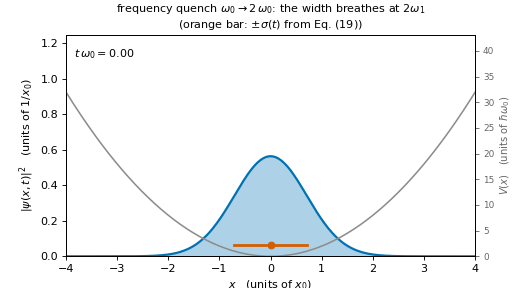

   [61 frames, 286 kB embedded in the notebook]
GIF built in 27.8 s


In [34]:
# ==============================================================================
# STEP 26: GIF of the frequency quench (breathing mode)
# ==============================================================================
dens_quench = np.abs(psi_spectral)**2
sigma_analytic = np.sqrt(sigma2_exact(t_snap, R_QUENCH))
crop = np.abs(x_dyn) <= 4.0                          # the state never leaves |x| < 3; crop for a better view

t_start = time.time()
gif_quench = make_density_gif(
    x_dyn[crop], dens_quench[:, crop], t_snap,
    potential=V_dyn[crop],
    x_mean=np.zeros_like(t_snap),                    # <x>(t) = 0 by parity
    sigma=sigma_analytic,                            # the ANALYTIC width, Eq. (19)
    title=rf"frequency quench $\omega_0 \to {R_QUENCH:g}\,\omega_0$: the width breathes at $2\omega_1$"
          "\n" r"(orange bar: $\pm\sigma(t)$ from Eq. (19))",
    ylim=(0.0, 1.25))
print(f"GIF built in {time.time() - t_start:.1f} s")
assert len(gif_quench) < 1_500_000, "GIF too large for a notebook"

Watch for three things: the packet **narrows** (the new trap is stiffer), it **overshoots** and comes back to its
original width, and it does all of this **without moving** — the centre stays at $x=0$ because nothing broke the
symmetry. The analytic bar tracks the numerical density exactly.

### 13.2 Animation 2: a coherent state sloshing in the trap

For contrast, the displaced ground state of Section 11.4: here the packet **moves** and keeps its **shape**.

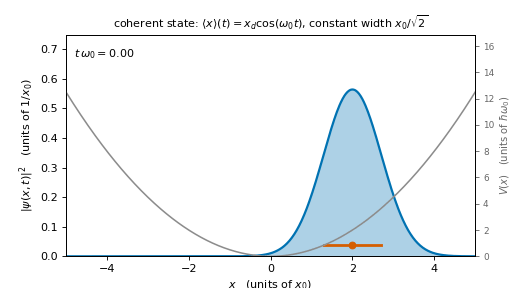

   [61 frames, 324 kB embedded in the notebook]
GIF built in 28.0 s


In [35]:
# ==============================================================================
# STEP 27: GIF of the coherent state (classical-like oscillation)
# ==============================================================================
t_coh_gif = np.linspace(0.0, 4.0 * np.pi, 61)        # two periods, 61 frames
psi_coh_gif = spectral_evolve(E_stat, phi_stat, c_coh, t_coh_gif)
mask_gif = np.abs(x_stat) <= 5.0                     # crop the plotted region: the state lives in |x| < 4

t_start = time.time()
gif_coherent = make_density_gif(
    x_stat[mask_gif], np.abs(psi_coh_gif[:, mask_gif])**2, t_coh_gif,
    potential=harmonic_potential(x_stat[mask_gif]),
    x_mean=X_DISPLACE * np.cos(t_coh_gif),           # the ANALYTIC classical orbit
    sigma=np.full_like(t_coh_gif, 1 / np.sqrt(2.0)), # the ANALYTIC constant width
    title=r"coherent state: $\langle x\rangle(t)=x_d\cos(\omega_0 t)$, constant width $x_0/\sqrt{2}$",
    ylim=(0.0, 0.75))
print(f"GIF built in {time.time() - t_start:.1f} s")
assert len(gif_coherent) < 1_500_000

### 13.3 Static fall-backs: space-time map and snapshot panels

Not every viewer plays GIFs (printed pages, some PDF exports, some websites). Two static representations carry the
same information, and the space-time map is in some ways *better*: it shows the whole history at once.

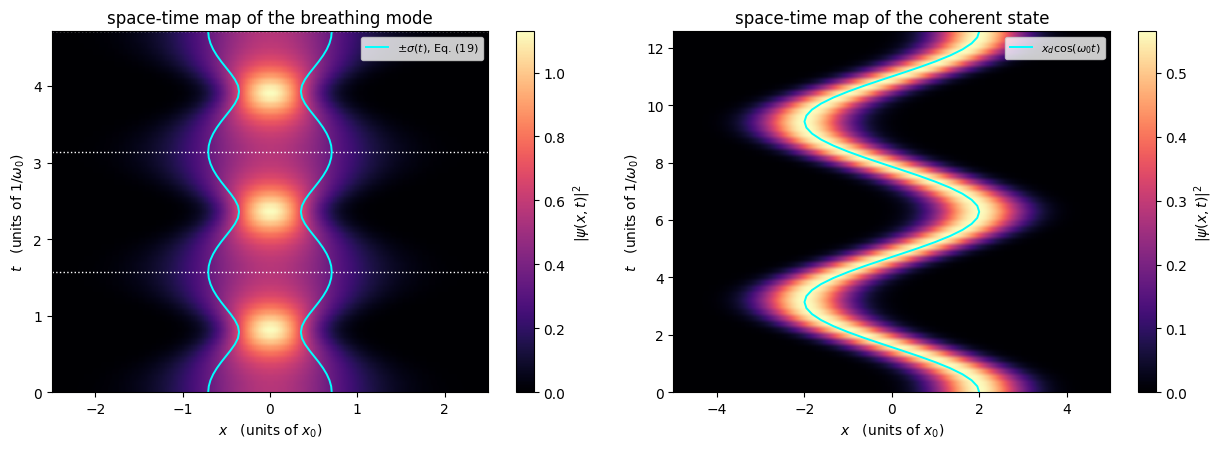

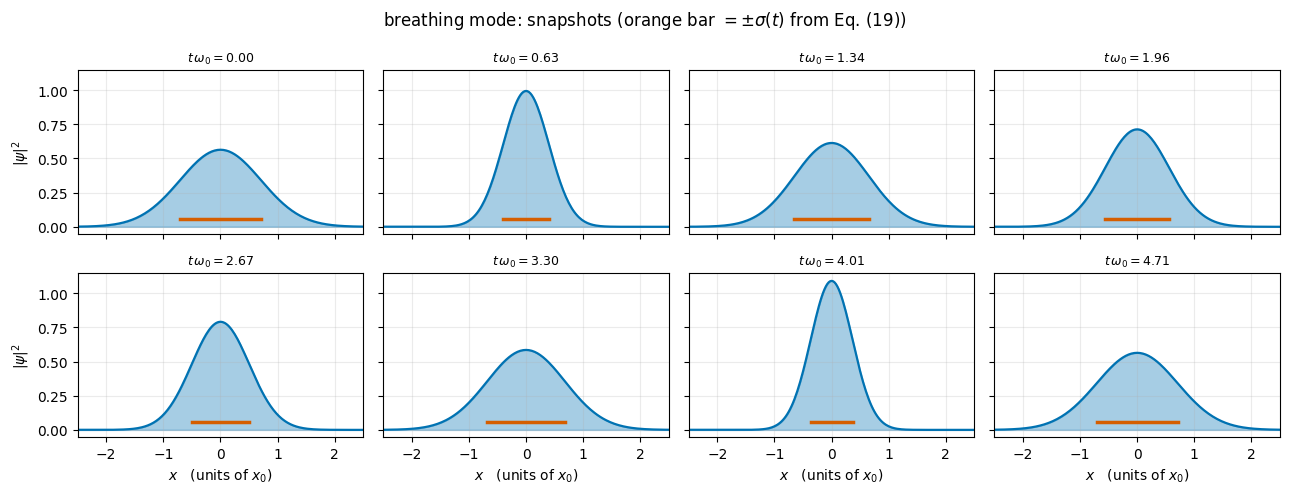

In [36]:
# ==============================================================================
# STEP 28: space-time heat map + snapshot panels (static versions of the animations)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

im = axes[0].imshow(dens_quench, origin="lower", aspect="auto", cmap="magma",
                    extent=[x_dyn[0], x_dyn[-1], t_snap[0], t_snap[-1]])
for k in range(1, 4):
    axes[0].axhline(k * T_BREATH, color="w", ls=":", lw=1.0)
axes[0].plot(+sigma_analytic, t_snap, color="cyan", lw=1.4, label=r"$\pm\sigma(t)$, Eq. (19)")
axes[0].plot(-sigma_analytic, t_snap, color="cyan", lw=1.4)
axes[0].set_xlim(-2.5, 2.5)
axes[0].set_xlabel(r"$x$   (units of $x_0$)"); axes[0].set_ylabel(r"$t$   (units of $1/\omega_0$)")
axes[0].set_title("space-time map of the breathing mode"); axes[0].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[0], label=r"$\vert\psi(x,t)\vert^2$")

im2 = axes[1].imshow(np.abs(psi_coh_gif[:, mask_gif])**2, origin="lower", aspect="auto", cmap="magma",
                     extent=[x_stat[mask_gif][0], x_stat[mask_gif][-1], t_coh_gif[0], t_coh_gif[-1]])
axes[1].plot(X_DISPLACE * np.cos(t_coh_gif), t_coh_gif, color="cyan", lw=1.4,
             label=r"$x_d\cos(\omega_0 t)$")
axes[1].set_xlabel(r"$x$   (units of $x_0$)"); axes[1].set_ylabel(r"$t$   (units of $1/\omega_0$)")
axes[1].set_title("space-time map of the coherent state"); axes[1].legend(loc="upper right", fontsize=8)
fig.colorbar(im2, ax=axes[1], label=r"$\vert\psi(x,t)\vert^2$")
fig.tight_layout(); plt.show()

# --- snapshot panels of the quench, the same frames the GIF shows ---
frames = np.linspace(0, N_SNAP, 8).astype(int)
fig, axes = plt.subplots(2, 4, figsize=(13.0, 5.0), sharex=True, sharey=True)
for ax, k in zip(axes.ravel(), frames):
    ax.fill_between(x_dyn, 0, dens_quench[k], color=C_NUM, alpha=.35)
    ax.plot(x_dyn, dens_quench[k], color=C_NUM, lw=1.6)
    s = sigma_analytic[k]
    ax.plot([-s, s], [0.06, 0.06], color=C_EXACT, lw=2.5)
    ax.set_title(rf"$t\,\omega_0={t_snap[k]:.2f}$", fontsize=9)
    ax.set_xlim(-2.5, 2.5); ax.grid(alpha=.25)
for ax in axes[1]:
    ax.set_xlabel(r"$x$   (units of $x_0$)")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\vert\psi\vert^2$")
fig.suptitle(r"breathing mode: snapshots (orange bar $=\pm\sigma(t)$ from Eq. (19))")
fig.tight_layout(); plt.show()

In the space-time maps the physics is a *shape*: the quench draws a braid that pinches three times (three breathing
periods $\pi/\omega_1$), the coherent state draws a pure cosine of constant thickness. The cyan curves are the
analytic predictions $\pm\sigma(t)$ of Eq. (19) and $x_d\cos t$ laid on top of the numerical densities — our
refrain one last time.

## 14. Workflow checklist and key takeaways

### 14.1 The checklist

Everything we did follows one recipe, and it is the recipe for *any* numerical study of a quantum system. Use it
in this order; each step protects the next.

1. **Non-dimensionalise.** Choose the natural energy, time and length scales; divide the equation by them; write
   down the conversion table. You should end up with numbers of order one and as few parameters as possible.
2. **Discretise.** Choose the representation (here: a uniform grid and a three-point stencil), and *derive the
   error term*, not just its order. Decide how the boundaries are handled.
3. **Check the conserved quantities.** Norm, energy, symmetries (here: $\langle x\rangle = 0$ by parity). These
   cost nothing and catch most bugs instantly.
4. **Converge.** Vary every discretisation parameter separately ($N_x$, $L$, $\Delta t$), plot the error on
   log-log axes, and compare the measured slope with the derived one.
5. **Validate against something exact.** An analytic solution, a limit you know, or a second independent method.
   Report the actual error, not "it looks fine".
6. **Only then explore new physics.** The quench of Section 12 was safe to trust precisely because steps 1-5 had
   already been done on the same code.

### 14.2 Key takeaways

* **Non-dimensionalisation removes every parameter.** $E_0=\hbar\omega_0$, $t_0=1/\omega_0$, $x_0=\sqrt{\hbar/(m\omega_0)}$
  turned a three-parameter problem into a parameter-free one that describes an ion, a molecule and an atom at once.
* **A differential operator becomes a matrix.** Taylor's theorem plus a grid turns the stationary Schrödinger
  equation into a real symmetric **tridiagonal** eigenvalue problem — and a library routine then hands you
  $E_n = n+\tfrac12$ and the Hermite functions, which the computer had never heard of.
* **Four numbers tell the whole dynamical story.** Ehrenfest's theorem makes $\langle x\rangle$ and
  $\langle p\rangle$ obey Newton's equations *exactly*, at the trap frequency $\omega$; the variances obey their
  own closed linear system and oscillate at $2\omega$ in antiphase. Everything we watched — the clock-like
  superposition, the rigid coherent state, the breathing squeezed state — is one formula, Eq. (16), with different
  initial conditions.
* **Squeezing is a quench away.** $\mathrm{Var}(x)\mathrm{Var}(p)$ returns to the Heisenberg minimum $1/4$ at
  every turning point of the breathing; a quarter of the new trap period after the quench $\mathrm{Var}(x)$ is a
  factor $r$ below the new trap's ground state.
* **Two discretisation knobs, two different failures.** $\Delta x$ controls resolution (error $\propto \Delta x^2$,
  quantitatively $-\frac{\Delta x^2}{32}(2n^2+2n+1)$); $L$ controls confinement (too small and you are simulating a
  box, not an oscillator). Converge in both.
* **Exact-in-time methods exist.** Spectral decomposition and $e^{-iH\Delta t}$ have *no* time-step error; they cost
  a dense diagonalisation, which is affordable in 1D and impossible in many-body Hilbert spaces.
* **Explicit integrators have a stability cliff, and the grid sets it.** Euler amplifies every mode for every
  $\Delta t$. RK4 is stable only for $\Delta t \le 2\sqrt2/E_{\max}$ (Eq. (23)), and since the three-point
  Laplacian has $E_{\max}\simeq 2/\Delta x^2$ this is the rule $\Delta t \lesssim \sqrt2\,\Delta x^2$ of
  Eq. (24) — in SI, $\Delta t \lesssim \sqrt2\,m\,\Delta x^2/\hbar$, with no trap frequency in it. Refining the
  grid therefore costs $O(N_x^3)$, and within the stable range RK4 is fourth-order accurate with a $\Delta t^5$
  norm drift. All of it was derived *and* measured here. Unitary schemes ($e^{-iH\Delta t}$, Crank-Nicolson,
  split-step Fourier, and the Chebyshev and Krylov propagators of Chapter 5) have no such limit.
* **Matrix-free.** $H\psi$ as three array shifts costs $O(N_x)$ instead of $O(N_x^2)$. The same
  move, applied to spin chains, is what makes the rest of this course possible.
* **Measure where the error lives.** In Sections 12.9–12.10 the space discretisation was eight to ten orders of
  magnitude less accurate than the time integration. Optimising the wrong one is the most common waste of effort in computational physics.

### 14.3 Exercises

**1. (★) The anharmonic oscillator.** Add a quartic term, $V(x) = \tfrac12 x^2 + \lambda x^4$, to
`harmonic_potential` and recompute the spectrum for $\lambda = 0.01, 0.05, 0.1$. Plot $E_n - (n+\tfrac12)$ against
$n$. First-order perturbation theory predicts $\Delta E_n = \lambda\langle n\vert x^4\vert n\rangle
= \tfrac{3\lambda}{4}(2n^2+2n+1)$ — check it, and find the $n$ at which it starts to fail for each $\lambda$.
Physics: this is why a superconducting $LC$ circuit needs a Josephson junction to become a qubit.

**2. (★★) The double well and tunnelling.** Use $V(x) = \lambda(x^2-a^2)^2$ with $a=2$ and $\lambda$ between
$0.05$ and $0.5$. Plot $\phi_0$ and $\phi_1$: they are the symmetric and antisymmetric combinations of states
localised in the two wells. Measure the **tunnelling splitting** $\Delta = E_1-E_0$ as a function of the barrier
height $V(0)=\lambda a^4$ and verify that $\ln\Delta$ falls roughly linearly with $\sqrt{V(0)}$ (the WKB
prediction $\Delta \propto e^{-S}$). Then start from a state localised in the left well,
$(\phi_0+\phi_1)/\sqrt2$, and watch it tunnel back and forth with period $2\pi/\Delta$ — an animation is worth it.

**3. (★★) A fourth-order stencil.** Derive, from Taylor expansions of $\phi_{j\pm1}$ and $\phi_{j\pm2}$, the
five-point formula

$$ \phi''_j = \frac{-\phi_{j+2} + 16\phi_{j+1} - 30\phi_j + 16\phi_{j-1} - \phi_{j-2}}{12\,\Delta x^2} +
   O(\Delta x^4), $$

implement it (the matrix is now *pentadiagonal*, so use `scipy.linalg.eigh_banded`), and repeat the convergence
study of Section 8.1. You should see slope $-4$. How many grid points do you now need for $E_{10}$ to $10^{-6}$,
compared with the $53\,000$ estimated in Section 8.2?

**4. (★★) Crank–Nicolson to fourth order.** The error of Crank–Nicolson is a smooth function of $\Delta t^2$ (Eq. (29)). Combine two runs,
$\psi^{(4)}=\big(4\psi_{\Delta t/2}-\psi_{\Delta t}\big)/3$ (Richardson extrapolation), and show that the infidelity of $\psi^{(4)}$ falls as $\Delta t^8$. Is $\psi^{(4)}$ still exactly normalised?
Then repeat the comparison of Section 12.11 on a grid with $\Delta x=0.0125$: by how much does the RK4 limit shrink, and how does the Crank–Nicolson error change?

**5. (★) Quench in the other direction.** Repeat Section 12 with $r = 1/2$ (a *softer* trap). Predict from
Eqs. (19) and (20) what $\mathrm{Var}(x)(t)$ and $\mathrm{Var}(p)(t)$ will do before running it, then check. What
is the breathing period now, which variance is squeezed at $rt=\pi/2$, and what is the injected energy?

**5b. (★★) A moving *and* breathing packet, and Ehrenfest beyond the oscillator.** Start from a Gaussian that is
both displaced and of the "wrong" width, $\psi(x,0)\propto \exp[-(x-x_d)^2/(4s^2)]$ with $s \ne 1/\sqrt2$, and
verify Eqs. (14) and (16) together: the centre follows the classical orbit at $\omega$ while the width breathes at
$2\omega$ on top of it. Then break the harmonicity (add the $\lambda x^4$ term of Exercise 1) and show that
$\langle x\rangle(t)$ is *no longer* the classical trajectory: plot
$d\langle p\rangle/dt + \langle V'(x)\rangle$ (zero, always) next to
$d\langle p\rangle/dt + V'(\langle x\rangle)$ (not zero), which is exactly the term that makes Ehrenfest's theorem
weaker than Newton's law in a general potential.

**6. (★★★) Parametric resonance.** Make the trap frequency oscillate, $r(t)^2 = 1 + \epsilon\cos(\omega_d t)$,
with $\epsilon = 0.1$. The Hamiltonian is now time-dependent, so methods (a) and (b) no longer apply — but RK4
does, provided you pass the current time to `apply_H` (use `lax.scan`'s carry to advance $t$). Scan $\omega_d$
from $1$ to $3$ and plot the energy at a fixed final time. You should find a sharp resonance at
$\omega_d = 2\omega_0$: the classic parametric instability, the same effect that drives a child's swing and that is
used to create squeezed light.

**7. (★★) The classical limit, quantitatively.** Extend the Kolmogorov-distance table of Section 9.3 to
$n = 60, 100, 150$ and fit the exponent in $\text{distance} \propto n^{-\alpha}$. (Careful: you must enlarge $L$
and $N_x$ for each $n$ — the turning point is at $\sqrt{2n+1}$, and Section 9.1 already showed that $L=20$ is too
small for $n=39$; this exercise is as much about convergence discipline as about physics.) Then repeat the
comparison restricted to $\vert x\vert < 0.8\,x_{\rm tp}$, away from the turning points, and show that there the
agreement improves *faster* — the turning-point region, where the semiclassical approximation breaks down and the
wave function is an Airy function, is what limits the global number.

**8. (★★) Two particles in a trap.** Two non-interacting distinguishable particles in the same trap live on a
two-dimensional grid $\psi(x_1,x_2)$, and $H = H_1 \otimes 1 + 1 \otimes H_2$. Build it for $N_x = 60$ and check
that the energies are $E_{n_1}+E_{n_2}$. Then add a contact interaction $g\,\delta(x_1-x_2) \to (g/\Delta x)$ on
the diagonal $x_1 = x_2$ and watch the degeneracies split. Notice how the memory grew from $N_x$ to $N_x^2$ —
this is the many-body problem, and it is exactly where the rest of this course begins.

### 14.4 References

* D. J. Griffiths and D. F. Schroeter, *Introduction to Quantum Mechanics*, 3rd ed., Cambridge University Press
  (2018), ISBN 978-1-107-18963-8 — §2.3 for the harmonic oscillator, both the algebraic (ladder-operator) and the
  analytic (Hermite) solution, i.e. everything Eqs. (11) and (12) above quote without proof.
* J. J. Sakurai and J. Napolitano, *Modern Quantum Mechanics*, 3rd ed., Cambridge University Press (2020),
  ISBN 978-1-108-47322-4 — Chapter 2 (*Quantum Dynamics*): §2.2.3 is the Heisenberg equation of motion and §2.2.4
  Ehrenfest's theorem, the content of Section 10.1 here; §2.3 treats the simple harmonic oscillator.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific
  Computing*, 3rd ed., Cambridge University Press (2007), ISBN 978-0-521-88068-8 — Chapter 11 (*Eigensystems*;
  §11.4 treats the eigenvalues and eigenvectors of a symmetric tridiagonal matrix, the problem `eigh_tridiagonal`
  solves with LAPACK's bisection and inverse-iteration or MRRR routines, and §11.8 inverse iteration),
  Chapter 17 (*Integration of Ordinary Differential Equations*; §17.1 is the fourth-order Runge-Kutta
  scheme of Eq. (22), §17.2 its adaptive step-size control), and Chapter 20 (*Partial Differential Equations*;
  finite-difference stencils and the stability of explicit schemes, the question Section 12.7 answers for RK4).
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes in Fortran 90: The Art of
  Parallel Scientific Computing*, Volume 2 of *Fortran Numerical Recipes*, 2nd ed., Cambridge University Press
  (1996), ISBN 978-0-521-57439-6 — the same algorithms (eigensystems, Runge-Kutta, PDE stencils) written as whole
  *array* operations rather than loops (the volume contains the routines; the methods are explained in the
  companion text). That is the style this notebook uses: `second_derivative` (Section 5.5) and `apply_H` (Section 12.6) are
  three shifted-array expressions, not a `for` loop over grid points.
* A. Goldberg, H. M. Schey and J. L. Schwartz, *Computer-generated motion pictures of one-dimensional
  quantum-mechanical transmission and reflection phenomena*, American Journal of Physics **35**, 177-186 (1967),
  DOI 10.1119/1.1973991 — computer-generated films of a wave packet transmitted and reflected by
  one-dimensional potentials, an early use of numerical wave-packet propagation to show quantum dynamics.
* J. Crank and P. Nicolson, *A practical method for numerical evaluation of solutions of partial differential
  equations of the heat-conduction type*, Mathematical Proceedings of the Cambridge Philosophical Society **43**,
  50-67 (1947), DOI 10.1017/S0305004100023197 — the implicit scheme of Section 12.11.
* M. D. Feit, J. A. Fleck Jr. and A. Steiger, *Solution of the Schrödinger equation by a spectral method*, Journal
  of Computational Physics **47**, 412-433 (1982), DOI 10.1016/0021-9991(82)90091-2 — the split-operator/FFT
  alternative to the grid Hamiltonian used here, and the method that escapes the step limit of Eq. (24).

### 14.5 Where to go next

* [01 — JAX](01_jax_from_scratch.ipynb): the full story of `jit`, `vmap`, `lax.scan` and `grad`,
  which we used today on trust.
* [49 — a single excitation on a lattice](../lecture_notes_notebooks/49_single_excitation_on_a_lattice.ipynb): the
  tridiagonal matrix of Section 6, with the potential removed, read as the exact Hamiltonian of a particle hopping on
  a lattice; its band, its light cone and its closed-form propagator are the first contact with a discrete quantum
  system, and the same matrix returns as the reference solution of notebooks 06 and 18.
* [04 — time evolution the textbook way](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb):
  exactly the ideas of Section 12 — spectral decomposition, the propagator, and step-by-step integration — but for
  a chain of interacting spins, where the Hilbert space grows as $2^N$ and the matrix-free habit becomes
  indispensable.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/